# Script to compute betas per clusters session averages

## merge function

In [1]:
import pandas as pd
import re

def load_and_merge_beta_lmer_data(beta_file_path, lmer_file_path, exclude_participants=None, calorie=None):
    """
    Load beta estimates and LMER data, process them, and merge.
    
    Parameters:
    -----------
    beta_file_path : str
        Path to the TSV file containing beta estimates
    lmer_file_path : str
        Path to the TXT file containing LMER data
    exclude_participants : list of str, optional
        List of substrings to exclude from participant_id (e.g., ['RGC'])
    calorie : str, optional
        Tag to add as a 'calorie' column to all rows (e.g., 'high', 'low', None)
    
    Returns:
    --------
    df_merged : pd.DataFrame
        Merged dataframe with beta and LMER data
    df_beta_processed : pd.DataFrame
        Processed beta dataframe with session-run structure
    """
    
    # Load beta TSV file
    print(f"Loading beta data from: {beta_file_path}")
    df_beta = pd.read_csv(beta_file_path, sep='\t')
    print(f"Loaded {len(df_beta)} rows")
    
    # Process session column
    print(f"\nSession dtype: {df_beta['session'].dtype}")
    print(f"Session unique values: {df_beta['session'].unique()}")
    
    # Always remove ses-01 BEFORE converting to int
    if df_beta['session'].dtype == 'object':
        before_count = len(df_beta)
        df_beta = df_beta[df_beta['session'] != 'ses-01']
        after_count = len(df_beta)
        print(f"Removed session 'ses-01': {before_count - after_count} rows removed")
        
        # Now convert to int
        df_beta['session'] = df_beta['session'].str.replace('ses-', '').astype(int)
    else:
        # If already numeric, ensure it's int
        df_beta['session'] = df_beta['session'].astype(int)
    
    # Process run column if it exists and needs cleaning
    if 'run' in df_beta.columns and df_beta['run'].dtype == 'object':
        df_beta['run'] = df_beta['run'].str.replace('run-', '').astype(int)
    elif 'run' in df_beta.columns:
        df_beta['run'] = df_beta['run'].astype(int)
    
    # Exclude participants if specified
    if exclude_participants:
        for exclude_substr in exclude_participants:
            before_count = len(df_beta)
            df_beta = df_beta[~df_beta['participant_id'].str.contains(exclude_substr, na=False)]
            after_count = len(df_beta)
            print(f"Excluded participants containing '{exclude_substr}': {before_count - after_count} rows removed")
    
    # Add calorie column if specified
    if calorie is not None:
        df_beta['calorie'] = calorie
        print(f"\nAdded 'calorie' column with value: '{calorie}'")
    
    # Load LMER data
    print(f"\nLoading LMER data from: {lmer_file_path}")
    df_lmer = pd.read_csv(lmer_file_path, sep='\t')
    print(f"Loaded {len(df_lmer)} rows")
    
    # Function to convert participant_id format
    def from_afni_id(x):
        m = re.match(r"sub-([A-Z]+)(\d+)", x)
        if m:
            prefix = m.group(1).lower()
            number = m.group(2).zfill(3)
            return f"{prefix}{number}"
        return x
    
    # Convert participant_id to match LMER format
    df_beta['Subj'] = df_beta['participant_id'].apply(from_afni_id)
    
    # Rename columns to match LMER format
    df_beta_renamed = df_beta.rename(columns={
        'session': 'sess',
        'run': 'run'
    })
    
    print(f"\nUnique subjects in beta data: {df_beta_renamed['Subj'].nunique()}")
    print(f"Unique subjects in LMER data: {df_lmer['Subj'].nunique()}")
    
    # Merge on Subj, sess, and run to keep same structure as LMER
    df_merged = pd.merge(
        df_beta_renamed,
        df_lmer[['Subj', 'sess', 'run', 'sex', 'type_chx', 'handedness', 
                 'vas_debut', 'age_baseline', 'bmi_baseline']],
        on=['Subj', 'sess', 'run'],
        how='inner'
    )
    
    print(f"\nMerged dataframe rows: {len(df_merged)}")
    print(f"Unique subjects in merged df: {df_merged['Subj'].nunique()}")
    
    # Print mean beta summary - auto-detect ID column type
    print("\n" + "="*80)
    
    # Determine which ID column exists
    id_column = None
    if 'cluster_id' in df_merged.columns:
        id_column = 'cluster_id'
        print("Mean Beta by Cluster and Session:")
    elif 'network_id' in df_merged.columns:
        id_column = 'network_id'
        print("Mean Beta by Network and Session:")
    
    print("="*80)
    
    if id_column:
        mean_beta_summary = df_merged.groupby([id_column, 'sess']).agg({
            'mean_beta': ['mean', 'std', 'count']
        }).round(6)
        print(mean_beta_summary)
    else:
        print("Warning: Neither 'cluster_id' nor 'network_id' column found in merged dataframe")
    
    return df_merged, df_beta_renamed

## LMM function

In [2]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def run_lmm_analysis(df_merged, formula, show_diagnostics=True, show_boxplot=False, ylim=None, cluster_id=None, show_xlabel=True, show_legend=True, show_ylabel=True):
    """
    Run Linear Mixed Model analysis for each cluster or network.
    Parameters:
    -----------
    df_merged : pd.DataFrame
        Merged dataframe with beta and LMER data
    formula : str
        Formula for the mixed model (e.g., 'outcome ~ mean_beta + sex + age_baseline')
    show_diagnostics : bool, optional
        Whether to show diagnostic plots (default: True)
    show_boxplot : bool, optional
        Whether to show boxplot for interactions (default: False)
    ylim : tuple, optional
        Y-axis limits for boxplot as (ymin, ymax) (default: None for auto)
    cluster_id : int or list of int, optional
        Specific cluster/network ID(s) to analyze. If None, analyzes all (default: None)
    show_xlabel : bool, optional
        Whether to show x-axis labels on boxplot (default: True)
    show_ylabel : bool, optional
        Whether to show y-axis label on boxplot (default: True)
    show_legend : bool, optional
        Whether to show legend on boxplot (default: True)
    
    Returns:
    --------
    results_dict : dict
        Dictionary with cluster/network IDs as keys and model fit objects as values
    """
    
    # Extract outcome variable name from formula
    outcome_var = formula.split('~')[0].strip()
    
    results_dict = {}
    
    # Determine which ID column exists (cluster_id or network_id)
    id_column = None
    if 'cluster_id' in df_merged.columns:
        id_column = 'cluster_id'
        id_label = 'CLUSTER'
    elif 'network_id' in df_merged.columns:
        id_column = 'network_id'
        id_label = 'NETWORK'
    else:
        raise ValueError("Neither 'cluster_id' nor 'network_id' column found in dataframe")
    
    # Determine which IDs to analyze
    if cluster_id is None:
        id_values = sorted(df_merged[id_column].unique())
    elif isinstance(cluster_id, (list, tuple)):
        id_values = cluster_id
    else:
        id_values = [cluster_id]
    
    # Loop through specified IDs
    for cid in id_values:
        print(f"\n{'='*80}")
        print(f"{id_label} {cid} ANALYSIS")
        print(f"{'='*80}\n")
        
        # Filter data for current cluster/network
        df_cluster = df_merged[df_merged[id_column] == cid].copy()
        
        if len(df_cluster) == 0:
            print(f"Warning: {id_label} ID {cid} not found in dataframe. Skipping.\n")
            continue
        
        # Convert categorical variables to category dtype if they exist in formula
        categorical_vars = ['type_chx', 'sex', 'handedness', 'sess', 'calorie']
        for var in categorical_vars:
            if var in df_cluster.columns and f'C({var})' not in formula and var in formula:
                df_cluster[var] = df_cluster[var].astype('category')
        
        print(f"Model formula: {formula}")
        print(f"Data shape: {df_cluster.shape}")
        print(f"Unique subjects: {df_cluster['Subj'].nunique()}\n")
        
        try:
            # Fit the mixed model with random intercept per subject
            mixed_model = smf.mixedlm(formula, df_cluster, groups=df_cluster['Subj'], re_formula='1')
            mixed_model_fit = mixed_model.fit()
            
            # Store results
            results_dict[cid] = mixed_model_fit
            
            # Print the summary of the model
            print(mixed_model_fit.summary())
            
            # Print variance components
            random_effects_var = mixed_model_fit.cov_re.iloc[0, 0]
            residual_var = mixed_model_fit.scale
            icc = random_effects_var / (random_effects_var + residual_var)
            
            print(f"\n{'='*80}")
            print("VARIANCE COMPONENTS")
            print(f"{'='*80}")
            print(f"Random effects variance (τ²): {random_effects_var:.6f}")
            print(f"Residual variance (σ²): {residual_var:.6f}")
            print(f"ICC (intraclass correlation): {icc:.4f}")
            print(f"{'='*80}\n")
            
            # Boxplot for session effects (simpler version)
            if show_boxplot and 'sess' in formula and not ('calorie' in formula and '*' in formula):
                # Simple boxplot showing effect by session only
                session_labels = {
                    '1': 'Pre-surgery',
                    '2': '4 months\npost-surgery',
                    '3': '12 months\npost-surgery',
                    '4': '24 months\npost-surgery'
                }
                
                # Network color mapping if using network_id
                network_id_to_name = {
                    1: 'Vis',
                    2: 'SomMot',
                    3: 'DorsAttn',
                    4: 'SalVentAttn',
                    5: 'Limbic',
                    6: 'Cont',
                    7: 'Default'
                }
                
                network_colors = {
                    'Vis': '#4B0082',
                    'SomMot': '#228B22',
                    'DorsAttn': '#87CEEB',
                    'SalVentAttn': '#9370DB',
                    'Limbic': '#F5DEB3',
                    'Cont': '#FFA500',
                    'Default': '#DC143C'
                }
                
                # Determine boxplot color based on ID type
                if id_column == 'network_id' and cid in network_id_to_name:
                    network_name = network_id_to_name[cid]
                    box_color = network_colors.get(network_name, '#4472C4')
                else:
                    box_color = '#4472C4'  # default blue for clusters
                
                fig, ax = plt.subplots(figsize=(7, 4))
                
                # Prepare data for boxplot
                df_plot = df_cluster.copy()
                df_plot['sess'] = df_plot['sess'].astype(str)
                
                sessions = sorted(df_plot['sess'].unique())
                
                # Prepare boxplot data for each session
                boxplot_data = []
                positions = []
                
                for i, sess in enumerate(sessions, start=1):
                    data = df_plot[df_plot['sess'] == sess][outcome_var].values
                    if len(data) > 0:
                        boxplot_data.append(data)
                        positions.append(i)
                
                # Create boxplot with appropriate color
                bp = ax.boxplot(boxplot_data, positions=positions, widths=0.6,
                                patch_artist=True, 
                                boxprops=dict(facecolor=box_color, alpha=0.7),
                                medianprops=dict(color='black', linewidth=2),
                                whiskerprops=dict(color=box_color, linewidth=2),
                                capprops=dict(color=box_color, linewidth=2))
                
                # Customize plot
                ax.set_xticks(positions)
                
                if show_xlabel:
                    ax.set_xticklabels([session_labels.get(s, f'Session {s}') for s in sessions], 
                                    fontname='Aptos', fontsize=16)
                else:
                    ax.set_xticklabels([])
                    ax.tick_params(axis='x', bottom=False)
                
                if show_ylabel:
                    ax.set_ylabel('Effect (BOLD % change per $)', fontname='Aptos', fontsize=16)
                    ax.tick_params(axis='y', labelsize=16)
                    for label in ax.get_yticklabels():
                        label.set_fontname('Aptos')
                else:
                    ax.set_ylabel('')
                    ax.set_yticklabels([])
                    ax.tick_params(axis='y', left=False)
                
                # Set y-axis limits if specified
                if ylim is not None:
                    ax.set_ylim(ylim)
                
                # Remove top and right spines
                ax.spines['top'].set_visible(False)
                ax.spines['right'].set_visible(False)
                
                # Set font for tick labels
                for label in ax.get_yticklabels():
                    label.set_fontname('Aptos')

                # Remove spines
                ax.spines['top'].set_visible(False)
                ax.spines['right'].set_visible(False)

                if not show_ylabel:
                    ax.spines['left'].set_visible(False)

                if not show_xlabel:
                    ax.spines['bottom'].set_visible(False)
                
                plt.tight_layout()
                plt.show()

            # Boxplot for sess*calorie interaction (existing version)
            elif show_boxplot and 'sess' in formula and 'calorie' in formula and '*' in formula:
            
                # Session label mapping
                session_labels = {
                    '1': 'Pre-surgery',
                    '2': '4 months\npost-surgery',
                    '3': '12 months\npost-surgery',
                    '4': '24 months\npost-surgery'
                }
                
                fig, ax = plt.subplots(figsize=(7, 4))
                
                # Prepare data for boxplot
                df_plot = df_cluster.copy()
                df_plot['sess'] = df_plot['sess'].astype(str)
                
                # Define colors - using a brighter orange
                colors = {'high': '#FF8C00', 'low': 'blue'}  # DarkOrange instead of 'orange'
                
                # Create boxplot
                positions_high = [1, 5, 9, 13]  # Positions for high calorie
                positions_low = [2, 6, 10, 14]  # Positions for low calorie
                
                sessions = sorted(df_plot['sess'].unique())
                
                # Plot high calorie
                data_high = [df_plot[(df_plot['sess'] == sess) & (df_plot['calorie'] == 'high')][outcome_var].values 
                            for sess in sessions]
                bp_high = ax.boxplot(data_high, positions=positions_high, widths=0.6,
                                    patch_artist=True, 
                                    boxprops=dict(facecolor=colors['high'], alpha=0.7),
                                    medianprops=dict(color='black', linewidth=2),
                                    whiskerprops=dict(color=colors['high'], linewidth=2),
                                    capprops=dict(color=colors['high'], linewidth=2))
                
                # Plot low calorie
                data_low = [df_plot[(df_plot['sess'] == sess) & (df_plot['calorie'] == 'low')][outcome_var].values 
                        for sess in sessions]
                bp_low = ax.boxplot(data_low, positions=positions_low, widths=0.6,
                                    patch_artist=True,
                                    boxprops=dict(facecolor=colors['low'], alpha=0.7),
                                    medianprops=dict(color='black', linewidth=2),
                                    whiskerprops=dict(color=colors['low'], linewidth=2),
                                    capprops=dict(color=colors['low'], linewidth=2))
                
                # Customize plot
                ax.set_xticks([1.5, 5.5, 9.5, 13.5])
                
                # Show or hide x-axis labels
                if show_xlabel:
                    ax.set_xticklabels([session_labels[s] for s in sessions], fontname='Aptos', fontsize=16)
                else:
                    ax.set_xticklabels([])
                    ax.tick_params(axis='x', bottom=False)
                
                if show_ylabel:
                    ax.set_ylabel('Effect (BOLD % change per $)', fontname='Aptos', fontsize=16)
                    ax.tick_params(axis='y', labelsize=16)
                    for label in ax.get_yticklabels():
                        label.set_fontname('Aptos')
                else:
                    ax.set_ylabel('')
                    ax.set_yticklabels([])
                    ax.tick_params(axis='y', left=False)
                
                # Set y-axis limits if specified
                if ylim is not None:
                    ax.set_ylim(ylim)
                
                # Remove top and right spines
                ax.spines['top'].set_visible(False)
                ax.spines['right'].set_visible(False)
                
                # Set font for tick labels
                for label in ax.get_yticklabels():
                    label.set_fontname('Aptos')
                
                # Add legend if requested
                if show_legend:
                    from matplotlib.patches import Patch
                    legend_elements = [Patch(facecolor=colors['high'], alpha=0.7, label='High Calorie'),
                                    Patch(facecolor=colors['low'], alpha=0.7, label='Low Calorie')]
                    legend = ax.legend(handles=legend_elements, loc='upper right', fontsize=16, prop={'family': 'Aptos'})

                # Remove spines
                ax.spines['top'].set_visible(False)
                ax.spines['right'].set_visible(False)

                if not show_ylabel:
                    ax.spines['left'].set_visible(False)

                if not show_xlabel:
                    ax.spines['bottom'].set_visible(False)
                
                plt.tight_layout()
                plt.show()
            
            # Diagnostic plots
            if show_diagnostics:
                fig, axes = plt.subplots(2, 2, figsize=(14, 10))
                fig.suptitle(f'{id_label} {cid} - Diagnostic Plots', fontsize=16, fontweight='bold')
                
                # Residuals vs fitted values
                residuals = mixed_model_fit.resid
                fitted_values = mixed_model_fit.fittedvalues
                axes[0, 0].scatter(fitted_values, residuals, alpha=0.6)
                axes[0, 0].axhline(y=0, color='r', linestyle='--')
                axes[0, 0].set_xlabel('Fitted values', fontsize=11)
                axes[0, 0].set_ylabel('Residuals', fontsize=11)
                axes[0, 0].set_title('Residuals vs Fitted values', fontsize=12)
                axes[0, 0].grid(True, alpha=0.3)
                
                # QQ-plot of residuals
                sm.qqplot(residuals, line='45', ax=axes[0, 1])
                axes[0, 1].set_title('QQ-plot of Residuals', fontsize=12)
                axes[0, 1].grid(True, alpha=0.3)
                
                # Histogram of residuals
                axes[1, 0].hist(residuals, bins=20, edgecolor='black', alpha=0.7)
                axes[1, 0].set_xlabel('Residuals', fontsize=11)
                axes[1, 0].set_ylabel('Frequency', fontsize=11)
                axes[1, 0].set_title('Histogram of Residuals', fontsize=12)
                axes[1, 0].grid(True, alpha=0.3)
                
                # Scale-Location plot
                standardized_residuals = np.sqrt(np.abs(residuals / np.std(residuals)))
                axes[1, 1].scatter(fitted_values, standardized_residuals, alpha=0.6)
                axes[1, 1].set_xlabel('Fitted values', fontsize=11)
                axes[1, 1].set_ylabel('√|Standardized Residuals|', fontsize=11)
                axes[1, 1].set_title('Scale-Location Plot', fontsize=12)
                axes[1, 1].grid(True, alpha=0.3)
                
                plt.tight_layout()
                plt.show()
            
            # Breusch-Pagan test for homoscedasticity
            bp_test = het_breuschpagan(mixed_model_fit.resid, mixed_model_fit.model.exog)
            bp_pvalue = bp_test[1]
            print(f"\nBreusch-Pagan test p-value: {bp_pvalue:.6f}")
            
            if bp_pvalue < 0.05:
                print("Heteroscedasticity detected. The variance of residuals is not constant.")
            else:
                print("No heteroscedasticity detected. The variance of residuals is constant.")
            
            # Shapiro-Wilk test for normality of residuals
            shapiro_test = stats.shapiro(mixed_model_fit.resid)
            print(f"\nShapiro-Wilk test p-value: {shapiro_test.pvalue:.6f}")
            
            if shapiro_test.pvalue < 0.05:
                print("Residuals are not normally distributed.")
            else:
                print("Residuals are normally distributed.")
            
            # Calculate VIF for each predictor
            print("\nVariance Inflation Factors:")
            vif_data = pd.DataFrame()
            vif_data["feature"] = mixed_model_fit.model.exog_names
            vif_data["VIF"] = [variance_inflation_factor(mixed_model_fit.model.exog, i) 
                               for i in range(mixed_model_fit.model.exog.shape[1])]
            print(vif_data)
            
            # Model fit statistics
            k = len(mixed_model_fit.params)
            n = mixed_model_fit.nobs
            log_likelihood = mixed_model_fit.llf
            aic = 2 * k - 2 * log_likelihood
            bic = np.log(n) * k - 2 * log_likelihood
            
            print(f"\nAIC: {aic:.4f}")
            print(f"BIC: {bic:.4f}")
            
            # Wald test results
            print("\nWald test results:")
            wald_test = mixed_model_fit.wald_test_terms()
            pd.set_option('display.float_format', lambda x: '%.10f' % x)
            print(wald_test)
            
            # Calculate R-squared for each parameter
            print("\nR-squared for each parameter:")
            r_squared_data = pd.DataFrame(columns=["Parameter", "R_squared"])
            
            for param in mixed_model_fit.model.exog_names:
                param_base = param.split('[')[0]
                
                if param_base == 'Intercept':
                    continue
                
                try:
                    # Handle categorical variable
                    if param_base.startswith('C('):
                        # Extract variable name from C(var)
                        var_name = param_base.split('C(')[1].split(')')[0]
                        formula_single = f'{outcome_var} ~ C({var_name})'
                    else:
                        formula_single = f'{outcome_var} ~ {param_base}'
                    
                    single_model = smf.mixedlm(formula_single, df_cluster, 
                                              groups=df_cluster['Subj'], re_formula='1')
                    single_model_fit = single_model.fit()
                    
                    # Calculate the R-squared as the proportion of variance explained
                    total_variance = np.var(df_cluster[outcome_var])
                    explained_variance = total_variance - np.var(single_model_fit.resid)
                    r_squared = explained_variance / total_variance
                    
                    # Append the result
                    r_squared_data = pd.concat([r_squared_data, 
                                               pd.DataFrame([{"Parameter": param_base, 
                                                             "R_squared": r_squared * 100}])], 
                                              ignore_index=True)
                except Exception as e:
                    print(f"Could not calculate R-squared for {param_base}: {str(e)}")
            
            print(r_squared_data)
            print("\n")
            
        except Exception as e:
            print(f"Error fitting model for {id_label} {cid}: {str(e)}\n")
    
    return results_dict

## nilearn slice figure function

In [3]:
from nilearn.plotting import plot_stat_map, show
from nilearn import image
from nilearn.image import coord_transform
import matplotlib.pyplot as plt
import numpy as np

def plot_cluster_slice(
    df_merged,
    cluster_id,
    effect_map_path,
    cluster_map_path,
    title=None,
    cmap='coolwarm',
    vmin=-0.15,
    vmax=0.15,
    threshold=0.01,
    alpha=0.7,
    cut_coords=None,
    display_mode='ortho',
    figure_width=7,
    output_file=None
):
    """
    Plot brain slices for a specific cluster showing effect size map with cluster contours.
    
    Parameters:
    -----------
    df_merged : pd.DataFrame
        Dataframe containing cluster coordinates (must have com_mni_x, com_mni_y, com_mni_z columns)
    cluster_id : int
        Cluster ID to plot
    effect_map_path : str
        Path to effect size NIfTI file
    cluster_map_path : str
        Path to cluster mask NIfTI file
    title : str, optional
        Title for the plot (default: None, no title displayed)
    cmap : str, optional
        Colormap name (default: 'coolwarm')
    vmin : float, optional
        Minimum value for colormap (default: -0.15)
    vmax : float, optional
        Maximum value for colormap (default: 0.15)
    threshold : float, optional
        Threshold for transparency (default: 0.01)
    alpha : float, optional
        Transparency level (default: 0.7)
    cut_coords : tuple or float, optional
        For 'ortho': tuple (x, y, z). For 'x'/'y'/'z': single coordinate value.
        If None, uses cluster center of mass.
    display_mode : str, optional
        Display mode: 'ortho' for 3 views, 'x' for sagittal, 'y' for coronal, 'z' for axial (default: 'ortho')
    figure_width : float, optional
        Width of figure in inches (default: 6)
    output_file : str, optional
        Path to save figure. If None, displays but doesn't save.
    
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The figure object
    """
    
    # Filter dataframe for the cluster
    cluster_df = df_merged[df_merged['cluster_id'] == cluster_id]
    
    if len(cluster_df) == 0:
        raise ValueError(f"Cluster ID {cluster_id} not found in dataframe")
    
    # Get cluster center of mass coordinates
    com_x = cluster_df['com_mni_x'].iloc[0]
    com_y = cluster_df['com_mni_y'].iloc[0]
    com_z = cluster_df['com_mni_z'].iloc[0]
    
    # Set cut_coords based on display_mode
    if cut_coords is None:
        if display_mode == 'ortho':
            cut_coords = (com_x, com_y, com_z)
        elif display_mode == 'x':
            cut_coords = [com_x]  # Wrap in list for single slice
        elif display_mode == 'y':
            cut_coords = [com_y]  # Wrap in list for single slice
        elif display_mode == 'z':
            cut_coords = [com_z]  # Wrap in list for single slice
        else:
            cut_coords = (com_x, com_y, com_z)
    elif display_mode in ['x', 'y', 'z'] and not isinstance(cut_coords, list):
        # If user provides a single coordinate, ensure it's in a list
        cut_coords = [cut_coords]
    
    # Load images
    effect_img = image.load_img(effect_map_path)
    cluster_img = image.load_img(cluster_map_path)
    
    # Create mask for specific cluster
    cluster_data = cluster_img.get_fdata()
    cluster_mask = (cluster_data == cluster_id).astype(float)
    cluster_mask_img = image.new_img_like(cluster_img, cluster_mask)
    
    # Calculate figure height based on display mode
    if display_mode == 'ortho':
        fig_height = figure_width * 0.4
    else:
        fig_height = figure_width
    
    # Create figure
    fig, axes = plt.subplots(figsize=(figure_width, fig_height), dpi=300)
    
    # Plot stat map with transparency (no colorbar, no title)
    display = plot_stat_map(
        effect_img,
        title=title,
        cut_coords=cut_coords,
        display_mode=display_mode,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        threshold=threshold,
        alpha=alpha,
        axes=axes,
        colorbar=False,
        annotate=True,
        draw_cross=False,
        black_bg=False
    )
    
    # Increase font size for annotations
    for cut_ax in display.axes.values():
        for text in cut_ax.ax.texts:
            text.set_fontsize(16)
    
    # Add cluster contours in black
    display.add_contours(
        cluster_mask_img,
        filled=False,
        colors=['black'],
        linewidths=2,
        levels=[0.5]
    )
    
    # Calculate and print cluster statistics
    effect_data = effect_img.get_fdata()
    effect_vals = effect_data[cluster_data == cluster_id]
    mean_effect = np.mean(effect_vals)
    
    print(f"Cluster {cluster_id}:")
    print(f"  Center of Mass (x, y, z): ({com_x}, {com_y}, {com_z})")
    if display_mode == 'ortho':
        print(f"  Cut coordinates: {cut_coords}")
    else:
        print(f"  Cut coordinate ({display_mode}): {cut_coords[0] if isinstance(cut_coords, list) else cut_coords}")
    print(f"  Mean Effect Size: {mean_effect:.4f}")
    print(f"  Number of voxels: {len(effect_vals)}")
    
    plt.tight_layout()
    
    if output_file:
        plt.savefig(output_file, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Figure saved to: {output_file}")
    
    show()
    
    return fig

# Example usage:
# Ortho view (3 slices):
# fig = plot_cluster_slice(
#     df_merged=df_merged_Lo,
#     cluster_id=1,
#     effect_map_path='/path/to/effect_map.nii.gz',
#     cluster_map_path='/path/to/cluster_map.nii.gz',
#     display_mode='ortho',
#     vmin=-0.15,
#     vmax=0.15
# )

# Single axial slice (z):
# fig = plot_cluster_slice(
#     df_merged=df_merged_Lo,
#     cluster_id=1,
#     effect_map_path='/path/to/effect_map.nii.gz',
#     cluster_map_path='/path/to/cluster_map.nii.gz',
#     display_mode='z',
#     vmin=-0.15,
#     vmax=0.15
# )

# Single sagittal slice (x) with custom coordinate:
# fig = plot_cluster_slice(
#     df_merged=df_merged_Lo,
#     cluster_id=1,
#     effect_map_path='/path/to/effect_map.nii.gz',
#     cluster_map_path='/path/to/cluster_map.nii.gz',
#     display_mode='x',
#     cut_coords=10,  # Can provide as single number, will be wrapped in list
#     vmin=-0.15,
#     vmax=0.15
# )

## yeo parcelattion (debug)

In [4]:
from nilearn import datasets, image
from nilearn.image import resample_to_img
from nilearn.plotting import plot_roi
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def plot_yeo_network_effects_multisession_separate_debug(
    effect_map_paths,
    n_networks=7,
    session_labels=None,
    output_dir=None,
    ylim=None,
    figsize=(8, 5),
    show_atlas_debug=True,
    show_xlabel=True,
    show_ylabel=True,
    ytick_count=5
):
    """
    Plot effect sizes for each Yeo network across multiple sessions.
    Creates one figure per network with FIXED plot area dimensions.
    
    Parameters:
    -----------
    effect_map_paths : dict
        Dictionary mapping session numbers to effect map paths
    n_networks : int, optional
        Number of Yeo networks (7 or 17) (default: 7)
    session_labels : dict, optional
        Dictionary mapping session numbers to labels
    output_dir : str, optional
        Directory to save figures. If None, doesn't save.
    ylim : tuple, optional
        Y-axis limits as (ymin, ymax)
    figsize : tuple, optional
        Figure size (width, height)
    show_atlas_debug : bool, optional
        Whether to show atlas debug plots (default: True)
    show_xlabel : bool, optional
        Whether to show x-axis labels and tick labels (default: True)
    show_ylabel : bool, optional
        Whether to show y-axis label and tick labels (default: True)
    
    Returns:
    --------
    df_network_effects : pd.DataFrame
        DataFrame with network effects for all sessions
    figures : dict
        Dictionary with network names as keys and figure objects as values
    """
    
    # Define network colors
    network_colors = {
        'Vis': '#4B0082',
        'SomMot': '#228B22',
        'DorsAttn': '#87CEEB',
        'SalVentAttn': '#9370DB',
        'Limbic': '#F5DEB3',
        'Cont': '#FFA500',
        'Default': '#DC143C'
    }
    
    # Fetch Schaefer atlas
    print(f"Fetching Schaefer atlas with {n_networks} Yeo networks...")
    atlas = datasets.fetch_atlas_schaefer_2018(
        n_rois=400,
        yeo_networks=n_networks,
        resolution_mm=1
    )
    
    atlas_img = image.load_img(atlas['maps'])
    
    print(f"\n{'='*80}")
    print("ATLAS INFO (Target resolution):")
    print(f"{'='*80}")
    print(f"Shape: {atlas_img.shape}")
    print(f"Affine:\n{atlas_img.affine}")
    print(f"Voxel sizes: {atlas_img.header.get_zooms()}")
    
    import nibabel as nib
    atlas_ornt = nib.orientations.aff2axcodes(atlas_img.affine)
    print(f"Atlas orientation: {atlas_ornt}")
    
    # Parse unique networks from ROI labels
    unique_networks = []
    network_roi_mapping = {}
    
    for i, label in enumerate(atlas['labels']):
        label_str = label.decode('utf-8') if isinstance(label, bytes) else label
        network = label_str.split('_')[2]
        
        if network not in unique_networks:
            unique_networks.append(network)
            network_roi_mapping[network] = []
        
        network_roi_mapping[network].append(i + 1)
    
    print(f"\nFound {len(unique_networks)} unique networks:")
    for net in unique_networks:
        print(f"  {net}: {len(network_roi_mapping[net])} ROIs")
    
    # Collect all effect values
    all_data = []
    
    for sess_idx, (sess_num, effect_path) in enumerate(sorted(effect_map_paths.items())):
        print(f"\n{'='*80}")
        print(f"Processing Session {sess_num}...")
        print(f"{'='*80}")
        print(f"  Loading effect map from: {effect_path}")
        
        effect_img = image.load_img(effect_path)
        
        print(f"\n  ORIGINAL EFFECT MAP INFO:")
        print(f"  Shape: {effect_img.shape}")
        print(f"  Affine:\n{effect_img.affine}")
        print(f"  Voxel sizes: {effect_img.header.get_zooms()}")
        
        effect_ornt = nib.orientations.aff2axcodes(effect_img.affine)
        print(f"  Effect map orientation: {effect_ornt}")
        
        # Resample effect map
        print(f"\n  Resampling effect map to 1mm to match atlas...")
        effect_resampled = resample_to_img(
            effect_img,
            atlas_img,
            interpolation='continuous'
        )
        
        print(f"\n  RESAMPLED EFFECT MAP INFO:")
        print(f"  Shape: {effect_resampled.shape}")
        print(f"  Affine:\n{effect_resampled.affine}")
        print(f"  Voxel sizes: {effect_resampled.header.get_zooms()}")
        
        resamp_ornt = nib.orientations.aff2axcodes(effect_resampled.affine)
        print(f"  Resampled effect map orientation: {resamp_ornt}")
        
        if effect_ornt != resamp_ornt:
            print(f"\n  WARNING: Orientation change!")
            print(f"    Original: {effect_ornt}")
            print(f"    Resampled: {resamp_ornt}")
        
        # Show debug plots only for first session
        if show_atlas_debug and sess_idx == 0:
            print("\n  Generating resampling debug plots...")
            
            mni_x, mni_y, mni_z = 0, 0, 0
            
            from nilearn.image import coord_transform
            vox_x_orig, vox_y_orig, vox_z_orig = coord_transform(
                mni_x, mni_y, mni_z, np.linalg.inv(effect_img.affine)
            )
            vox_x_orig, vox_y_orig, vox_z_orig = int(round(vox_x_orig)), int(round(vox_y_orig)), int(round(vox_z_orig))
            
            vox_x_resamp, vox_y_resamp, vox_z_resamp = coord_transform(
                mni_x, mni_y, mni_z, np.linalg.inv(effect_resampled.affine)
            )
            vox_x_resamp, vox_y_resamp, vox_z_resamp = int(round(vox_x_resamp)), int(round(vox_y_resamp)), int(round(vox_z_resamp))
            
            print(f"\n  MNI coordinates: ({mni_x}, {mni_y}, {mni_z})")
            print(f"  Original effect map voxel: ({vox_x_orig}, {vox_y_orig}, {vox_z_orig})")
            print(f"  Resampled effect map voxel: ({vox_x_resamp}, {vox_y_resamp}, {vox_z_resamp})")
            
            effect_data_orig = effect_img.get_fdata()
            effect_data_resamp = effect_resampled.get_fdata()
            
            print(f"\n  VALUES AT MNI (0, 0, 0):")
            print(f"  Original effect map value: {effect_data_orig[vox_x_orig, vox_y_orig, vox_z_orig]:.6f}")
            print(f"  Resampled effect map value: {effect_data_resamp[vox_x_resamp, vox_y_resamp, vox_z_resamp]:.6f}")
            
            fig, axes = plt.subplots(2, 3, figsize=(18, 12))
            fig.suptitle(f'Effect Map: Before (3mm) and After (1mm) Resampling (MNI: {mni_x}, {mni_y}, {mni_z})', 
                        fontsize=16, fontweight='bold')
            
            # Original effect map - three views
            axes[0, 0].imshow(effect_data_orig[vox_x_orig, :, :].T, cmap='coolwarm', origin='lower', vmin=-0.1, vmax=0.1)
            axes[0, 0].set_title(f'Original 3mm - Sagittal (MNI x={mni_x}, vox x={vox_x_orig})', fontsize=12)
            axes[0, 0].axis('off')
            
            axes[0, 1].imshow(effect_data_orig[:, vox_y_orig, :].T, cmap='coolwarm', origin='lower', vmin=-0.1, vmax=0.1)
            axes[0, 1].set_title(f'Original 3mm - Coronal (MNI y={mni_y}, vox y={vox_y_orig})', fontsize=12)
            axes[0, 1].axis('off')
            
            axes[0, 2].imshow(effect_data_orig[:, :, vox_z_orig].T, cmap='coolwarm', origin='lower', vmin=-0.1, vmax=0.1)
            axes[0, 2].set_title(f'Original 3mm - Axial (MNI z={mni_z}, vox z={vox_z_orig})', fontsize=12)
            axes[0, 2].axis('off')
            
            # Resampled effect map - three views
            axes[1, 0].imshow(effect_data_resamp[vox_x_resamp, :, :].T, cmap='coolwarm', origin='lower', vmin=-0.1, vmax=0.1)
            axes[1, 0].set_title(f'Resampled 1mm - Sagittal (MNI x={mni_x}, vox x={vox_x_resamp})', fontsize=12)
            axes[1, 0].axis('off')
            
            axes[1, 1].imshow(effect_data_resamp[:, vox_y_resamp, :].T, cmap='coolwarm', origin='lower', vmin=-0.1, vmax=0.1)
            axes[1, 1].set_title(f'Resampled 1mm - Coronal (MNI y={mni_y}, vox y={vox_y_resamp})', fontsize=12)
            axes[1, 1].axis('off')
            
            axes[1, 2].imshow(effect_data_resamp[:, :, vox_z_resamp].T, cmap='coolwarm', origin='lower', vmin=-0.1, vmax=0.1)
            axes[1, 2].set_title(f'Resampled 1mm - Axial (MNI z={mni_z}, vox z={vox_z_resamp})', fontsize=12)
            axes[1, 2].axis('off')
            
            plt.tight_layout()
            plt.show()
            
            print(f"\n  EFFECT MAP STATISTICS:")
            print(f"  Original (3mm) - Non-zero voxels: {np.count_nonzero(effect_data_orig)}")
            print(f"  Original (3mm) - Mean: {np.nanmean(effect_data_orig):.6f}")
            print(f"  Resampled (1mm) - Non-zero voxels: {np.count_nonzero(effect_data_resamp)}")
            print(f"  Resampled (1mm) - Mean: {np.nanmean(effect_data_resamp):.6f}")
        
        # Get data arrays
        effect_data = effect_resampled.get_fdata()
        atlas_data = atlas_img.get_fdata().astype(int)
        
        print(f"\n  FINAL EFFECT DATA STATISTICS (1mm):")
        print(f"  Min: {np.nanmin(effect_data):.6f}")
        print(f"  Max: {np.nanmax(effect_data):.6f}")
        print(f"  Mean: {np.nanmean(effect_data):.6f}")
        print(f"  Non-zero voxels: {np.count_nonzero(effect_data)}")
        print(f"  NaN voxels: {np.isnan(effect_data).sum()}")
        
        # Extract effect values for each network
        for network in unique_networks:
            roi_indices = network_roi_mapping[network]
            network_mask = np.isin(atlas_data, roi_indices)
            effect_values = effect_data[network_mask]
            
            print(f"\n  {network}:")
            print(f"    Mask voxels: {network_mask.sum()}")
            print(f"    Effect values before filtering: {len(effect_values)}")
            
            effect_values = effect_values[~np.isnan(effect_values)]
            print(f"    After removing NaN: {len(effect_values)}")
            effect_values = effect_values[effect_values != 0]
            print(f"    After removing zeros: {len(effect_values)}")
            
            for val in effect_values:
                all_data.append({
                    'session': sess_num,
                    'network': network,
                    'effect_size': val
                })
            
            if len(effect_values) > 0:
                print(f"    Mean effect: {np.mean(effect_values):.6f}")
                print(f"    Std effect: {np.std(effect_values):.6f}")
    
    # Create DataFrame
    df_network_effects = pd.DataFrame(all_data)
    
    print("\n" + "="*80)
    print("Summary Statistics by Network and Session:")
    print("="*80)
    summary = df_network_effects.groupby(['network', 'session'])['effect_size'].agg(['mean', 'std', 'count'])
    print(summary)
    
    # Default session labels
    if session_labels is None:
        session_labels = {
            1: 'Pre-surgery',
            2: '4 months\npost-surgery',
            3: '12 months\npost-surgery',
            4: '24 months\npost-surgery'
        }
    
    sessions = sorted(df_network_effects['session'].unique())
    
    # Network name mapping
    network_full_names = {
        'Vis': 'Visual Network',
        'SomMot': 'Somatomotor Network',
        'DorsAttn': 'Dorsal Attention Network',
        'SalVentAttn': 'Ventral Attention Network',
        'Limbic': 'Limbic Network',
        'Cont': 'Frontoparietal Control Network',
        'Default': 'Default Mode Network'
    }
    
    # FIXED SUBPLOT POSITIONING - ensures identical plot areas
    # Define absolute positions [left, bottom, width, height] in figure coordinates (0-1)
    # These remain constant regardless of axis visibility
    plot_left = 0.15 if show_ylabel else 0.05
    plot_bottom = 0.15 if show_xlabel else 0.10
    plot_width = 0.80
    plot_height = 0.75
    
    # Create one figure per network
    figures = {}
    
    for network in unique_networks:
        print(f"\nCreating figure for {network}...")
        
        # Create figure with fixed size
        fig = plt.figure(figsize=figsize, dpi=300)
        
        # Add subplot with FIXED absolute positioning
        ax = fig.add_axes([plot_left, plot_bottom, plot_width, plot_height])
        
        # Prepare data for this network
        network_data = df_network_effects[df_network_effects['network'] == network]
        
        # Create boxplot data
        boxplot_data = []
        positions = []
        
        for i, sess in enumerate(sessions, start=1):
            data = network_data[network_data['session'] == sess]['effect_size'].values
            if len(data) > 0:
                boxplot_data.append(data)
                positions.append(i)
        
        # Get color for this network
        color = network_colors.get(network, '#808080')
        
        # Create boxplot
        bp = ax.boxplot(
            boxplot_data,
            positions=positions,
            widths=0.6,
            patch_artist=True,
            showfliers=False,
            medianprops=dict(color='black', linewidth=2.5),
            boxprops=dict(linewidth=1.5),
            whiskerprops=dict(linewidth=1.5),
            capprops=dict(linewidth=1.5)
        )
        
        # Color the boxes
        for patch in bp['boxes']:
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        # Set x-axis limits to maintain consistent spacing
        ax.set_xlim(0.5, len(sessions) + 0.5)
        
        # Customize x-axis
        ax.set_xticks(positions)
        
        if show_xlabel:
            ax.set_xticklabels([session_labels.get(s, f'Session {s}') for s in sessions], 
                               fontname='Aptos', fontsize=14)
        else:
            ax.set_xticklabels([])
            ax.tick_params(axis='x', which='both', length=0)
        
        # ALWAYS set y-axis limits
        if ylim is not None:
            ax.set_ylim(ylim)
            ymin, ymax = ylim
            if ytick_count is not None and ytick_count >= 2:
                yticks = np.linspace(ymin, ymax, ytick_count)
                ax.set_yticks(yticks)
        
        # Customize y-axis
        if show_ylabel:
            ax.set_ylabel('Effect Size (BOLD % change)', fontname='Aptos', fontsize=16)
            ax.tick_params(axis='y', labelsize=14)
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2f}'))
            for label in ax.get_yticklabels():
                label.set_fontname('Aptos')
        else:
            ax.set_ylabel('')
            ax.set_yticklabels([])
            ax.tick_params(axis='y', which='both', length=0)
        
        # Set title
        full_name = network_full_names.get(network, network)
        ax.set_title(f'{full_name}', fontname='Aptos', fontsize=18, fontweight='bold', pad=20)
        
        # Add horizontal line at y=0
        ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
        
        # Remove spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        if not show_ylabel:
            ax.spines['left'].set_visible(False)
        
        if not show_xlabel:
            ax.spines['bottom'].set_visible(False)
        
        # NO plt.tight_layout() - this would change subplot positions!
        
        # Save figure
        if output_dir:
            import os
            os.makedirs(output_dir, exist_ok=True)
            output_file = os.path.join(output_dir, f'yeo_network_{network}_across_sessions.png')
            plt.savefig(output_file, dpi=300, bbox_inches='tight', facecolor='white', pad_inches=0.1)
            print(f"Figure saved to: {output_file}")
        
        plt.show()
        
        figures[network] = fig
    
    return df_network_effects, figures

# Results

In [5]:
#Example usage:
df_merged_Lo, df_beta_Lo = load_and_merge_beta_lmer_data(
    beta_file_path='/home/gagpat01/mes_projets/maitrise/fmri/results/beta_estimates_sess2vs1_clustered_p001_ACF_residuals_mod_hi_vs_mod_lo_v7_literature_complex_psc_qc_final_20260226_172623.tsv',
    lmer_file_path='/home/gagpat01/mes_projets/maitrise/fmri/results/3dlmerdata_table_with_covariates_mod_hi_vs_mod_lo_v7_literature_complex_psc_qc_final.txt',
    exclude_participants=['RGC'],
    calorie='low'
)

Loading beta data from: /home/gagpat01/mes_projets/maitrise/fmri/results/beta_estimates_sess2vs1_clustered_p001_ACF_residuals_mod_hi_vs_mod_lo_v7_literature_complex_psc_qc_final_20260226_172623.tsv
Loaded 8940 rows

Session dtype: object
Session unique values: ['ses-2' 'ses-3' 'ses-4' 'ses-01' 'ses-1']
Removed session 'ses-01': 4470 rows removed
Excluded participants containing 'RGC': 555 rows removed

Added 'calorie' column with value: 'low'

Loading LMER data from: /home/gagpat01/mes_projets/maitrise/fmri/results/3dlmerdata_table_with_covariates_mod_hi_vs_mod_lo_v7_literature_complex_psc_qc_final.txt
Loaded 507 rows

Unique subjects in beta data: 78
Unique subjects in LMER data: 57

Merged dataframe rows: 2525
Unique subjects in merged df: 57

Mean Beta by Cluster and Session:
                mean_beta                
                     mean       std count
cluster_id sess                          
1          1     0.020728  0.133569   146
           2    -0.016263  0.120247   138


In [8]:
#Example usage:
df_merged_Hi, df_beta_Hi = load_and_merge_beta_lmer_data(
    beta_file_path='/home/gagpat01/mes_projets/maitrise/fmri/results/beta_estimates_sess2vs1_clustered_p001_ACF_residuals_mod_hi_vs_mod_lo_v7_literature_complex_psc_qc_final_20260226_171255.tsv',
    lmer_file_path='/home/gagpat01/mes_projets/maitrise/fmri/results/3dlmerdata_table_with_covariates_mod_hi_vs_mod_lo_v7_literature_complex_psc_qc_final.txt',
    exclude_participants=['RGC'],
    calorie='high'
)

Loading beta data from: /home/gagpat01/mes_projets/maitrise/fmri/results/beta_estimates_sess2vs1_clustered_p001_ACF_residuals_mod_hi_vs_mod_lo_v7_literature_complex_psc_qc_final_20260226_171255.tsv
Loaded 8940 rows

Session dtype: object
Session unique values: ['ses-2' 'ses-3' 'ses-4' 'ses-01' 'ses-1']
Removed session 'ses-01': 4470 rows removed
Excluded participants containing 'RGC': 555 rows removed

Added 'calorie' column with value: 'high'

Loading LMER data from: /home/gagpat01/mes_projets/maitrise/fmri/results/3dlmerdata_table_with_covariates_mod_hi_vs_mod_lo_v7_literature_complex_psc_qc_final.txt
Loaded 507 rows

Unique subjects in beta data: 78
Unique subjects in LMER data: 57

Merged dataframe rows: 2525
Unique subjects in merged df: 57

Mean Beta by Cluster and Session:
                mean_beta                
                     mean       std count
cluster_id sess                          
1          1    -0.013980  0.078071   146
           2     0.065957  0.159953   138

In [9]:
#Example usage:
df_merged_Hi_v_Lo, df_beta_Hi_v_Lo = load_and_merge_beta_lmer_data(
    beta_file_path='/home/gagpat01/mes_projets/maitrise/fmri/results/beta_estimates_sess2vs1_clustered_p001_ACF_residuals_mod_hi_vs_mod_lo_v7_literature_complex_psc_qc_final_20260226_181407.tsv',
    lmer_file_path='/home/gagpat01/mes_projets/maitrise/fmri/results/3dlmerdata_table_with_covariates_mod_hi_vs_mod_lo_v7_literature_complex_psc_qc_final.txt',
    exclude_participants=['RGC']
)

Loading beta data from: /home/gagpat01/mes_projets/maitrise/fmri/results/beta_estimates_sess2vs1_clustered_p001_ACF_residuals_mod_hi_vs_mod_lo_v7_literature_complex_psc_qc_final_20260226_181407.tsv
Loaded 8940 rows

Session dtype: object
Session unique values: ['ses-2' 'ses-3' 'ses-4' 'ses-01' 'ses-1']
Removed session 'ses-01': 4470 rows removed
Excluded participants containing 'RGC': 555 rows removed

Loading LMER data from: /home/gagpat01/mes_projets/maitrise/fmri/results/3dlmerdata_table_with_covariates_mod_hi_vs_mod_lo_v7_literature_complex_psc_qc_final.txt
Loaded 507 rows

Unique subjects in beta data: 78
Unique subjects in LMER data: 57

Merged dataframe rows: 2525
Unique subjects in merged df: 57

Mean Beta by Cluster and Session:
                mean_beta                
                     mean       std count
cluster_id sess                          
1          1    -0.034708  0.145127   146
           2     0.082220  0.193629   138
           3    -0.010842  0.125524   112


In [10]:
results = run_lmm_analysis(
    df_merged_Hi, 
    formula='mean_beta ~  sess + sex + age_baseline + bmi_baseline + C(type_chx) + handedness',
    show_diagnostics=False

)


CLUSTER 1 ANALYSIS

Model formula: mean_beta ~  sess + sex + age_baseline + bmi_baseline + C(type_chx) + handedness
Data shape: (505, 21)
Unique subjects: 57



C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


            Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   mean_beta
No. Observations:    505       Method:               REML     
No. Groups:          57        Scale:                0.0143   
Min. group size:     2         Log-Likelihood:       312.6824 
Max. group size:     12        Converged:            Yes      
Mean group size:     8.9                                      
--------------------------------------------------------------
                    Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept            0.046    0.034  1.330 0.184 -0.022  0.113
sess[T.2]            0.080    0.014  5.569 0.000  0.052  0.108
sess[T.3]            0.015    0.015  0.992 0.321 -0.015  0.045
sess[T.4]            0.012    0.015  0.799 0.424 -0.018  0.042
sex[T.male]         -0.001    0.016 -0.084 0.933 -0.033  0.030
C(type_chx)[T.2]    -0.008    0.018 -0.465 0.642 -0.044  0.027
C(typ

C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2k

      Parameter     R_squared
0          sess 17.0251660737
1          sess 17.0251660737
2          sess 17.0251660737
3           sex  9.1868931705
4   C(type_chx)  8.6627259904
5   C(type_chx)  8.6627259904
6    handedness  9.0017114351
7  age_baseline  9.9161666515
8  bmi_baseline  9.0227679975



CLUSTER 2 ANALYSIS

Model formula: mean_beta ~  sess + sex + age_baseline + bmi_baseline + C(type_chx) + handedness
Data shape: (505, 21)
Unique subjects: 57



...

C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2k

            Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   mean_beta
No. Observations:    505       Method:               REML     
No. Groups:          57        Scale:                0.0195   
Min. group size:     2         Log-Likelihood:       218.5273 
Max. group size:     12        Converged:            No       
Mean group size:     8.9                                      
--------------------------------------------------------------
                    Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept           -0.138    0.056 -2.455 0.014 -0.248 -0.028
sess[T.2]            0.061    0.017  3.615 0.000  0.028  0.094
sess[T.3]            0.015    0.018  0.841 0.400 -0.020  0.050
sess[T.4]            0.019    0.018  1.061 0.289 -0.016  0.055
sex[T.male]          0.013    0.026  0.492 0.623 -0.039  0.065
C(type_chx)[T.2]     0.026    0.029  0.890 0.374 -0.031  0.083
C(typ

C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Patrick\AppData\Local\Temp\ipykernel_48880\354981984.py:428: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  r_squared_data = pd.concat([r_squared_data,
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn

      Parameter     R_squared
0          sess 15.8115231524
1          sess 15.8115231524
2          sess 15.8115231524
3           sex 17.4685536676
4   C(type_chx) 17.2436943595
5   C(type_chx) 17.2436943595
6    handedness 12.8085955254
7  age_baseline 17.4701324922
8  bmi_baseline 13.1035831061




C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)



CLUSTER 1 ANALYSIS

Model formula: mean_beta ~  sess + sex + age_baseline + bmi_baseline + C(type_chx) + handedness
Data shape: (505, 21)
Unique subjects: 57



C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


            Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   mean_beta
No. Observations:    505       Method:               REML     
No. Groups:          57        Scale:                0.0138   
Min. group size:     2         Log-Likelihood:       325.7348 
Max. group size:     12        Converged:            Yes      
Mean group size:     8.9                                      
--------------------------------------------------------------
                    Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept           -0.044    0.031 -1.423 0.155 -0.104  0.017
sess[T.2]           -0.035    0.014 -2.535 0.011 -0.063 -0.008
sess[T.3]           -0.009    0.015 -0.587 0.557 -0.038  0.020
sess[T.4]           -0.005    0.015 -0.315 0.752 -0.034  0.025
sex[T.male]          0.018    0.014  1.284 0.199 -0.010  0.047
C(type_chx)[T.2]     0.024    0.016  1.438 0.150 -0.009  0.056
C(typ

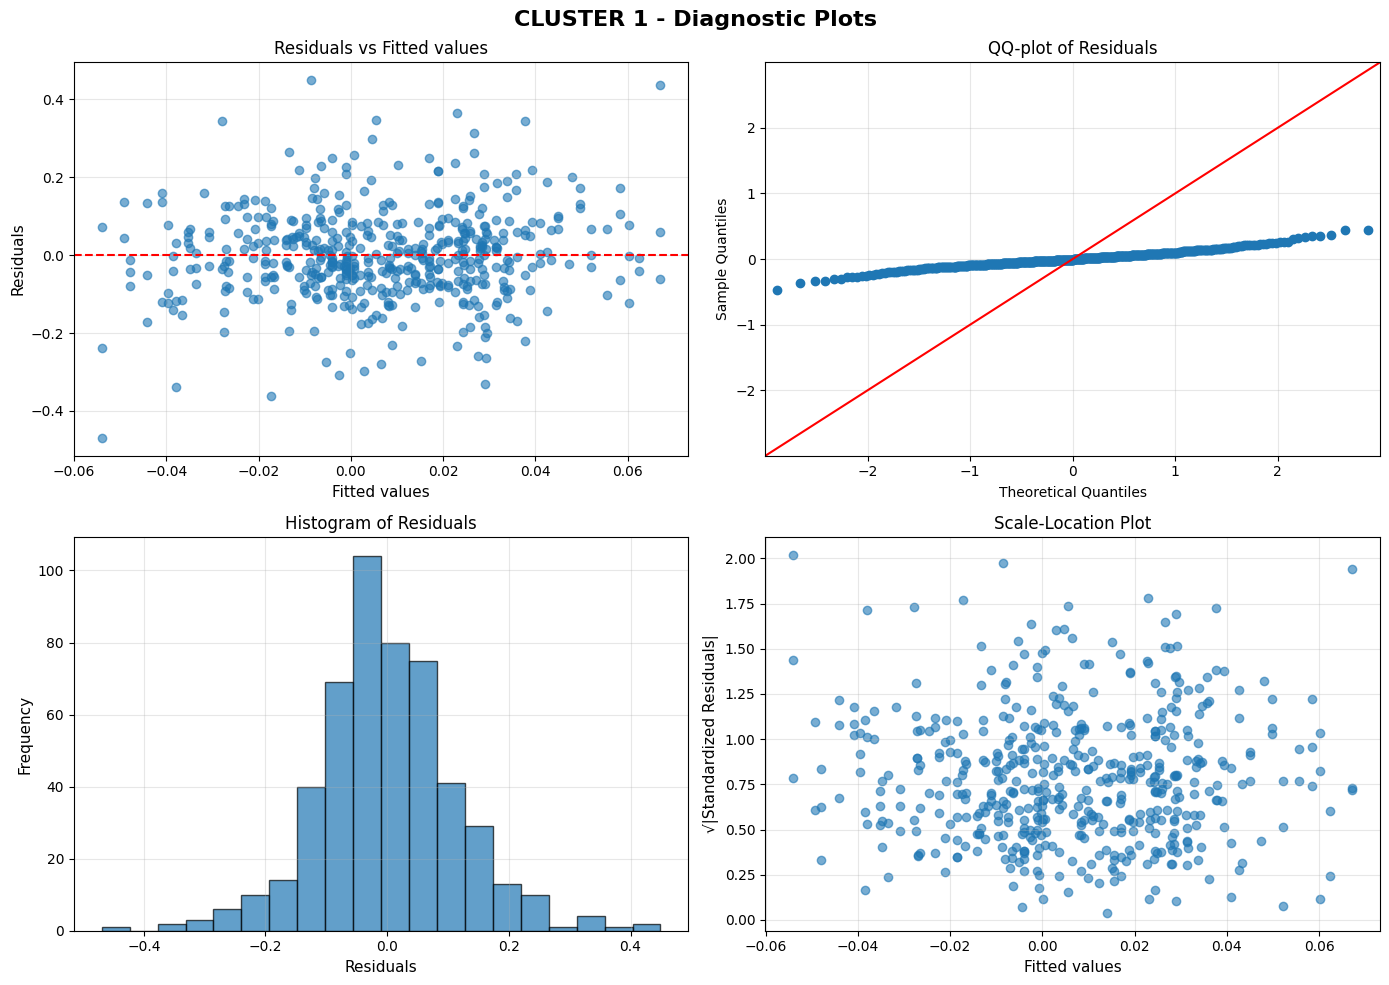


Breusch-Pagan test p-value: 0.087192
No heteroscedasticity detected. The variance of residuals is constant.

Shapiro-Wilk test p-value: 0.000002
Residuals are not normally distributed.

Variance Inflation Factors:
               feature           VIF
0            Intercept 28.6204990674
1            sess[T.2]  1.4175961444
2            sess[T.3]  1.3846942731
3            sess[T.4]  1.3788277309
4          sex[T.male]  1.1186338013
5     C(type_chx)[T.2]  1.4794887327
6     C(type_chx)[T.3]  1.7836835244
7  handedness[T.right]  1.3304906337
8         age_baseline  1.5501709623
9         bmi_baseline  1.3295402886

AIC: -629.4695
BIC: -582.9994

Wald test results:
                                  chi2               P>chi2  df constraint
Intercept       [[2.0244022703010325]]  0.15478981772005734              1
sess             [[7.470459120478549]]  0.05832236149716325              3
sex             [[1.6480018922704711]]  0.19923110254261703              1
C(type_chx)      [[3.476113

C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Patrick\AppData\Local\Temp\ipykernel_27192\354981984.py:428: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining th

      Parameter    R_squared
0          sess 6.7845332492
1          sess 6.7845332492
2          sess 6.7845332492
3           sex 5.4447244047
4   C(type_chx) 5.8572487417
5   C(type_chx) 5.8572487417
6    handedness 5.3101254168
7  age_baseline 5.3580355948
8  bmi_baseline 5.0082610321



CLUSTER 2 ANALYSIS

Model formula: mean_beta ~  sess + sex + age_baseline + bmi_baseline + C(type_chx) + handedness
Data shape: (505, 21)
Unique subjects: 57



C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


            Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   mean_beta
No. Observations:    505       Method:               REML     
No. Groups:          57        Scale:                0.0130   
Min. group size:     2         Log-Likelihood:       319.1285 
Max. group size:     12        Converged:            Yes      
Mean group size:     8.9                                      
--------------------------------------------------------------
                    Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept           -0.018    0.046 -0.403 0.687 -0.108  0.071
sess[T.2]           -0.017    0.014 -1.222 0.222 -0.044  0.010
sess[T.3]           -0.008    0.015 -0.527 0.598 -0.036  0.021
sess[T.4]            0.005    0.015  0.308 0.758 -0.024  0.034
sex[T.male]          0.005    0.022  0.210 0.833 -0.038  0.047
C(type_chx)[T.2]     0.055    0.024  2.299 0.022  0.008  0.102
C(typ

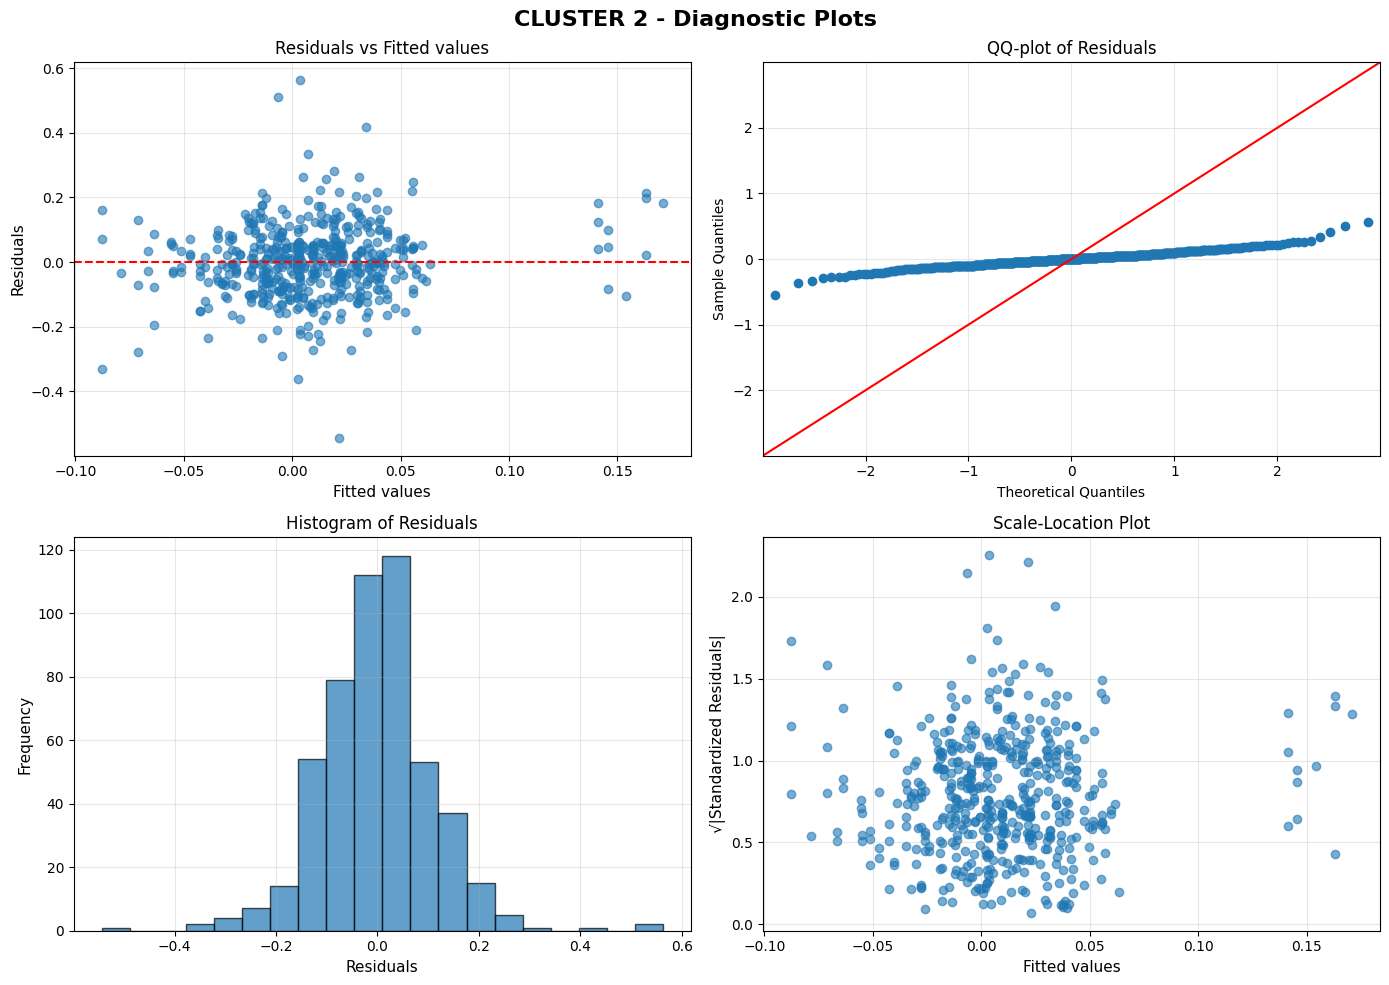


Breusch-Pagan test p-value: 0.076592
No heteroscedasticity detected. The variance of residuals is constant.

Shapiro-Wilk test p-value: 0.000000
Residuals are not normally distributed.

Variance Inflation Factors:
               feature           VIF
0            Intercept 28.6204990674
1            sess[T.2]  1.4175961444
2            sess[T.3]  1.3846942731
3            sess[T.4]  1.3788277309
4          sex[T.male]  1.1186338013
5     C(type_chx)[T.2]  1.4794887327
6     C(type_chx)[T.3]  1.7836835244
7  handedness[T.right]  1.3304906337
8         age_baseline  1.5501709623
9         bmi_baseline  1.3295402886

AIC: -616.2570
BIC: -569.7868

Wald test results:
                                  chi2               P>chi2  df constraint
Intercept      [[0.16271201641789235]]   0.6866718046658968              1
sess            [[2.4738297153338697]]  0.48003921089104107              3
sex           [[0.044193459719034295]]   0.8334940933127233              1
C(type_chx)      [[5.310020

C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with

      Parameter     R_squared
0          sess 10.7181191333
1          sess 10.7181191333
2          sess 10.7181191333
3           sex 15.8517823977
4   C(type_chx)  9.2220513742
5   C(type_chx)  9.2220513742
6    handedness 11.9196128424
7  age_baseline 15.9027645740
8  bmi_baseline 15.8490509385



CLUSTER 3 ANALYSIS

Model formula: mean_beta ~  sess + sex + age_baseline + bmi_baseline + C(type_chx) + handedness
Data shape: (505, 21)
Unique subjects: 57

            Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   mean_beta
No. Observations:    505       Method:               REML     
No. Groups:          57        Scale:                0.0384   
Min. group size:     2         Log-Likelihood:       44.5808  
Max. group size:     12        Converged:            Yes      
Mean group size:     8.9                                      
--------------------------------------------------------------
                    Coef.  Std.Err.   z    P>|z

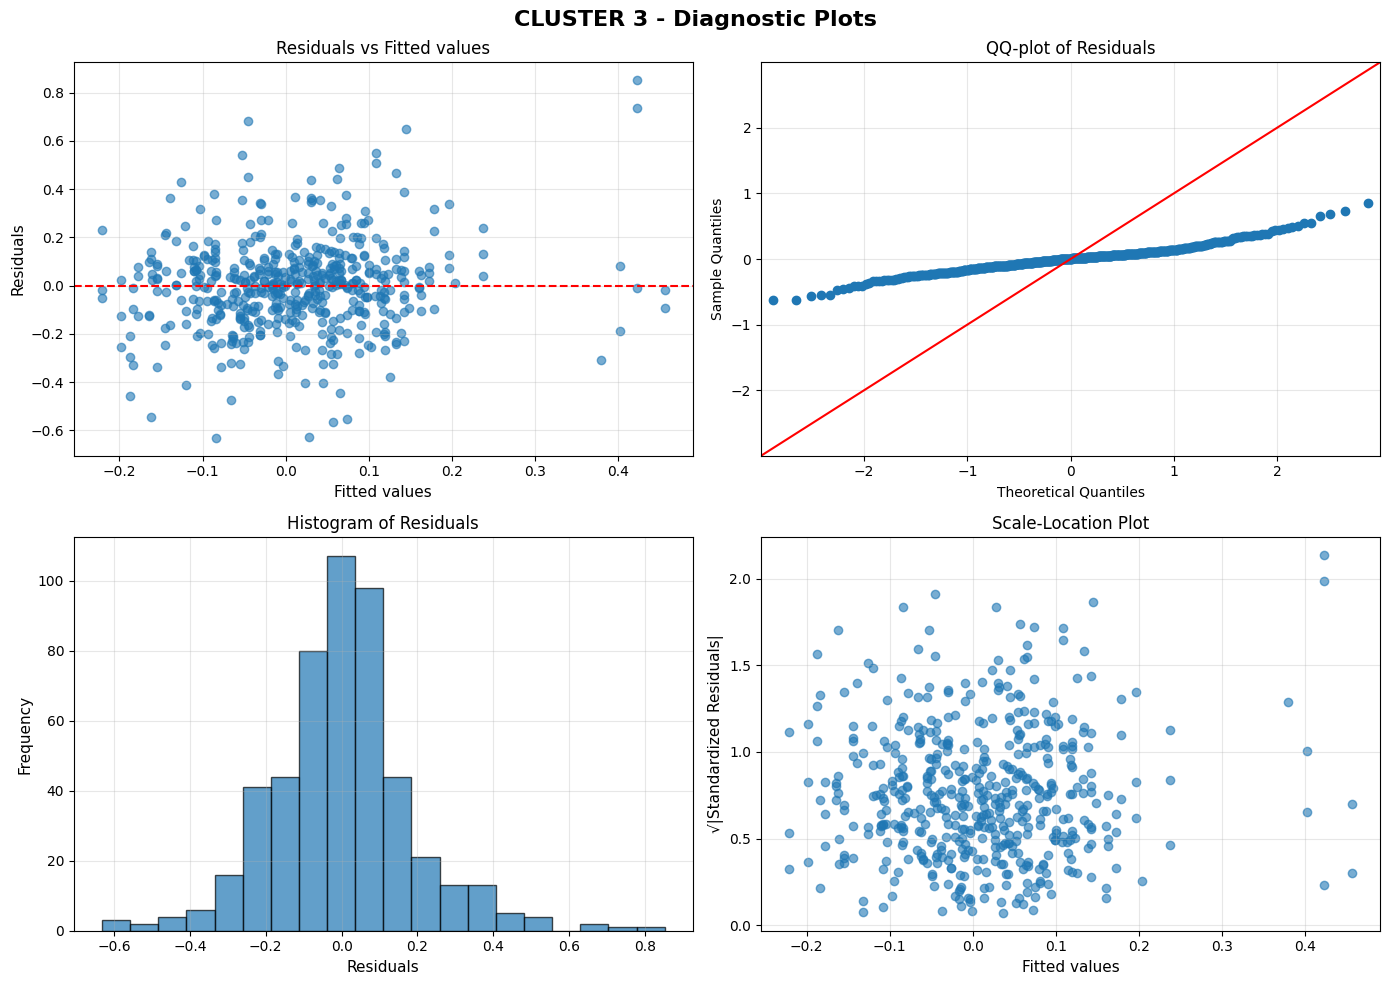


Breusch-Pagan test p-value: 0.094622
No heteroscedasticity detected. The variance of residuals is constant.

Shapiro-Wilk test p-value: 0.000000
Residuals are not normally distributed.

Variance Inflation Factors:
               feature           VIF
0            Intercept 28.6204990674
1            sess[T.2]  1.4175961444
2            sess[T.3]  1.3846942731
3            sess[T.4]  1.3788277309
4          sex[T.male]  1.1186338013
5     C(type_chx)[T.2]  1.4794887327
6     C(type_chx)[T.3]  1.7836835244
7  handedness[T.right]  1.3304906337
8         age_baseline  1.5501709623
9         bmi_baseline  1.3295402886

AIC: -67.1617
BIC: -20.6915

Wald test results:
                                    chi2                P>chi2  df constraint
Intercept     [[0.00013722337701050141]]    0.9906536039427158              1
sess               [[9.762721190103644]]  0.020694606392664985              3
sex                 [[1.67326554534343]]    0.1958217119029898              1
C(type_chx)      

C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
C:\Users\Patrick\AppData\Local\Temp\ipykernel_27192\354981984.py:428: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  r_squared_data = pd.concat([r_squared_data,


      Parameter     R_squared
0          sess 31.4772903744
1          sess 31.4772903744
2          sess 31.4772903744
3           sex 30.1569262141
4   C(type_chx) 30.2060618247
5   C(type_chx) 30.2060618247
6    handedness 30.1378216437
7  age_baseline 29.8937866863
8  bmi_baseline 30.1013261707



CLUSTER 4 ANALYSIS

Model formula: mean_beta ~  sess + sex + age_baseline + bmi_baseline + C(type_chx) + handedness
Data shape: (505, 21)
Unique subjects: 57



C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


            Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   mean_beta
No. Observations:    505       Method:               REML     
No. Groups:          57        Scale:                0.0129   
Min. group size:     2         Log-Likelihood:       337.7830 
Max. group size:     12        Converged:            Yes      
Mean group size:     8.9                                      
--------------------------------------------------------------
                    Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept           -0.023    0.033 -0.680 0.496 -0.088  0.042
sess[T.2]           -0.033    0.014 -2.464 0.014 -0.060 -0.007
sess[T.3]           -0.012    0.014 -0.861 0.389 -0.041  0.016
sess[T.4]           -0.018    0.015 -1.252 0.210 -0.047  0.010
sex[T.male]          0.047    0.015  3.018 0.003  0.016  0.077
C(type_chx)[T.2]     0.020    0.018  1.130 0.259 -0.015  0.054
C(typ

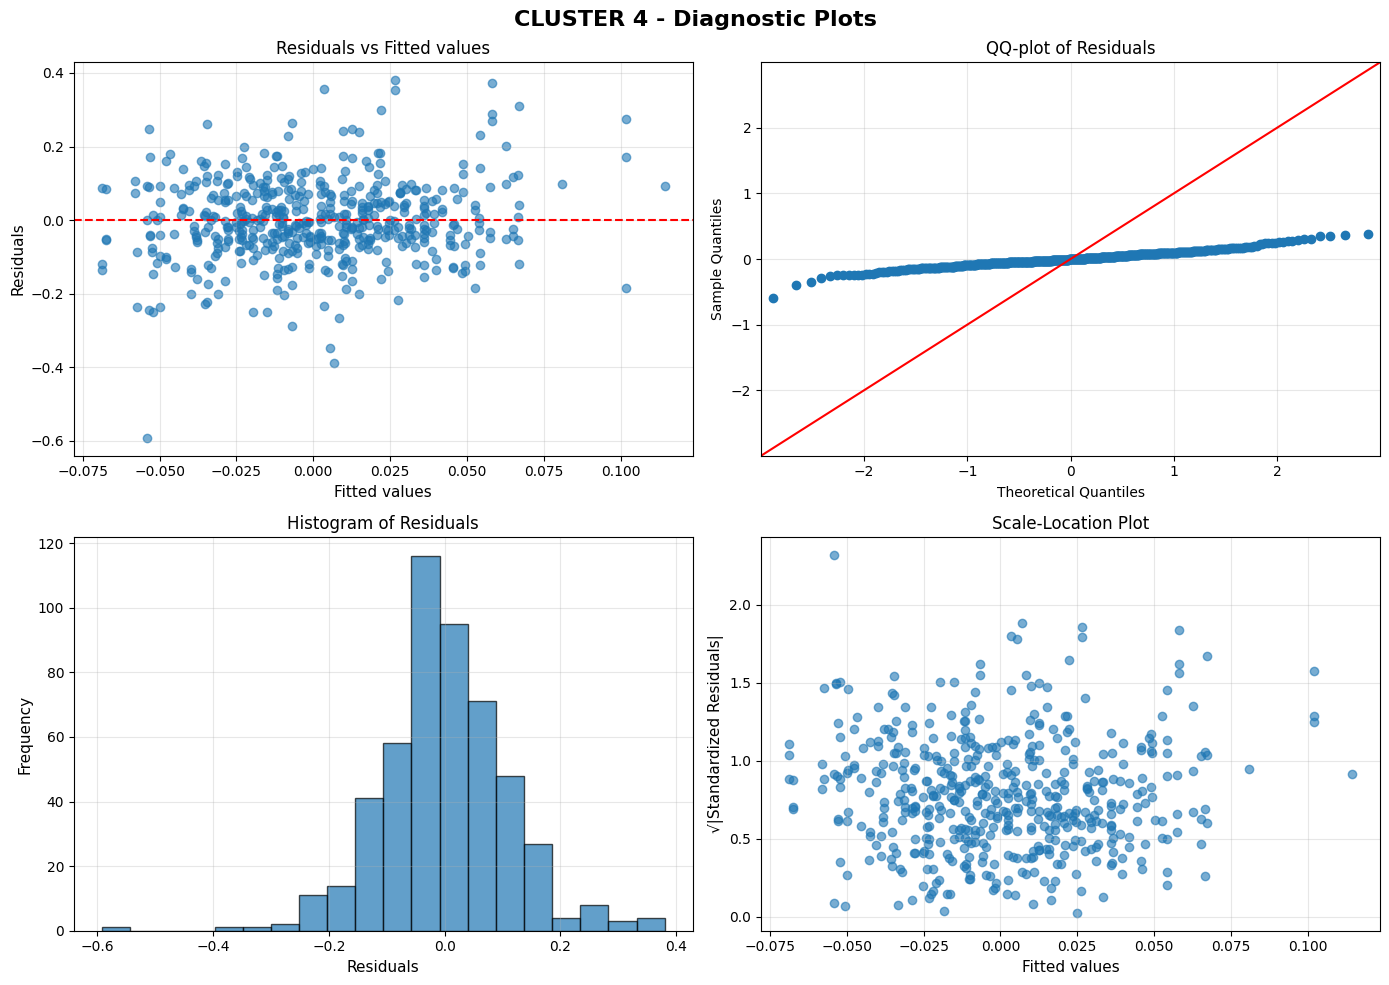


Breusch-Pagan test p-value: 0.037821
Heteroscedasticity detected. The variance of residuals is not constant.

Shapiro-Wilk test p-value: 0.000000
Residuals are not normally distributed.

Variance Inflation Factors:
               feature           VIF
0            Intercept 28.6204990674
1            sess[T.2]  1.4175961444
2            sess[T.3]  1.3846942731
3            sess[T.4]  1.3788277309
4          sex[T.male]  1.1186338013
5     C(type_chx)[T.2]  1.4794887327
6     C(type_chx)[T.3]  1.7836835244
7  handedness[T.right]  1.3304906337
8         age_baseline  1.5501709623
9         bmi_baseline  1.3295402886

AIC: -653.5660
BIC: -607.0959

Wald test results:
                                 chi2                 P>chi2  df constraint
Intercept      [[0.4625018094898068]]     0.4964570644834557              1
sess            [[6.218442359862788]]    0.10145291475320715              3
sex             [[9.109222655705198]]  0.0025432392813573524              1
C(type_chx)     [[3.83

C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Patrick\AppData\Local\Temp\ipykernel_27192\354981984.py:428: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining th

      Parameter     R_squared
0          sess 13.4445084415
1          sess 13.4445084415
2          sess 13.4445084415
3           sex 11.6071141786
4   C(type_chx) 16.8214130034
5   C(type_chx) 16.8214130034
6    handedness 12.3540651037
7  age_baseline 12.1698876108
8  bmi_baseline 12.3420233177



CLUSTER 5 ANALYSIS

Model formula: mean_beta ~  sess + sex + age_baseline + bmi_baseline + C(type_chx) + handedness
Data shape: (505, 21)
Unique subjects: 57



C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


            Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   mean_beta
No. Observations:    505       Method:               REML     
No. Groups:          57        Scale:                0.0198   
Min. group size:     2         Log-Likelihood:       213.0795 
Max. group size:     12        Converged:            Yes      
Mean group size:     8.9                                      
--------------------------------------------------------------
                    Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept            0.034    0.059  0.581 0.561 -0.081  0.149
sess[T.2]           -0.057    0.017 -3.367 0.001 -0.090 -0.024
sess[T.3]           -0.032    0.018 -1.787 0.074 -0.068  0.003
sess[T.4]           -0.033    0.018 -1.798 0.072 -0.069  0.003
sex[T.male]          0.020    0.028  0.735 0.462 -0.034  0.075
C(type_chx)[T.2]     0.040    0.031  1.311 0.190 -0.020  0.100
C(typ

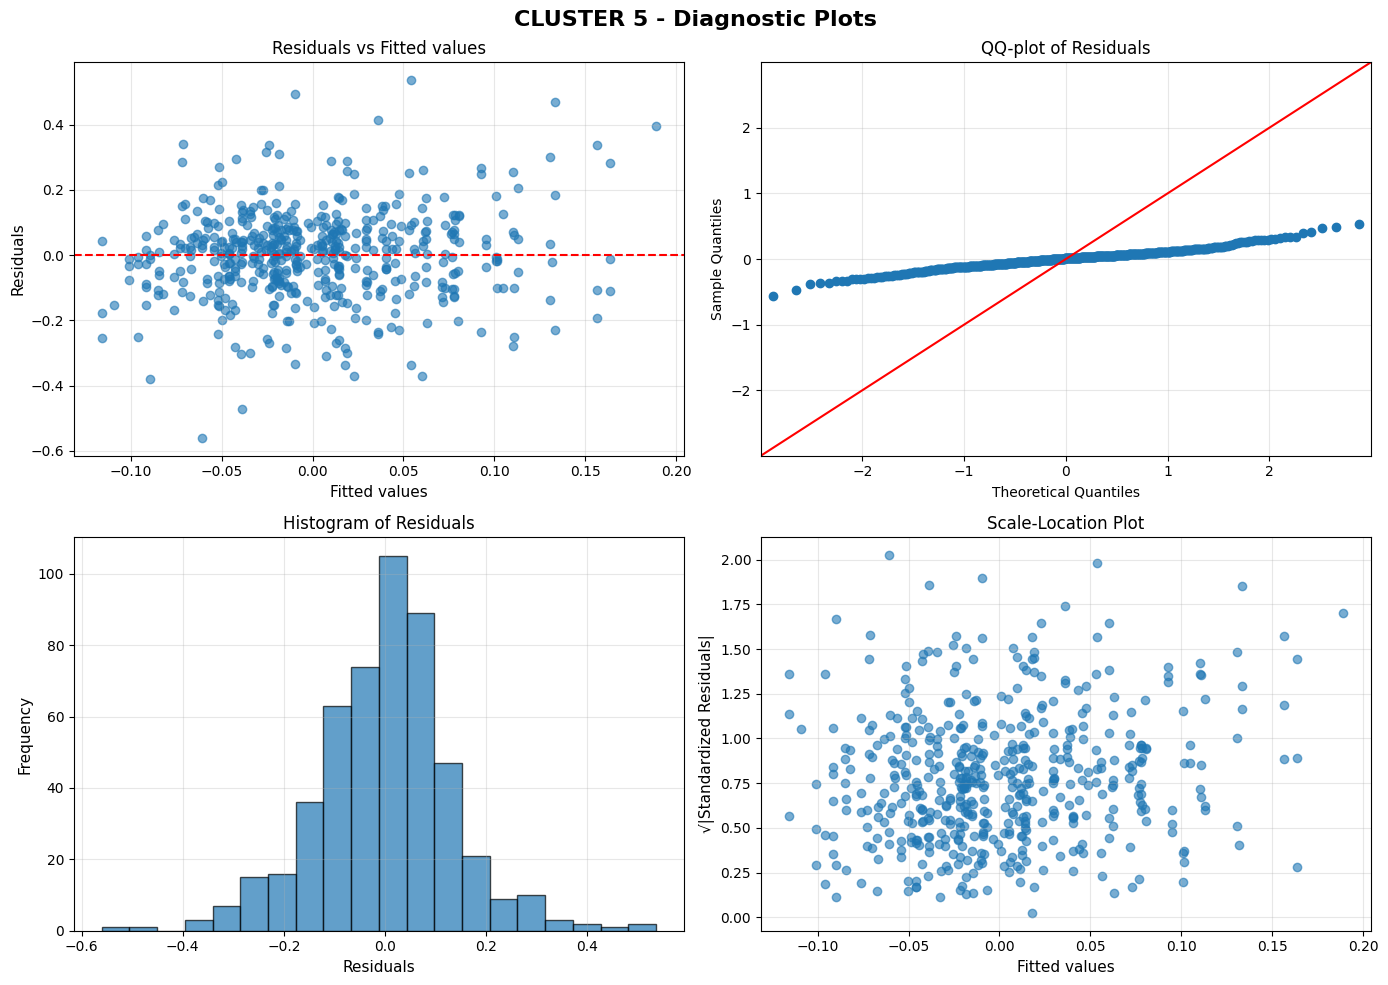


Breusch-Pagan test p-value: 0.506872
No heteroscedasticity detected. The variance of residuals is constant.

Shapiro-Wilk test p-value: 0.000001
Residuals are not normally distributed.

Variance Inflation Factors:
               feature           VIF
0            Intercept 28.6204990674
1            sess[T.2]  1.4175961444
2            sess[T.3]  1.3846942731
3            sess[T.4]  1.3788277309
4          sex[T.male]  1.1186338013
5     C(type_chx)[T.2]  1.4794887327
6     C(type_chx)[T.3]  1.7836835244
7  handedness[T.right]  1.3304906337
8         age_baseline  1.5501709623
9         bmi_baseline  1.3295402886

AIC: -404.1590
BIC: -357.6888

Wald test results:
                                chi2                P>chi2  df constraint
Intercept     [[0.3380221889959933]]    0.5609730826703943              1
sess          [[11.489961810557602]]  0.009351119910818974              3
sex           [[0.5408673173494988]]   0.46207350415965676              1
C(type_chx)    [[3.874858576617

C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with

      Parameter     R_squared
0          sess 19.9670927133
1          sess 19.9670927133
2          sess 19.9670927133
3           sex 18.0271088536
4   C(type_chx) 18.0593350528
5   C(type_chx) 18.0593350528
6    handedness 18.0250136990
7  age_baseline 13.9098463383
8  bmi_baseline 17.9542215418




C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 33.251529
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Patrick\AppData\Local\Packages\PythonSoftware

In [9]:
results = run_lmm_analysis(
    df_merged_Lo, 
    formula='mean_beta ~  sess + sex + age_baseline + bmi_baseline + C(type_chx) + handedness',
    show_diagnostics=True
)


CLUSTER 1 ANALYSIS

Model formula: mean_beta ~  sess + sex + age_baseline + bmi_baseline + C(type_chx) + handedness
Data shape: (505, 20)
Unique subjects: 57



C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


            Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   mean_beta
No. Observations:    505       Method:               REML     
No. Groups:          57        Scale:                0.0262   
Min. group size:     2         Log-Likelihood:       167.8592 
Max. group size:     12        Converged:            Yes      
Mean group size:     8.9                                      
--------------------------------------------------------------
                    Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept            0.088    0.042  2.107 0.035  0.006  0.169
sess[T.2]            0.115    0.019  5.981 0.000  0.078  0.153
sess[T.3]            0.023    0.020  1.124 0.261 -0.017  0.063
sess[T.4]            0.016    0.021  0.768 0.443 -0.025  0.056
sex[T.male]         -0.020    0.019 -1.018 0.309 -0.058  0.018
C(type_chx)[T.2]    -0.032    0.022 -1.447 0.148 -0.075  0.011
C(typ

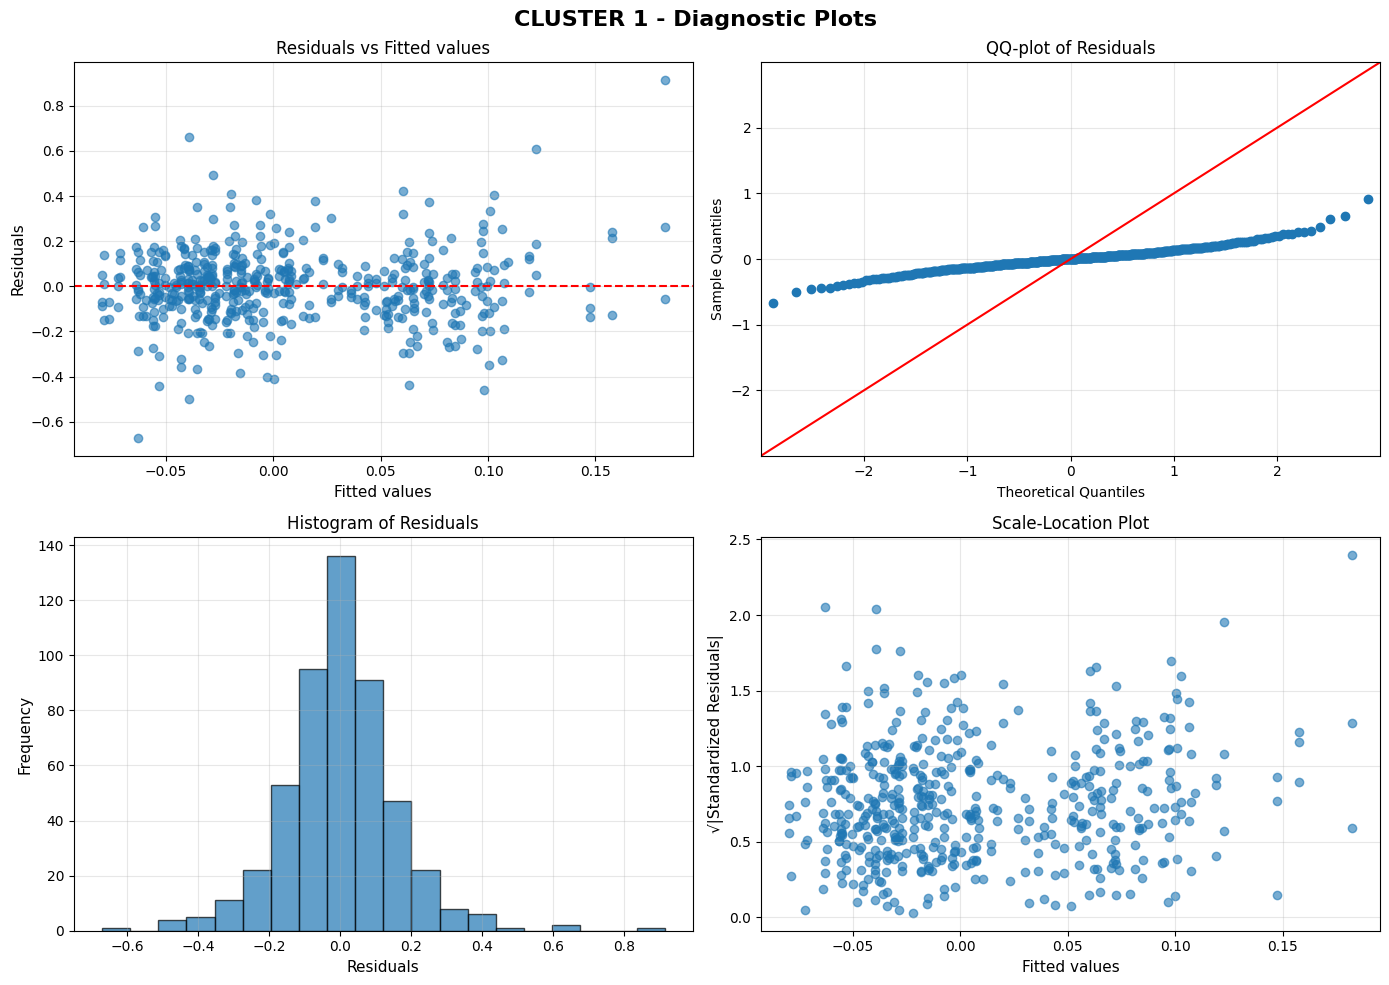


Breusch-Pagan test p-value: 0.050248
No heteroscedasticity detected. The variance of residuals is constant.

Shapiro-Wilk test p-value: 0.000000
Residuals are not normally distributed.

Variance Inflation Factors:
               feature           VIF
0            Intercept 28.6204990674
1            sess[T.2]  1.4175961444
2            sess[T.3]  1.3846942731
3            sess[T.4]  1.3788277309
4          sex[T.male]  1.1186338013
5     C(type_chx)[T.2]  1.4794887327
6     C(type_chx)[T.3]  1.7836835244
7  handedness[T.right]  1.3304906337
8         age_baseline  1.5501709623
9         bmi_baseline  1.3295402886

AIC: -313.7184
BIC: -267.2483

Wald test results:
                                 chi2                  P>chi2  df constraint
Intercept      [[4.4379852358367256]]    0.035147702506685245              1
sess            [[42.09056665752219]]  3.8384445439249495e-09              3
sex            [[1.0369227934038627]]     0.30853823025621885              1
C(type_chx)     [[4

C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Patrick\AppData\Local\Temp\ipykernel_27192\354981984.py:428: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining th

      Parameter     R_squared
0          sess 13.3527261590
1          sess 13.3527261590
2          sess 13.3527261590
3           sex  6.2893373796
4   C(type_chx)  5.4123360339
5   C(type_chx)  5.4123360339
6    handedness  5.5576823526
7  age_baseline  5.8515227434
8  bmi_baseline  6.2924684606



CLUSTER 2 ANALYSIS

Model formula: mean_beta ~  sess + sex + age_baseline + bmi_baseline + C(type_chx) + handedness
Data shape: (505, 20)
Unique subjects: 57



C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2k

            Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   mean_beta
No. Observations:    505       Method:               REML     
No. Groups:          57        Scale:                0.0246   
Min. group size:     2         Log-Likelihood:       161.7175 
Max. group size:     12        Converged:            No       
Mean group size:     8.9                                      
--------------------------------------------------------------
                    Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept            0.010    0.062  0.161 0.872 -0.112  0.132
sess[T.2]            0.092    0.019  4.888 0.000  0.055  0.129
sess[T.3]            0.036    0.020  1.795 0.073 -0.003  0.076
sess[T.4]            0.003    0.020  0.159 0.874 -0.037  0.043
sex[T.male]         -0.005    0.029 -0.185 0.853 -0.063  0.052
C(type_chx)[T.2]    -0.052    0.033 -1.600 0.110 -0.116  0.012
C(typ

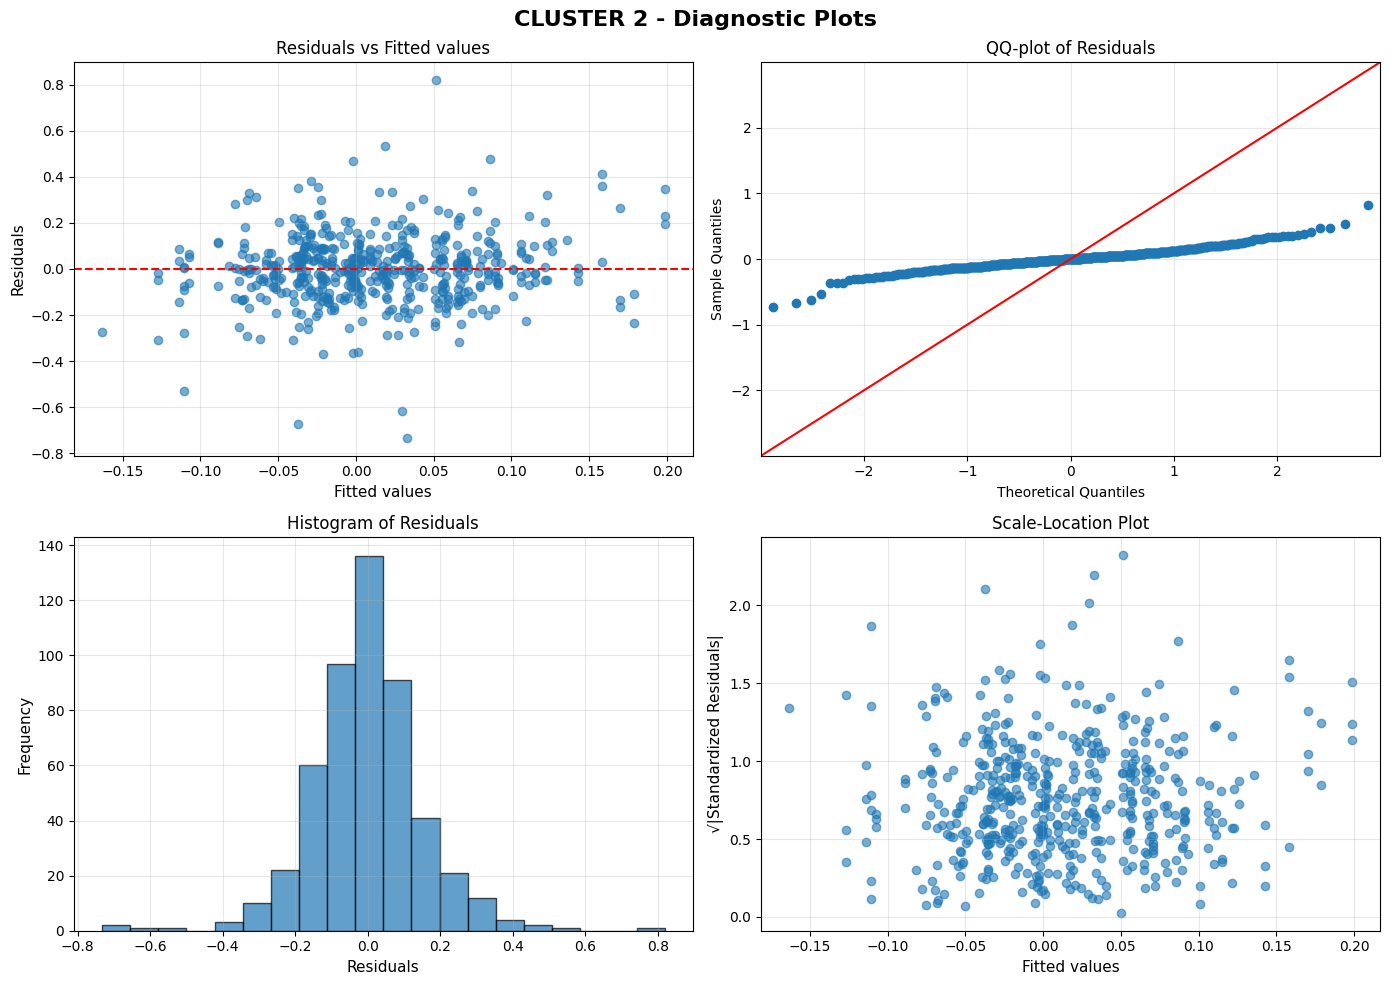


Breusch-Pagan test p-value: 0.022922
Heteroscedasticity detected. The variance of residuals is not constant.

Shapiro-Wilk test p-value: 0.000000
Residuals are not normally distributed.

Variance Inflation Factors:
               feature           VIF
0            Intercept 28.6204990674
1            sess[T.2]  1.4175961444
2            sess[T.3]  1.3846942731
3            sess[T.4]  1.3788277309
4          sex[T.male]  1.1186338013
5     C(type_chx)[T.2]  1.4794887327
6     C(type_chx)[T.3]  1.7836835244
7  handedness[T.right]  1.3304906337
8         age_baseline  1.5501709623
9         bmi_baseline  1.3295402886

AIC: -301.4350
BIC: -254.9648

Wald test results:
                                   chi2                  P>chi2  df constraint
Intercept       [[0.02604816379348916]]      0.8717827490909138              1
sess             [[29.081217184528544]]  2.1531310339717107e-06              3
sex            [[0.034146121978592854]]      0.8533963454164042              1
C(type_chx

C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Patrick\AppData\Local\Temp\ipykernel_27192\354981984.py:428: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining th

      Parameter     R_squared
0          sess 15.7939851308
1          sess 15.7939851308
2          sess 15.7939851308
3           sex  7.8544319606
4   C(type_chx) 10.5385995630
5   C(type_chx) 10.5385995630
6    handedness  7.6927708908
7  age_baseline  7.8246164368
8  bmi_baseline  7.6784128291



CLUSTER 3 ANALYSIS

Model formula: mean_beta ~  sess + sex + age_baseline + bmi_baseline + C(type_chx) + handedness
Data shape: (505, 20)
Unique subjects: 57

            Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   mean_beta
No. Observations:    505       Method:               REML     
No. Groups:          57        Scale:                0.0639   
Min. group size:     2         Log-Likelihood:       -85.1103 
Max. group size:     12        Converged:            Yes      
Mean group size:     8.9                                      
--------------------------------------------------------------
                    Coef.  Std.Err.   z    P>|z

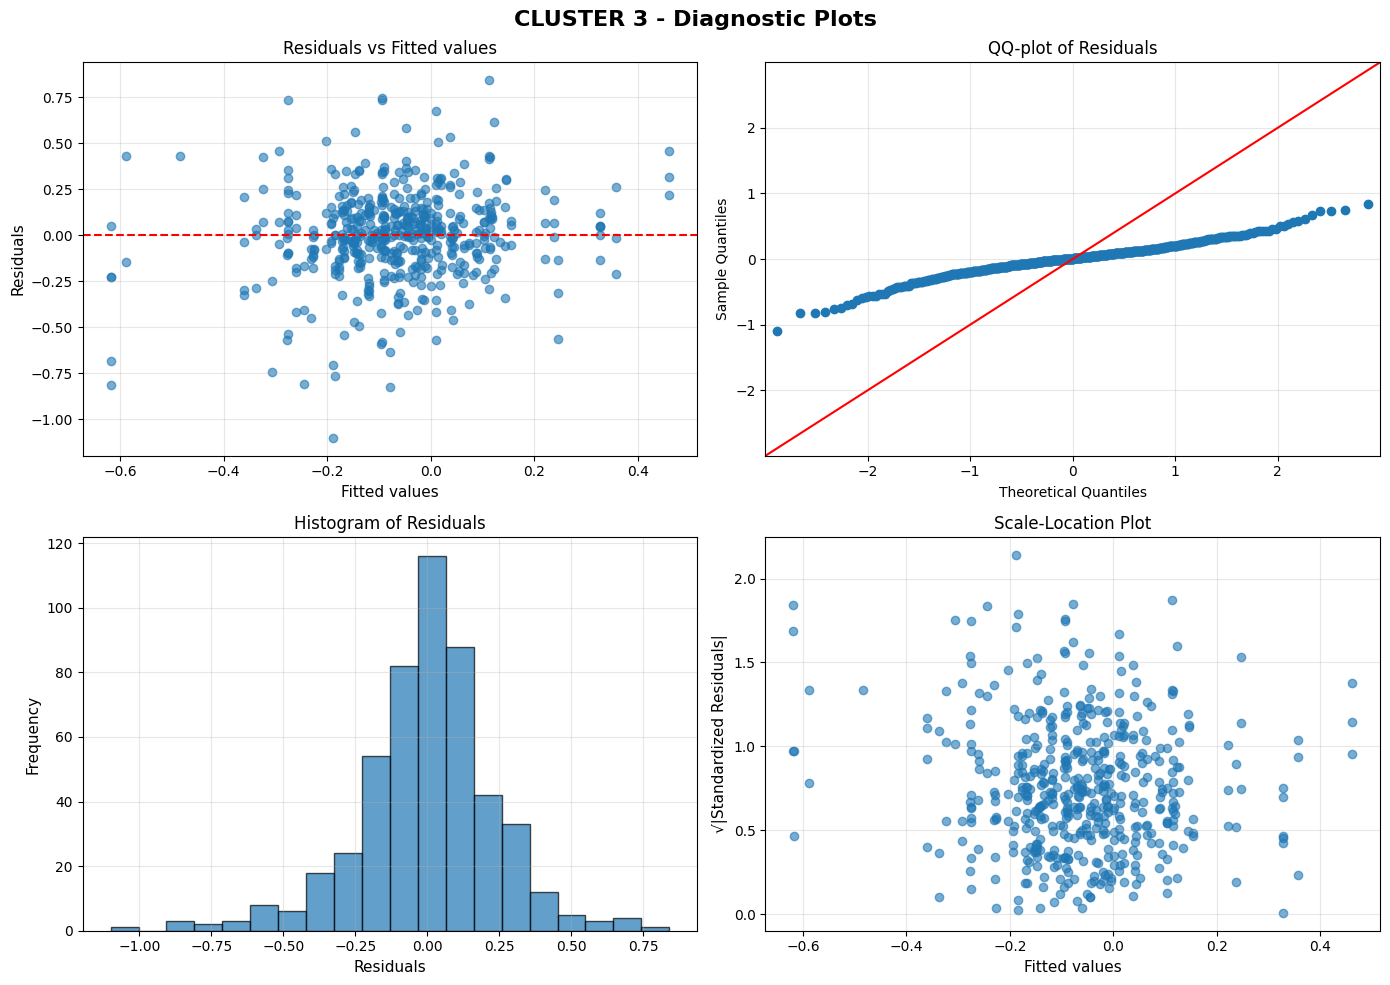


Breusch-Pagan test p-value: 0.306959
No heteroscedasticity detected. The variance of residuals is constant.

Shapiro-Wilk test p-value: 0.000000
Residuals are not normally distributed.

Variance Inflation Factors:
               feature           VIF
0            Intercept 28.6204990674
1            sess[T.2]  1.4175961444
2            sess[T.3]  1.3846942731
3            sess[T.4]  1.3788277309
4          sex[T.male]  1.1186338013
5     C(type_chx)[T.2]  1.4794887327
6     C(type_chx)[T.3]  1.7836835244
7  handedness[T.right]  1.3304906337
8         age_baseline  1.5501709623
9         bmi_baseline  1.3295402886

AIC: 192.2205
BIC: 238.6907

Wald test results:
                                  chi2                  P>chi2  df constraint
Intercept       [[0.5960845364985518]]     0.44007586448083647              1
sess            [[25.428875333893988]]  1.2559223231059966e-05              3
sex              [[0.541154728065549]]      0.4619545633418243              1
C(type_chx)     [

C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
C:\Users\Patrick\AppData\Local\Temp\ipykernel_27192\354981984.py:428: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  r_squared_data = pd.concat([r_squared_data,


      Parameter     R_squared
0          sess 35.3781555600
1          sess 35.3781555600
2          sess 35.3781555600
3           sex 32.0262882291
4   C(type_chx) 32.0595451543
5   C(type_chx) 32.0595451543
6    handedness 31.9700326973
7  age_baseline 31.9866726449
8  bmi_baseline 32.0060639427



CLUSTER 4 ANALYSIS

Model formula: mean_beta ~  sess + sex + age_baseline + bmi_baseline + C(type_chx) + handedness
Data shape: (505, 20)
Unique subjects: 57



C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


            Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   mean_beta
No. Observations:    505       Method:               REML     
No. Groups:          57        Scale:                0.0222   
Min. group size:     2         Log-Likelihood:       208.5339 
Max. group size:     12        Converged:            Yes      
Mean group size:     8.9                                      
--------------------------------------------------------------
                    Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept            0.044    0.039  1.140 0.254 -0.032  0.120
sess[T.2]            0.086    0.018  4.826 0.000  0.051  0.121
sess[T.3]            0.006    0.019  0.311 0.756 -0.031  0.043
sess[T.4]            0.024    0.019  1.277 0.202 -0.013  0.062
sex[T.male]         -0.046    0.018 -2.572 0.010 -0.082 -0.011
C(type_chx)[T.2]    -0.018    0.021 -0.892 0.372 -0.059  0.022
C(typ

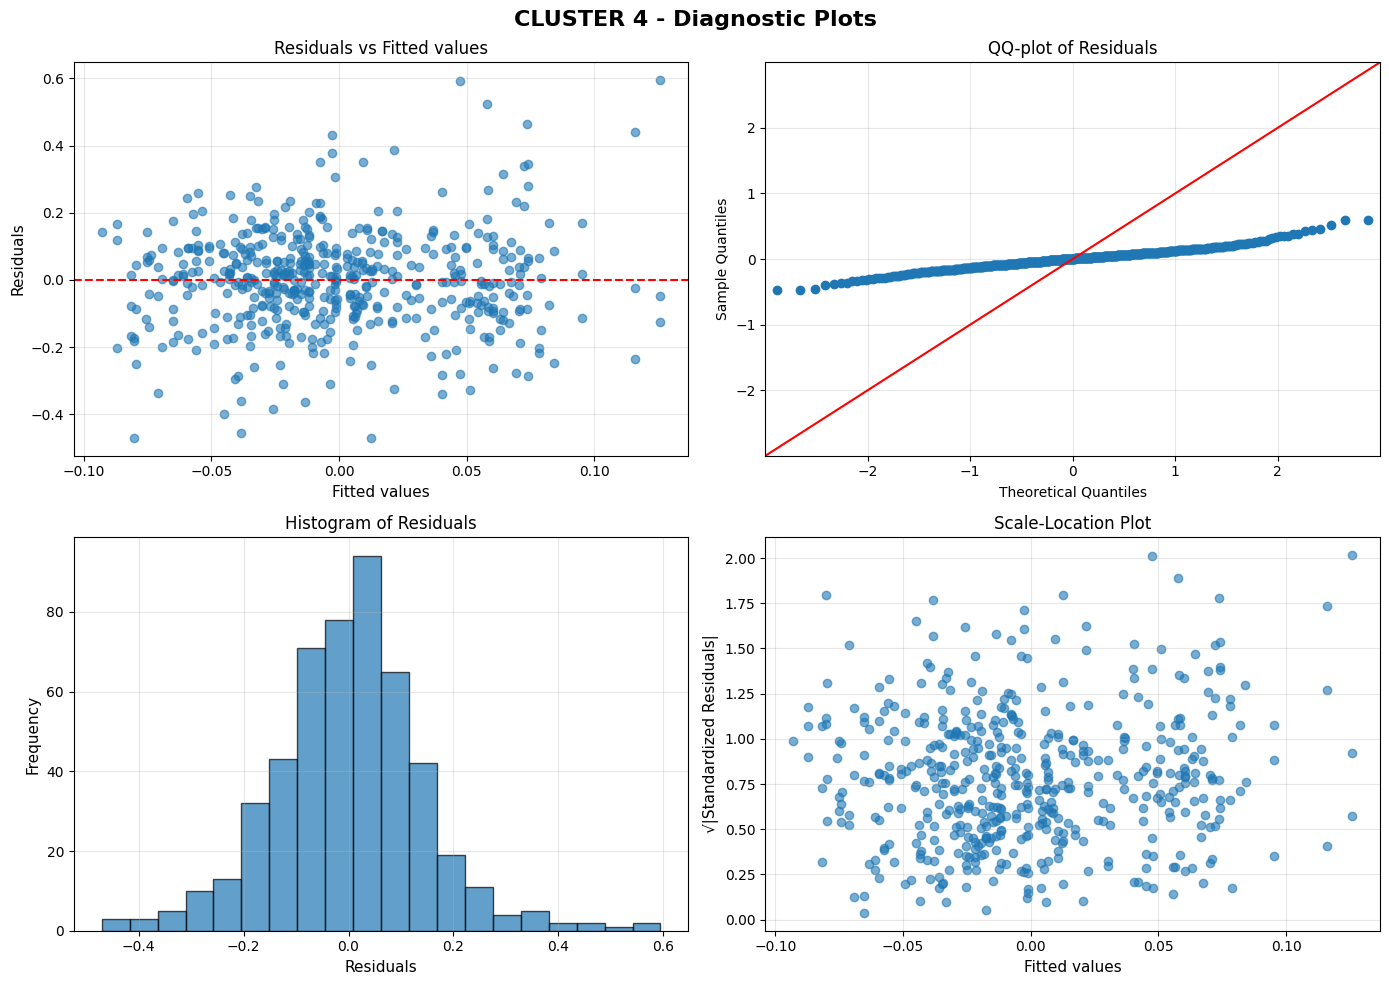


Breusch-Pagan test p-value: 0.000412
Heteroscedasticity detected. The variance of residuals is not constant.

Shapiro-Wilk test p-value: 0.000001
Residuals are not normally distributed.

Variance Inflation Factors:
               feature           VIF
0            Intercept 28.6204990674
1            sess[T.2]  1.4175961444
2            sess[T.3]  1.3846942731
3            sess[T.4]  1.3788277309
4          sex[T.male]  1.1186338013
5     C(type_chx)[T.2]  1.4794887327
6     C(type_chx)[T.3]  1.7836835244
7  handedness[T.right]  1.3304906337
8         age_baseline  1.5501709623
9         bmi_baseline  1.3295402886

AIC: -395.0677
BIC: -348.5976

Wald test results:
                                 chi2                 P>chi2  df constraint
Intercept       [[1.298944311089184]]     0.2544061473850084              1
sess           [[28.042126351116522]]  3.558835544627136e-06              3
sex            [[6.6143102387412815]]   0.010116251350523303              1
C(type_chx)    [[1.194

C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Patrick\AppData\Local\Temp\ipykernel_27192\354981984.py:428: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining th

      Parameter     R_squared
0          sess 10.9795176104
1          sess 10.9795176104
2          sess 10.9795176104
3           sex  4.0695656028
4   C(type_chx)  4.2670975713
5   C(type_chx)  4.2670975713
6    handedness  4.2639483693
7  age_baseline  4.5770823320
8  bmi_baseline  4.3164240934



CLUSTER 5 ANALYSIS

Model formula: mean_beta ~  sess + sex + age_baseline + bmi_baseline + C(type_chx) + handedness
Data shape: (505, 20)
Unique subjects: 57



C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2k

            Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   mean_beta
No. Observations:    505       Method:               REML     
No. Groups:          57        Scale:                0.0425   
Min. group size:     2         Log-Likelihood:       27.0058  
Max. group size:     12        Converged:            No       
Mean group size:     8.9                                      
--------------------------------------------------------------
                    Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept           -0.172    0.082 -2.112 0.035 -0.332 -0.012
sess[T.2]            0.118    0.025  4.759 0.000  0.069  0.166
sess[T.3]            0.048    0.026  1.793 0.073 -0.004  0.099
sess[T.4]            0.052    0.027  1.944 0.052 -0.000  0.104
sex[T.male]         -0.007    0.038 -0.184 0.854 -0.082  0.068
C(type_chx)[T.2]    -0.014    0.043 -0.320 0.749 -0.097  0.070
C(typ

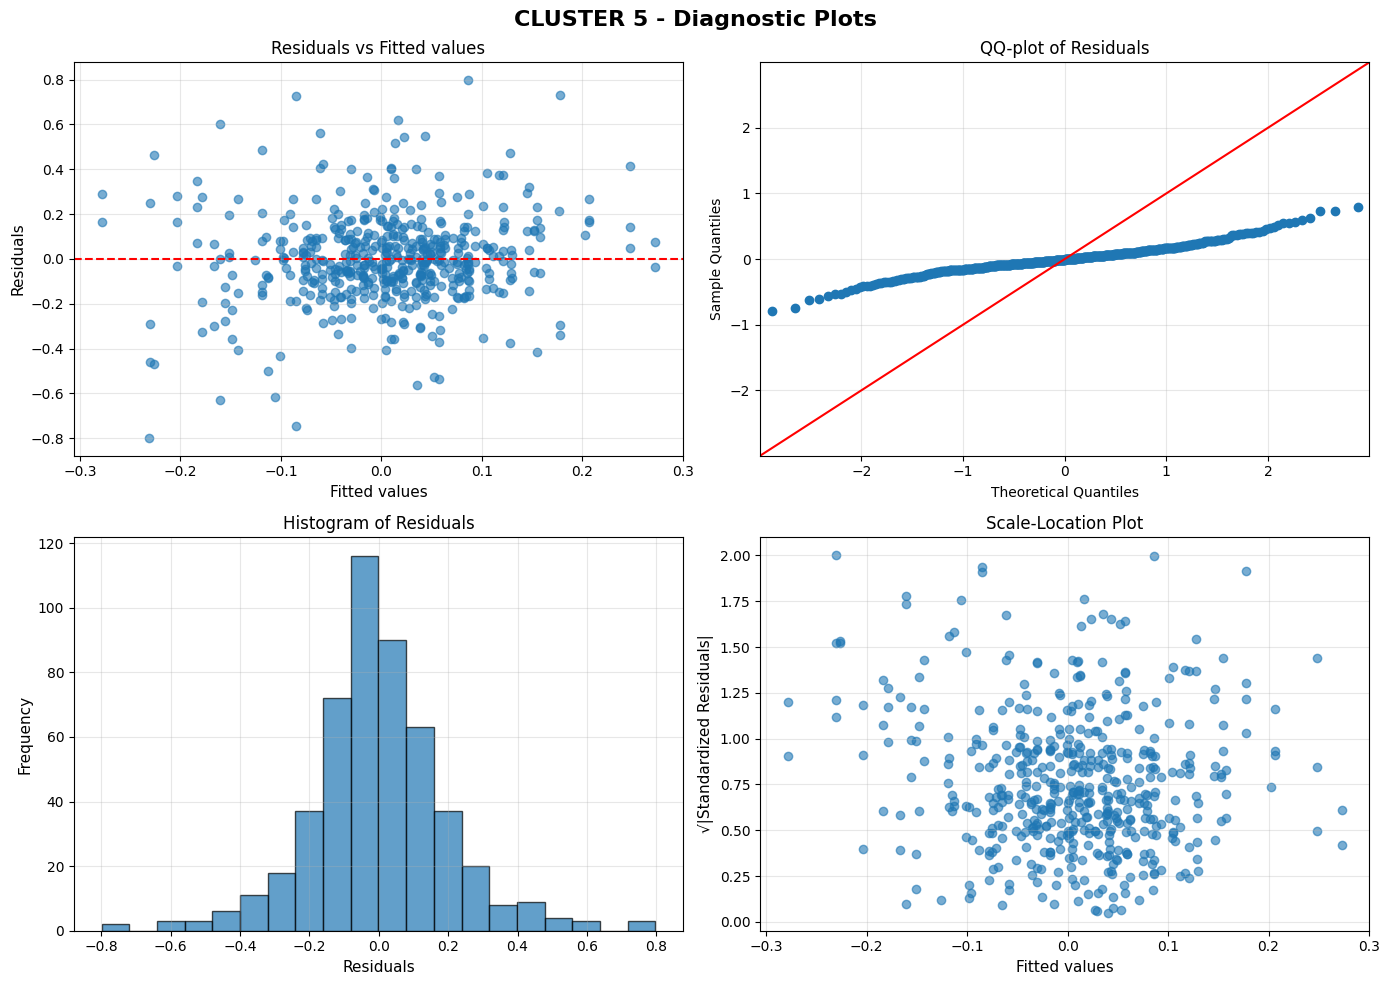


Breusch-Pagan test p-value: 0.000357
Heteroscedasticity detected. The variance of residuals is not constant.

Shapiro-Wilk test p-value: 0.000000
Residuals are not normally distributed.

Variance Inflation Factors:
               feature           VIF
0            Intercept 28.6204990674
1            sess[T.2]  1.4175961444
2            sess[T.3]  1.3846942731
3            sess[T.4]  1.3788277309
4          sex[T.male]  1.1186338013
5     C(type_chx)[T.2]  1.4794887327
6     C(type_chx)[T.3]  1.7836835244
7  handedness[T.right]  1.3304906337
8         age_baseline  1.5501709623
9         bmi_baseline  1.3295402886

AIC: -32.0116
BIC: 14.4585

Wald test results:
                                chi2                 P>chi2  df constraint
Intercept      [[4.460465144288127]]   0.034688050567953314              1
sess          [[22.822566627467836]]  4.397205518597277e-05              3
sex           [[0.0336926833254066]]     0.8543620437527343              1
C(type_chx)    [[2.3924469773

C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with

      Parameter     R_squared
0          sess 20.2280979415
1          sess 20.2280979415
2          sess 20.2280979415
3           sex 16.0526489325
4   C(type_chx) 19.0194565735
5   C(type_chx) 19.0194565735
6    handedness 15.6212269848
7  age_baseline 19.1582118515
8  bmi_baseline 16.0269806788




C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [10]:
results = run_lmm_analysis(
    df_merged_Hi_v_Lo, 
    formula='mean_beta ~  sess + sex + age_baseline + bmi_baseline + C(type_chx) + handedness',
    show_diagnostics=True
)

In [11]:
df_merged_concat_Hi_Lo = pd.concat([df_merged_Hi, df_merged_Lo], ignore_index=True)


CLUSTER 1 ANALYSIS

Model formula: mean_beta ~  sess*calorie + sex + age_baseline + bmi_baseline + C(type_chx) + handedness
Data shape: (1010, 21)
Unique subjects: 57



C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


               Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     mean_beta
No. Observations:     1010        Method:                 REML     
No. Groups:           57          Scale:                  0.0142   
Min. group size:      4           Log-Likelihood:         654.3753 
Max. group size:      24          Converged:              Yes      
Mean group size:      17.7                                         
-------------------------------------------------------------------
                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------
Intercept                -0.016    0.026 -0.630 0.529 -0.068  0.035
sess[T.2]                 0.080    0.014  5.655 0.000  0.053  0.108
sess[T.3]                 0.016    0.015  1.033 0.301 -0.014  0.045
sess[T.4]                 0.012    0.015  0.811 0.417 -0.017  0.042
calorie[T.low]            0.035    0.014  2.486 0.013  0.007  0

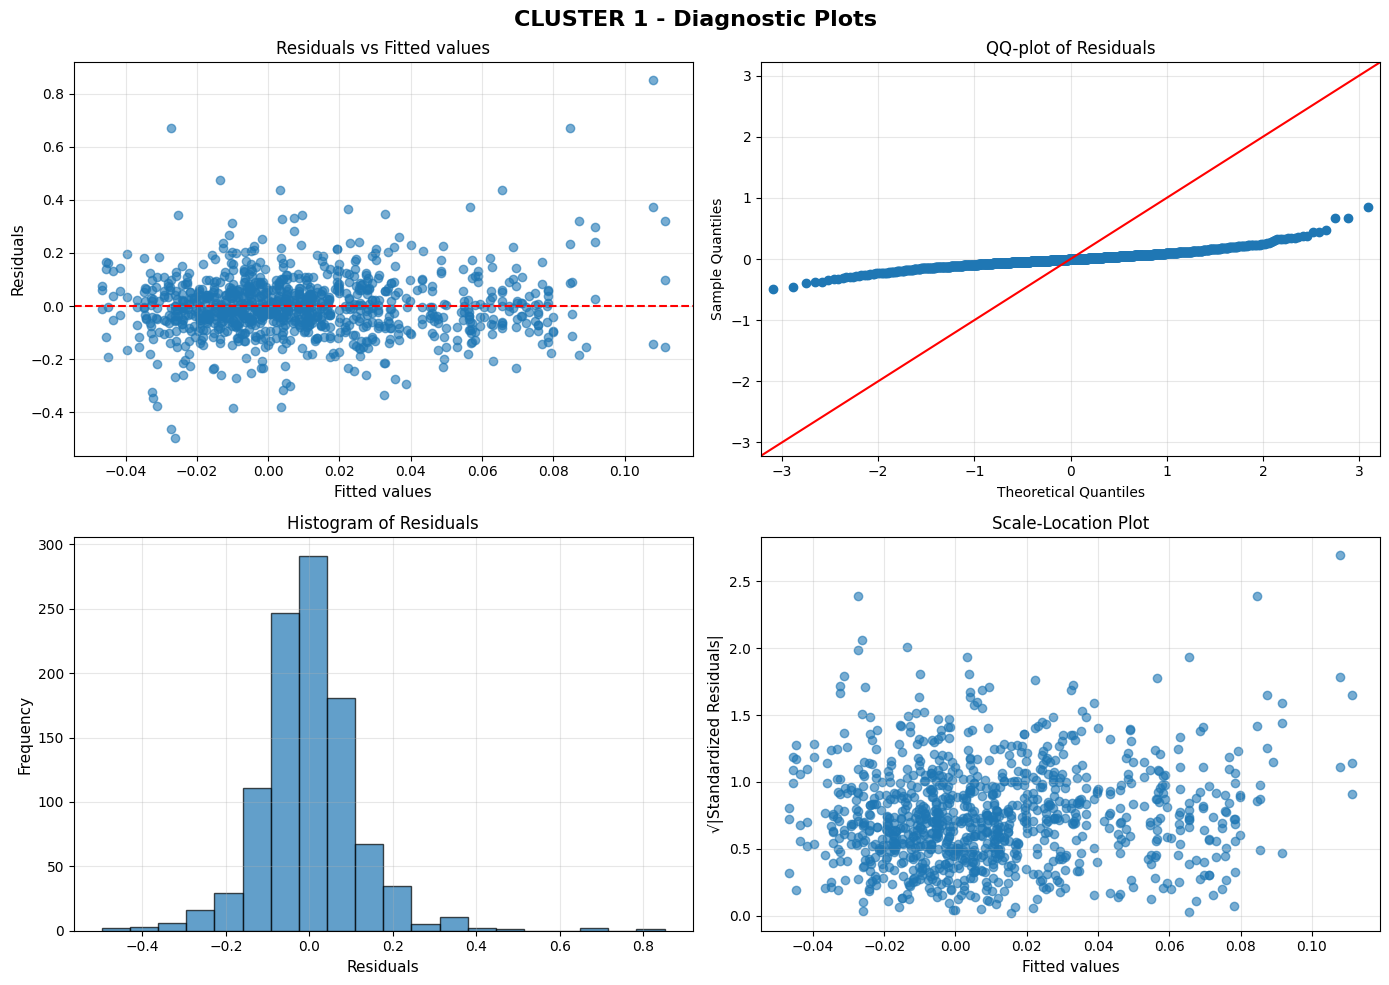


Breusch-Pagan test p-value: 0.000569
Heteroscedasticity detected. The variance of residuals is not constant.

Shapiro-Wilk test p-value: 0.000000
Residuals are not normally distributed.

Variance Inflation Factors:
                     feature           VIF
0                  Intercept 32.0794031770
1                  sess[T.2]  2.8312405225
2                  sess[T.3]  2.7599011089
3                  sess[T.4]  2.7484194846
4             calorie[T.low]  3.4589041096
5                sex[T.male]  1.1186338013
6           C(type_chx)[T.2]  1.4794887327
7           C(type_chx)[T.3]  1.7836835244
8        handedness[T.right]  1.3304906337
9   sess[T.2]:calorie[T.low]  3.3588498576
10  sess[T.3]:calorie[T.low]  3.1423301234
11  sess[T.4]:calorie[T.low]  3.1161670962
12              age_baseline  1.5501709623
13              bmi_baseline  1.3295402886

AIC: -1278.7506
BIC: -1204.9850

Wald test results:
                                  chi2                  P>chi2  df constraint
Intercep

C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Patrick\AppData\Local\Temp\ipykernel_27192\354981984.py:428: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining th

       Parameter    R_squared
0           sess 4.9095978891
1           sess 4.9095978891
2           sess 4.9095978891
3        calorie 4.6210663737
4            sex 4.6032136727
5    C(type_chx) 4.7341628914
6    C(type_chx) 4.7341628914
7     handedness 4.7033718730
8           sess 4.9095978891
9           sess 4.9095978891
10          sess 4.9095978891
11  age_baseline 4.6951908821
12  bmi_baseline 4.3160385163



CLUSTER 2 ANALYSIS

Model formula: mean_beta ~  sess*calorie + sex + age_baseline + bmi_baseline + C(type_chx) + handedness
Data shape: (1010, 21)
Unique subjects: 57



C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


               Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     mean_beta
No. Observations:     1010        Method:                 REML     
No. Groups:           57          Scale:                  0.0139   
Min. group size:      4           Log-Likelihood:         659.0631 
Max. group size:      24          Converged:              Yes      
Mean group size:      17.7                                         
-------------------------------------------------------------------
                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------
Intercept                -0.023    0.029 -0.766 0.444 -0.080  0.035
sess[T.2]                 0.075    0.014  5.325 0.000  0.047  0.102
sess[T.3]                 0.025    0.015  1.654 0.098 -0.005  0.054
sess[T.4]                 0.006    0.015  0.397 0.692 -0.024  0.036
calorie[T.low]            0.020    0.014  1.468 0.142 -0.007  0

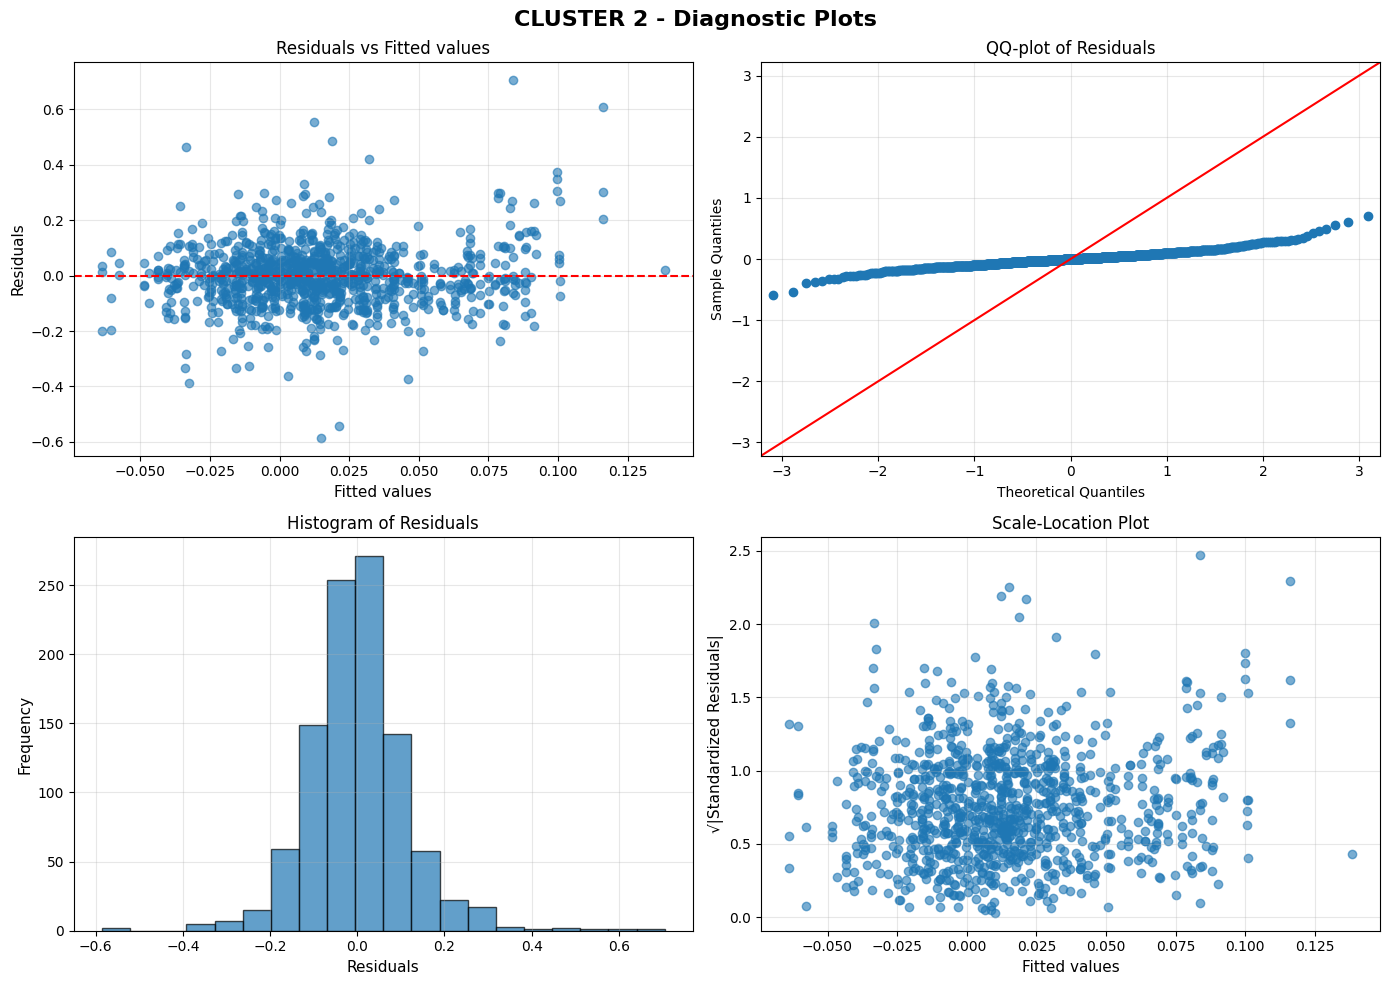


Breusch-Pagan test p-value: 0.002847
Heteroscedasticity detected. The variance of residuals is not constant.

Shapiro-Wilk test p-value: 0.000000
Residuals are not normally distributed.

Variance Inflation Factors:
                     feature           VIF
0                  Intercept 32.0794031770
1                  sess[T.2]  2.8312405225
2                  sess[T.3]  2.7599011089
3                  sess[T.4]  2.7484194846
4             calorie[T.low]  3.4589041096
5                sex[T.male]  1.1186338013
6           C(type_chx)[T.2]  1.4794887327
7           C(type_chx)[T.3]  1.7836835244
8        handedness[T.right]  1.3304906337
9   sess[T.2]:calorie[T.low]  3.3588498576
10  sess[T.3]:calorie[T.low]  3.1423301234
11  sess[T.4]:calorie[T.low]  3.1161670962
12              age_baseline  1.5501709623
13              bmi_baseline  1.3295402886

AIC: -1288.1262
BIC: -1214.3606

Wald test results:
                                  chi2                  P>chi2  df constraint
Intercep

C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Patrick\AppData\Local\Temp\ipykernel_27192\354981984.py:428: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining th

       Parameter    R_squared
0           sess 8.6552737195
1           sess 8.6552737195
2           sess 8.6552737195
3        calorie 7.9729571280
4            sex 7.8550867977
5    C(type_chx) 7.5696140627
6    C(type_chx) 7.5696140627
7     handedness 7.8183991108
8           sess 8.6552737195
9           sess 8.6552737195
10          sess 8.6552737195
11  age_baseline 7.8353596798
12  bmi_baseline 7.7732571163



CLUSTER 3 ANALYSIS

Model formula: mean_beta ~  sess*calorie + sex + age_baseline + bmi_baseline + C(type_chx) + handedness
Data shape: (1010, 21)
Unique subjects: 57



C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


               Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     mean_beta
No. Observations:     1010        Method:                 REML     
No. Groups:           57          Scale:                  0.0390   
Min. group size:      4           Log-Likelihood:         144.5410 
Max. group size:      24          Converged:              Yes      
Mean group size:      17.7                                         
-------------------------------------------------------------------
                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------
Intercept                 0.067    0.050  1.336 0.182 -0.032  0.166
sess[T.2]                -0.098    0.024 -4.143 0.000 -0.144 -0.051
sess[T.3]                -0.065    0.025 -2.614 0.009 -0.115 -0.016
sess[T.4]                -0.083    0.025 -3.307 0.001 -0.133 -0.034
calorie[T.low]           -0.032    0.023 -1.391 0.164 -0.077  0

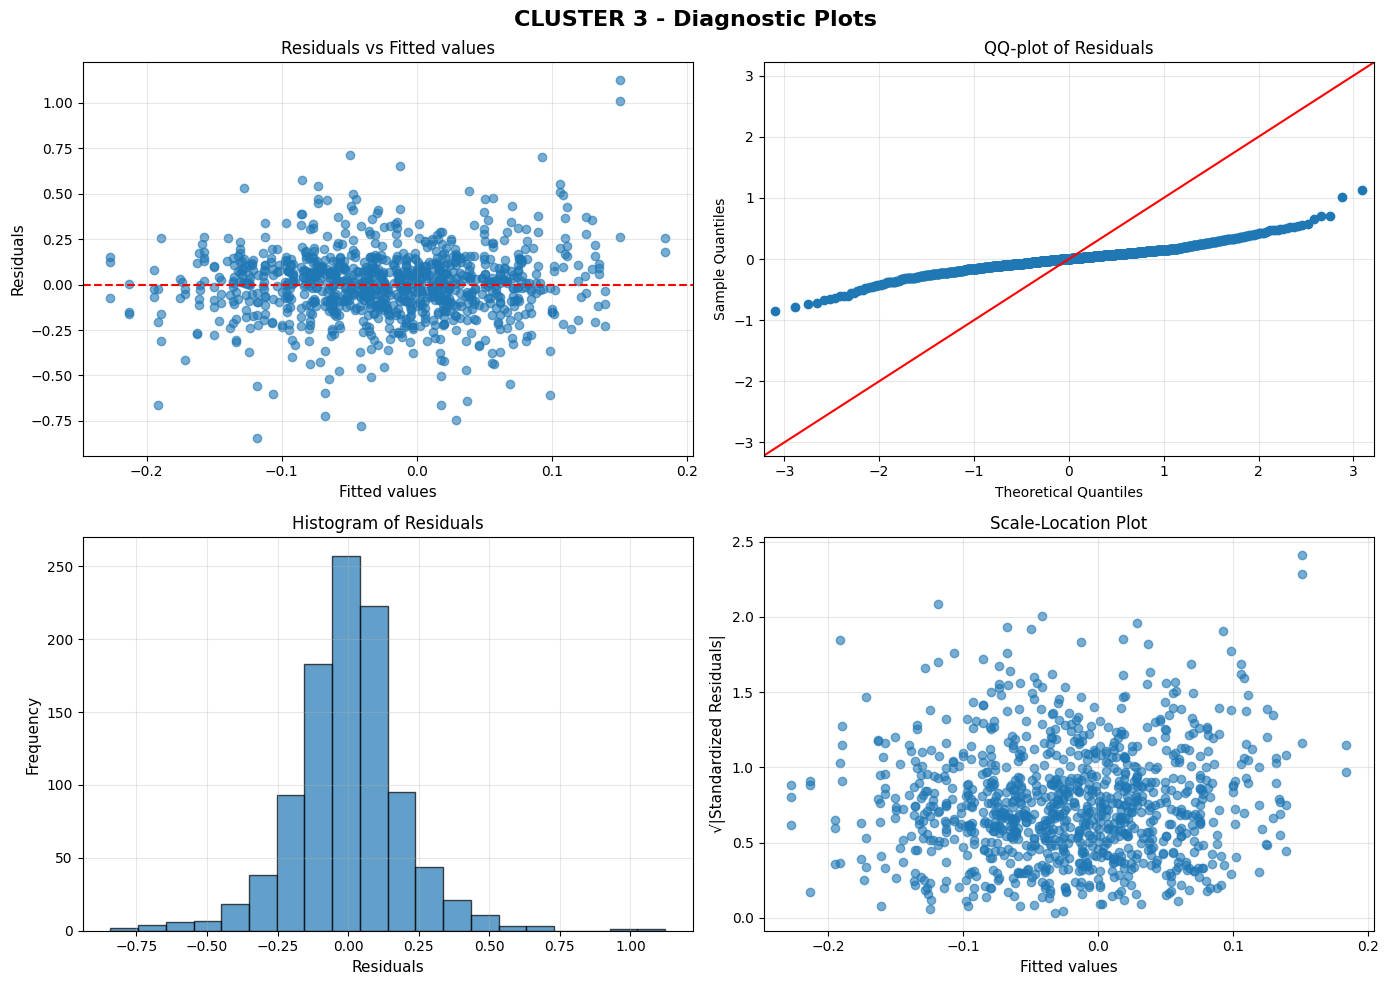


Breusch-Pagan test p-value: 0.029670
Heteroscedasticity detected. The variance of residuals is not constant.

Shapiro-Wilk test p-value: 0.000000
Residuals are not normally distributed.

Variance Inflation Factors:
                     feature           VIF
0                  Intercept 32.0794031770
1                  sess[T.2]  2.8312405225
2                  sess[T.3]  2.7599011089
3                  sess[T.4]  2.7484194846
4             calorie[T.low]  3.4589041096
5                sex[T.male]  1.1186338013
6           C(type_chx)[T.2]  1.4794887327
7           C(type_chx)[T.3]  1.7836835244
8        handedness[T.right]  1.3304906337
9   sess[T.2]:calorie[T.low]  3.3588498576
10  sess[T.3]:calorie[T.low]  3.1423301234
11  sess[T.4]:calorie[T.low]  3.1161670962
12              age_baseline  1.5501709623
13              bmi_baseline  1.3295402886

AIC: -259.0820
BIC: -185.3164

Wald test results:
                                chi2                  P>chi2  df constraint
Intercept   

C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Patrick\AppData\Local\Temp\ipykernel_27192\354981984.py:428: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining th

       Parameter     R_squared
0           sess 11.5780919281
1           sess 11.5780919281
2           sess 11.5780919281
3        calorie 13.4111176690
4            sex 11.0625677094
5    C(type_chx) 11.1196316299
6    C(type_chx) 11.1196316299
7     handedness 11.0452627646
8           sess 11.5780919281
9           sess 11.5780919281
10          sess 11.5780919281
11  age_baseline 10.6975176649
12  bmi_baseline 11.0289319698



CLUSTER 4 ANALYSIS

Model formula: mean_beta ~  sess*calorie + sex + age_baseline + bmi_baseline + C(type_chx) + handedness
Data shape: (1010, 21)
Unique subjects: 57



C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


               Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     mean_beta
No. Observations:     1010        Method:                 REML     
No. Groups:           57          Scale:                  0.0124   
Min. group size:      4           Log-Likelihood:         719.4251 
Max. group size:      24          Converged:              Yes      
Mean group size:      17.7                                         
-------------------------------------------------------------------
                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------
Intercept                -0.016    0.025 -0.631 0.528 -0.066  0.034
sess[T.2]                 0.052    0.013  3.944 0.000  0.026  0.078
sess[T.3]                -0.007    0.014 -0.522 0.602 -0.035  0.020
sess[T.4]                 0.007    0.014  0.476 0.634 -0.021  0.035
calorie[T.low]            0.031    0.013  2.341 0.019  0.005  0

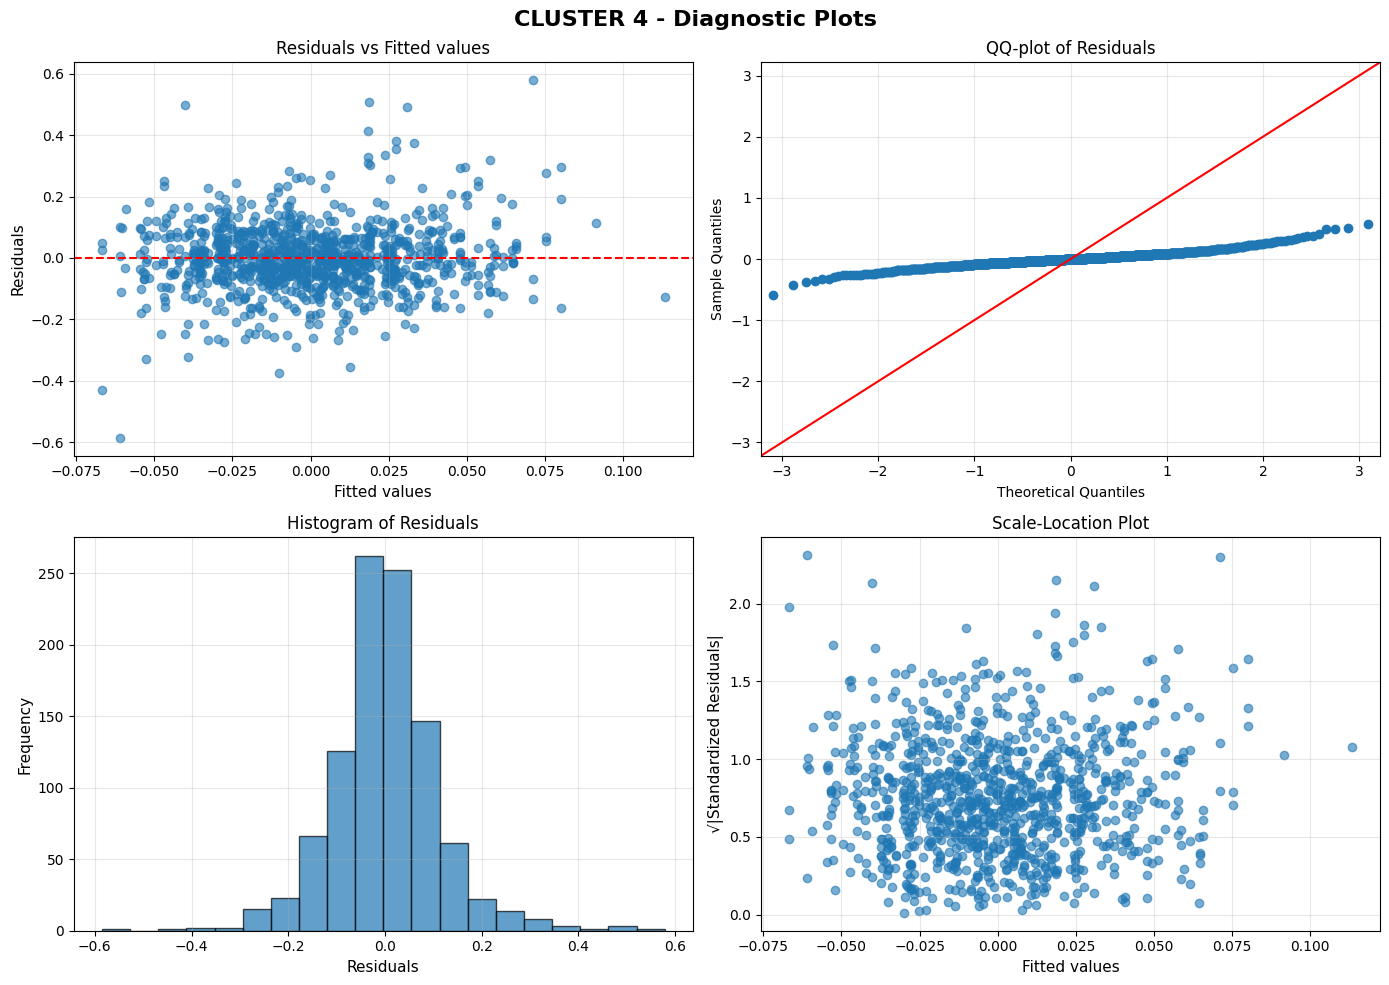


Breusch-Pagan test p-value: 0.002697
Heteroscedasticity detected. The variance of residuals is not constant.

Shapiro-Wilk test p-value: 0.000000
Residuals are not normally distributed.

Variance Inflation Factors:
                     feature           VIF
0                  Intercept 32.0794031770
1                  sess[T.2]  2.8312405225
2                  sess[T.3]  2.7599011089
3                  sess[T.4]  2.7484194846
4             calorie[T.low]  3.4589041096
5                sex[T.male]  1.1186338013
6           C(type_chx)[T.2]  1.4794887327
7           C(type_chx)[T.3]  1.7836835244
8        handedness[T.right]  1.3304906337
9   sess[T.2]:calorie[T.low]  3.3588498576
10  sess[T.3]:calorie[T.low]  3.1423301234
11  sess[T.4]:calorie[T.low]  3.1161670962
12              age_baseline  1.5501709623
13              bmi_baseline  1.3295402886

AIC: -1408.8502
BIC: -1335.0846

Wald test results:
                                 chi2                  P>chi2  df constraint
Intercept

C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Patrick\AppData\Local\Temp\ipykernel_27192\354981984.py:428: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining th

       Parameter    R_squared
0           sess 7.3451335553
1           sess 7.3451335553
2           sess 7.3451335553
3        calorie 7.0071957534
4            sex 6.8552765671
5    C(type_chx) 7.2715992882
6    C(type_chx) 7.2715992882
7     handedness 7.0985331091
8           sess 7.3451335553
9           sess 7.3451335553
10          sess 7.3451335553
11  age_baseline 6.9696817597
12  bmi_baseline 7.1106708892



CLUSTER 5 ANALYSIS

Model formula: mean_beta ~  sess*calorie + sex + age_baseline + bmi_baseline + C(type_chx) + handedness
Data shape: (1010, 21)
Unique subjects: 57



C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


               Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     mean_beta
No. Observations:     1010        Method:                 REML     
No. Groups:           57          Scale:                  0.0221   
Min. group size:      4           Log-Likelihood:         439.0810 
Max. group size:      24          Converged:              Yes      
Mean group size:      17.7                                         
-------------------------------------------------------------------
                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------
Intercept                -0.068    0.030 -2.286 0.022 -0.126 -0.010
sess[T.2]                 0.058    0.018  3.270 0.001  0.023  0.093
sess[T.3]                 0.013    0.019  0.705 0.481 -0.024  0.050
sess[T.4]                 0.016    0.019  0.828 0.407 -0.021  0.053
calorie[T.low]            0.045    0.017  2.608 0.009  0.011  0

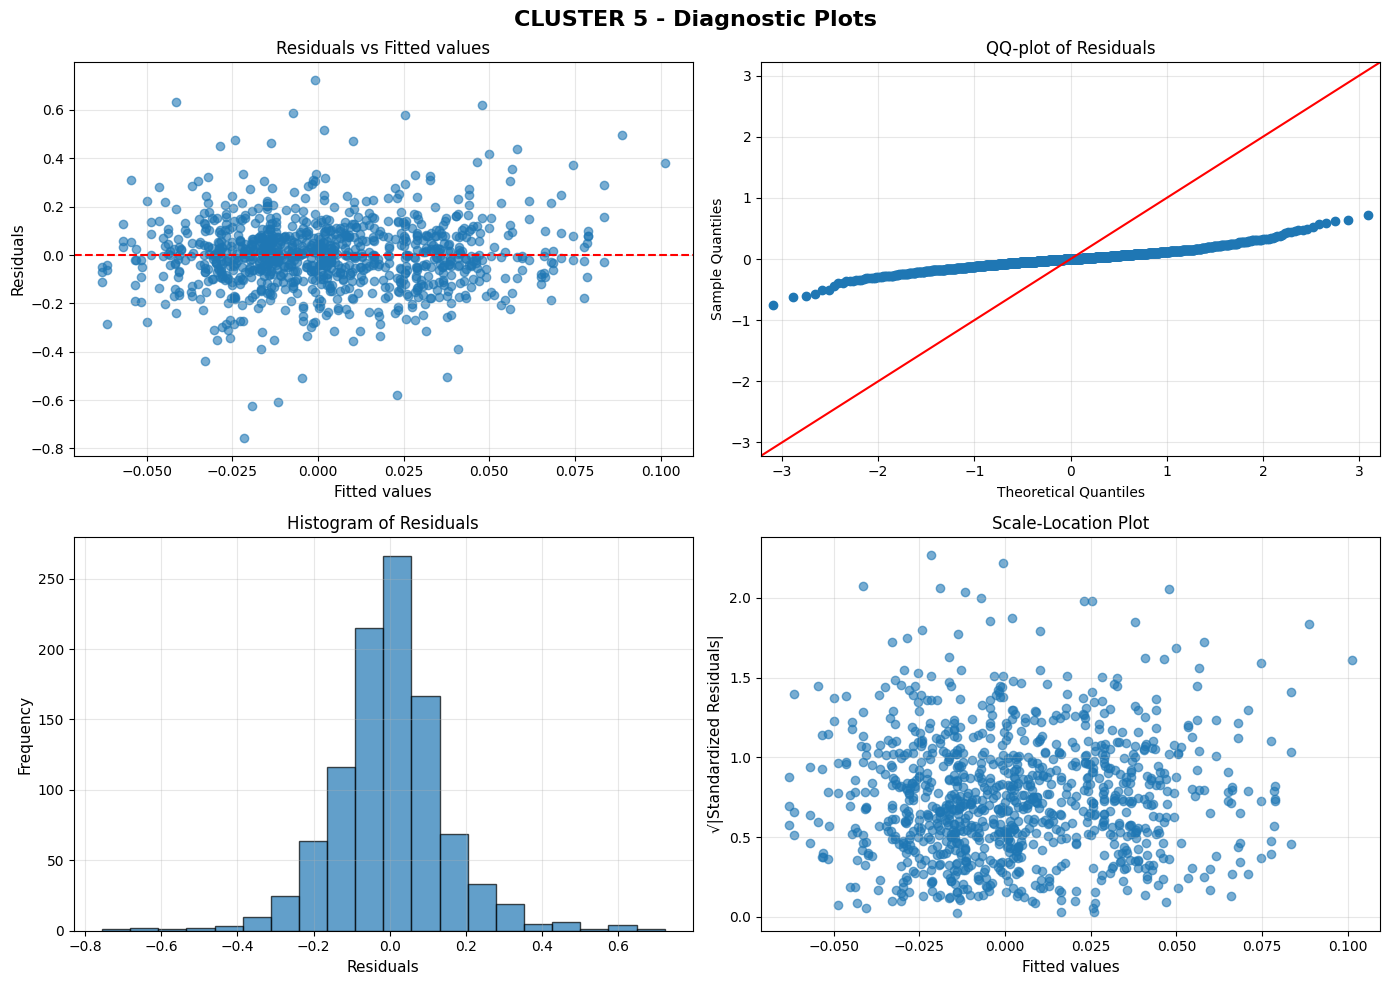


Breusch-Pagan test p-value: 0.003837
Heteroscedasticity detected. The variance of residuals is not constant.

Shapiro-Wilk test p-value: 0.000000
Residuals are not normally distributed.

Variance Inflation Factors:
                     feature           VIF
0                  Intercept 32.0794031770
1                  sess[T.2]  2.8312405225
2                  sess[T.3]  2.7599011089
3                  sess[T.4]  2.7484194846
4             calorie[T.low]  3.4589041096
5                sex[T.male]  1.1186338013
6           C(type_chx)[T.2]  1.4794887327
7           C(type_chx)[T.3]  1.7836835244
8        handedness[T.right]  1.3304906337
9   sess[T.2]:calorie[T.low]  3.3588498576
10  sess[T.3]:calorie[T.low]  3.1423301234
11  sess[T.4]:calorie[T.low]  3.1161670962
12              age_baseline  1.5501709623
13              bmi_baseline  1.3295402886

AIC: -848.1620
BIC: -774.3965

Wald test results:
                                chi2                 P>chi2  df constraint
Intercept    

C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Patrick\AppData\Local\Temp\ipykernel_27192\354981984.py:428: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining th

       Parameter    R_squared
0           sess 3.1124704788
1           sess 3.1124704788
2           sess 3.1124704788
3        calorie 3.0599433746
4            sex 3.0858191487
5    C(type_chx) 3.3548570212
6    C(type_chx) 3.3548570212
7     handedness 3.2400051882
8           sess 3.1124704788
9           sess 3.1124704788
10          sess 3.1124704788
11  age_baseline 3.2098423099
12  bmi_baseline 2.6283612845




C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [12]:
results = run_lmm_analysis(
    df_merged_concat_Hi_Lo, 
    formula='mean_beta ~  sess*calorie + sex + age_baseline + bmi_baseline + C(type_chx) + handedness',
    show_diagnostics=True
)

## Cluster 1 dlpfc


CLUSTER 1 ANALYSIS

Model formula: mean_beta ~ sess*calorie + sex + age_baseline + bmi_baseline + C(type_chx) + handedness
Data shape: (1010, 21)
Unique subjects: 57



C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not fo

               Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     mean_beta
No. Observations:     1010        Method:                 REML     
No. Groups:           57          Scale:                  0.0142   
Min. group size:      4           Log-Likelihood:         654.3753 
Max. group size:      24          Converged:              Yes      
Mean group size:      17.7                                         
-------------------------------------------------------------------
                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------
Intercept                -0.016    0.026 -0.630 0.529 -0.068  0.035
sess[T.2]                 0.080    0.014  5.655 0.000  0.053  0.108
sess[T.3]                 0.016    0.015  1.033 0.301 -0.014  0.045
sess[T.4]                 0.012    0.015  0.811 0.417 -0.017  0.042
calorie[T.low]            0.035    0.014  2.486 0.013  0.007  0

findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.


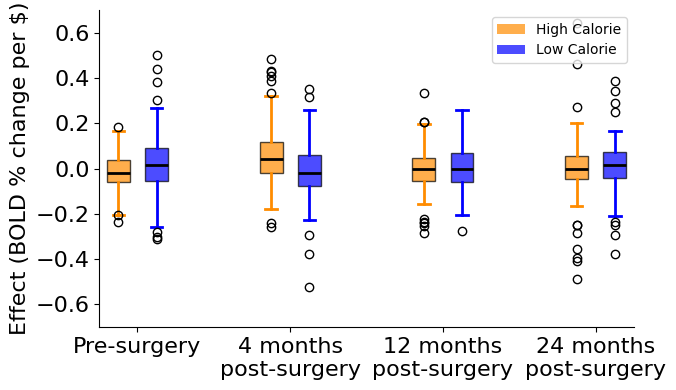

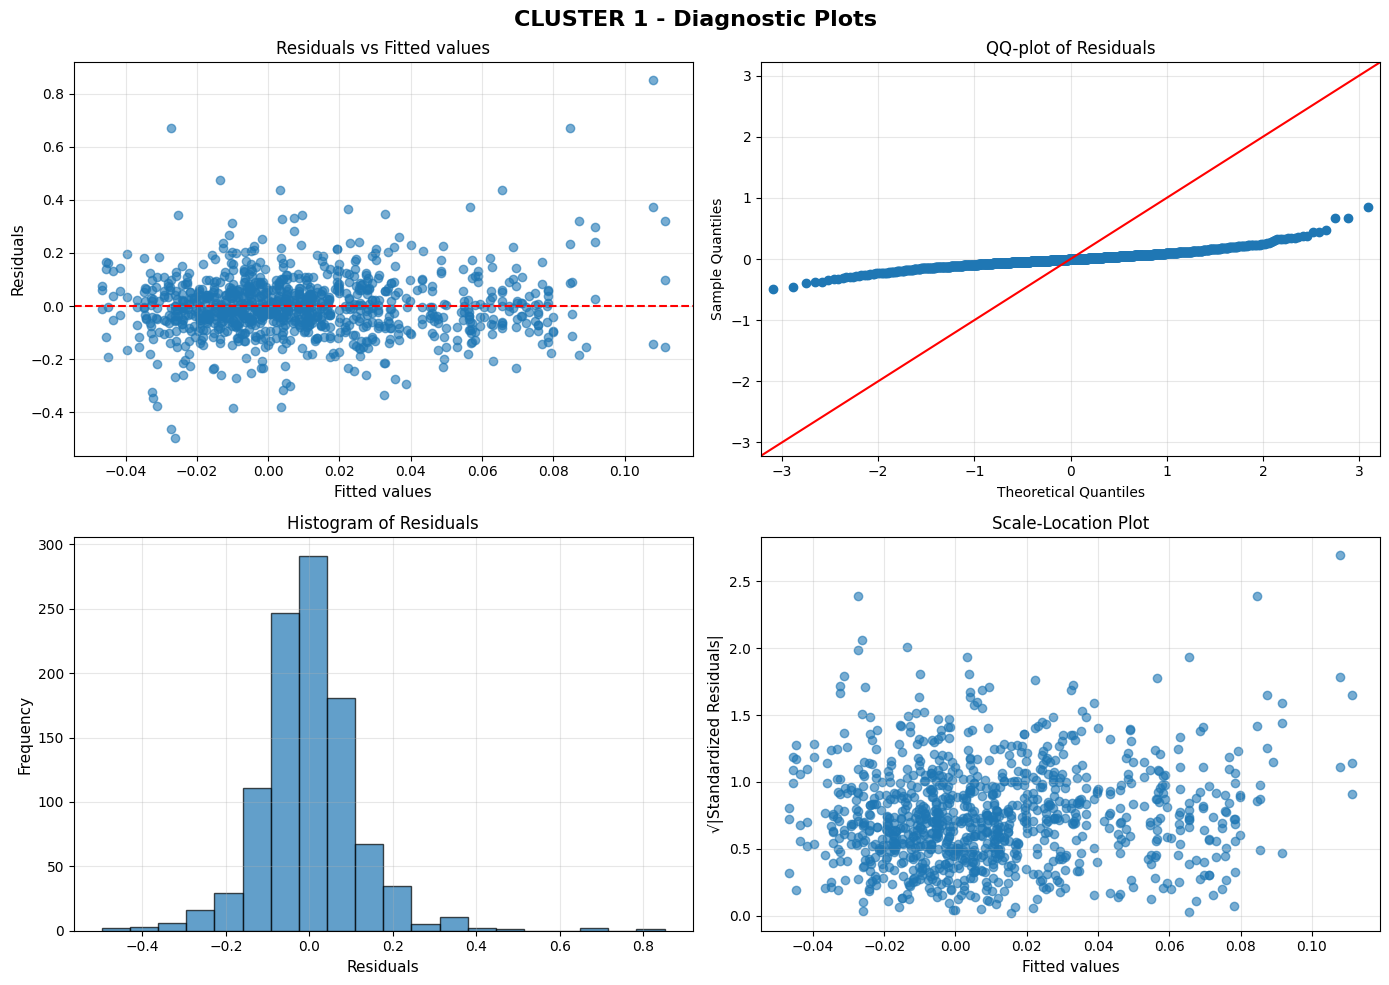


Breusch-Pagan test p-value: 0.000569
Heteroscedasticity detected. The variance of residuals is not constant.

Shapiro-Wilk test p-value: 0.000000
Residuals are not normally distributed.

Variance Inflation Factors:
                     feature           VIF
0                  Intercept 32.0794031770
1                  sess[T.2]  2.8312405225
2                  sess[T.3]  2.7599011089
3                  sess[T.4]  2.7484194846
4             calorie[T.low]  3.4589041096
5                sex[T.male]  1.1186338013
6           C(type_chx)[T.2]  1.4794887327
7           C(type_chx)[T.3]  1.7836835244
8        handedness[T.right]  1.3304906337
9   sess[T.2]:calorie[T.low]  3.3588498576
10  sess[T.3]:calorie[T.low]  3.1423301234
11  sess[T.4]:calorie[T.low]  3.1161670962
12              age_baseline  1.5501709623
13              bmi_baseline  1.3295402886

AIC: -1278.7506
BIC: -1204.9850

Wald test results:
                                  chi2                  P>chi2  df constraint
Intercep

C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Patrick\AppData\Local\Temp\ipykernel_27192\354981984.py:428: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining th

       Parameter    R_squared
0           sess 4.9095978891
1           sess 4.9095978891
2           sess 4.9095978891
3        calorie 4.6210663737
4            sex 4.6032136727
5    C(type_chx) 4.7341628914
6    C(type_chx) 4.7341628914
7     handedness 4.7033718730
8           sess 4.9095978891
9           sess 4.9095978891
10          sess 4.9095978891
11  age_baseline 4.6951908821
12  bmi_baseline 4.3160385163



CLUSTER 2 ANALYSIS

Model formula: mean_beta ~ sess*calorie + sex + age_baseline + bmi_baseline + C(type_chx) + handedness
Data shape: (1010, 21)
Unique subjects: 57



C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not fo

               Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     mean_beta
No. Observations:     1010        Method:                 REML     
No. Groups:           57          Scale:                  0.0139   
Min. group size:      4           Log-Likelihood:         659.0631 
Max. group size:      24          Converged:              Yes      
Mean group size:      17.7                                         
-------------------------------------------------------------------
                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------
Intercept                -0.023    0.029 -0.766 0.444 -0.080  0.035
sess[T.2]                 0.075    0.014  5.325 0.000  0.047  0.102
sess[T.3]                 0.025    0.015  1.654 0.098 -0.005  0.054
sess[T.4]                 0.006    0.015  0.397 0.692 -0.024  0.036
calorie[T.low]            0.020    0.014  1.468 0.142 -0.007  0

findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.


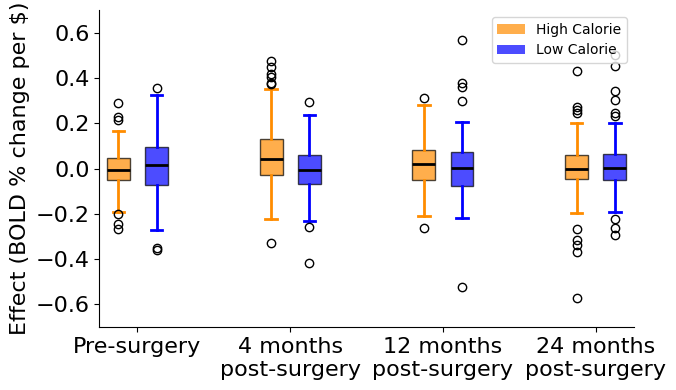

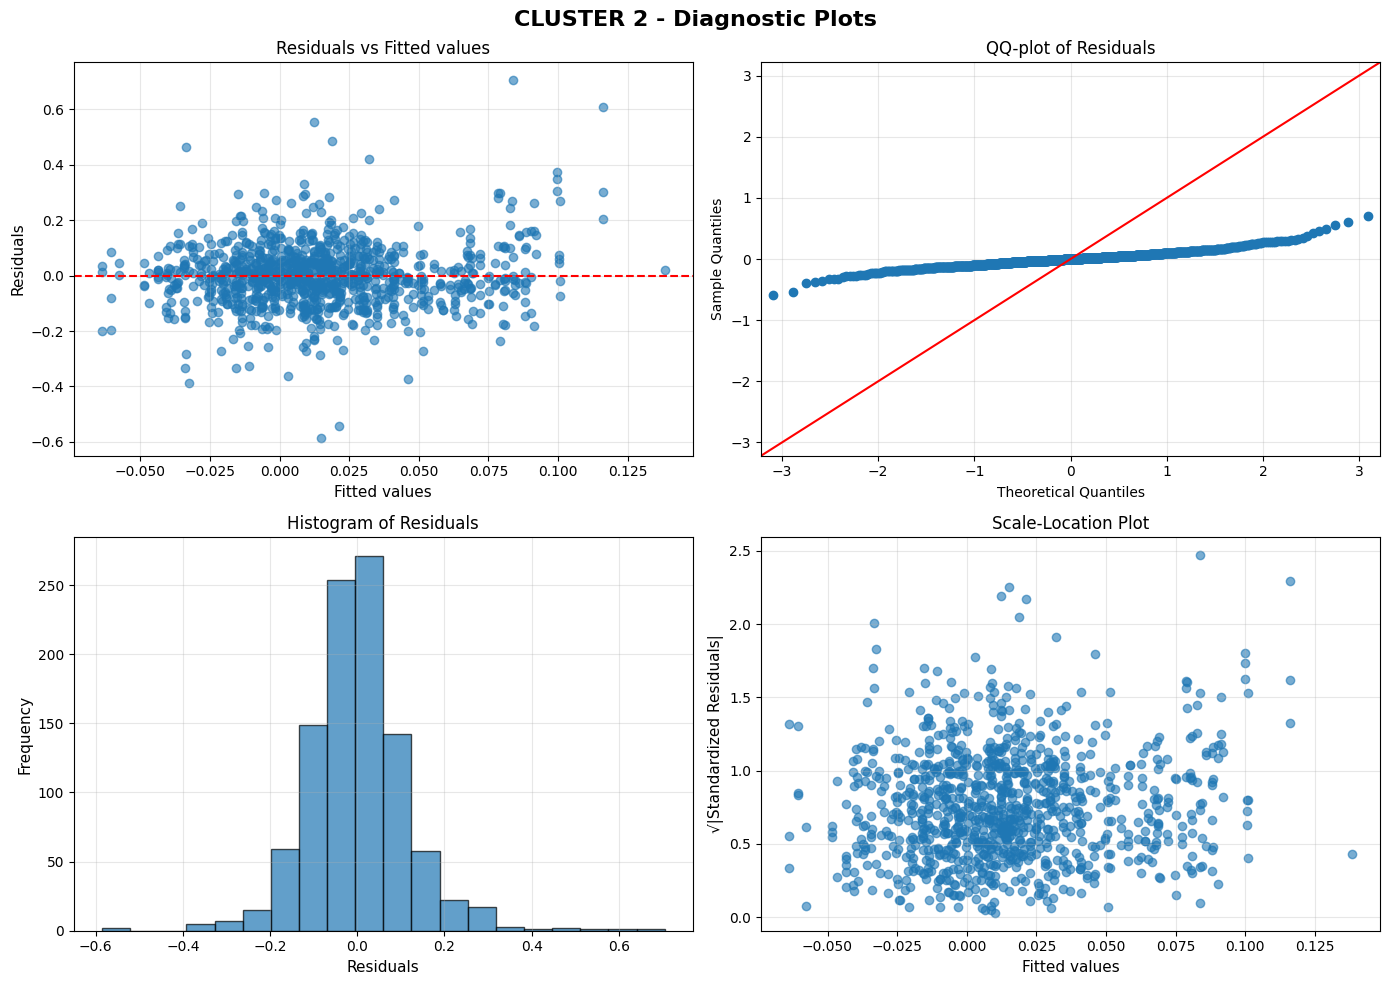


Breusch-Pagan test p-value: 0.002847
Heteroscedasticity detected. The variance of residuals is not constant.

Shapiro-Wilk test p-value: 0.000000
Residuals are not normally distributed.

Variance Inflation Factors:
                     feature           VIF
0                  Intercept 32.0794031770
1                  sess[T.2]  2.8312405225
2                  sess[T.3]  2.7599011089
3                  sess[T.4]  2.7484194846
4             calorie[T.low]  3.4589041096
5                sex[T.male]  1.1186338013
6           C(type_chx)[T.2]  1.4794887327
7           C(type_chx)[T.3]  1.7836835244
8        handedness[T.right]  1.3304906337
9   sess[T.2]:calorie[T.low]  3.3588498576
10  sess[T.3]:calorie[T.low]  3.1423301234
11  sess[T.4]:calorie[T.low]  3.1161670962
12              age_baseline  1.5501709623
13              bmi_baseline  1.3295402886

AIC: -1288.1262
BIC: -1214.3606

Wald test results:
                                  chi2                  P>chi2  df constraint
Intercep

C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Patrick\AppData\Local\Temp\ipykernel_27192\354981984.py:428: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining th

       Parameter    R_squared
0           sess 8.6552737195
1           sess 8.6552737195
2           sess 8.6552737195
3        calorie 7.9729571280
4            sex 7.8550867977
5    C(type_chx) 7.5696140627
6    C(type_chx) 7.5696140627
7     handedness 7.8183991108
8           sess 8.6552737195
9           sess 8.6552737195
10          sess 8.6552737195
11  age_baseline 7.8353596798
12  bmi_baseline 7.7732571163



CLUSTER 3 ANALYSIS

Model formula: mean_beta ~ sess*calorie + sex + age_baseline + bmi_baseline + C(type_chx) + handedness
Data shape: (1010, 21)
Unique subjects: 57



C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not fo

               Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     mean_beta
No. Observations:     1010        Method:                 REML     
No. Groups:           57          Scale:                  0.0390   
Min. group size:      4           Log-Likelihood:         144.5410 
Max. group size:      24          Converged:              Yes      
Mean group size:      17.7                                         
-------------------------------------------------------------------
                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------
Intercept                 0.067    0.050  1.336 0.182 -0.032  0.166
sess[T.2]                -0.098    0.024 -4.143 0.000 -0.144 -0.051
sess[T.3]                -0.065    0.025 -2.614 0.009 -0.115 -0.016
sess[T.4]                -0.083    0.025 -3.307 0.001 -0.133 -0.034
calorie[T.low]           -0.032    0.023 -1.391 0.164 -0.077  0

findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font f

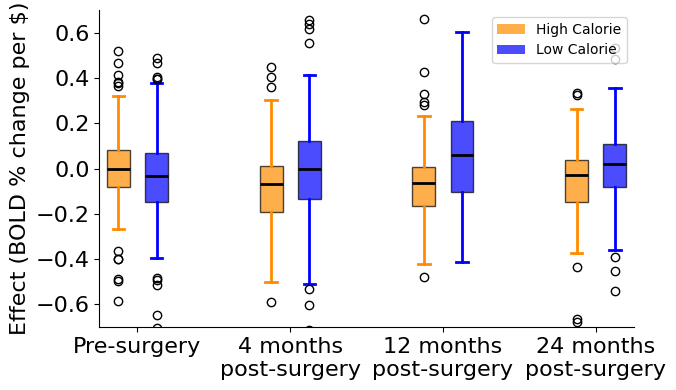

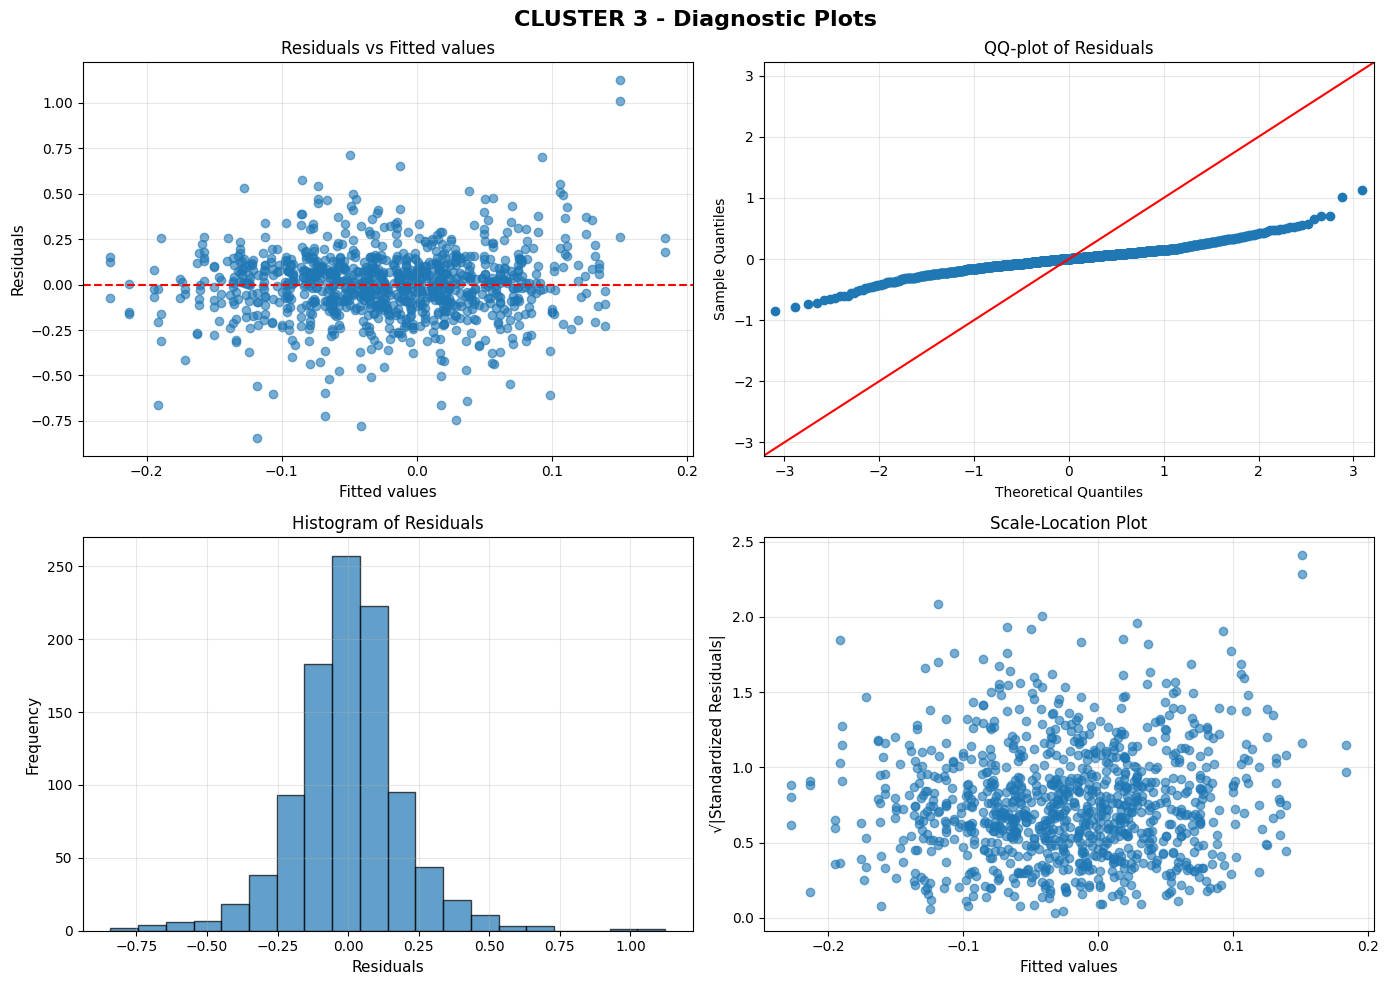


Breusch-Pagan test p-value: 0.029670
Heteroscedasticity detected. The variance of residuals is not constant.

Shapiro-Wilk test p-value: 0.000000
Residuals are not normally distributed.

Variance Inflation Factors:
                     feature           VIF
0                  Intercept 32.0794031770
1                  sess[T.2]  2.8312405225
2                  sess[T.3]  2.7599011089
3                  sess[T.4]  2.7484194846
4             calorie[T.low]  3.4589041096
5                sex[T.male]  1.1186338013
6           C(type_chx)[T.2]  1.4794887327
7           C(type_chx)[T.3]  1.7836835244
8        handedness[T.right]  1.3304906337
9   sess[T.2]:calorie[T.low]  3.3588498576
10  sess[T.3]:calorie[T.low]  3.1423301234
11  sess[T.4]:calorie[T.low]  3.1161670962
12              age_baseline  1.5501709623
13              bmi_baseline  1.3295402886

AIC: -259.0820
BIC: -185.3164

Wald test results:
                                chi2                  P>chi2  df constraint
Intercept   

C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Patrick\AppData\Local\Temp\ipykernel_27192\354981984.py:428: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining th

       Parameter     R_squared
0           sess 11.5780919281
1           sess 11.5780919281
2           sess 11.5780919281
3        calorie 13.4111176690
4            sex 11.0625677094
5    C(type_chx) 11.1196316299
6    C(type_chx) 11.1196316299
7     handedness 11.0452627646
8           sess 11.5780919281
9           sess 11.5780919281
10          sess 11.5780919281
11  age_baseline 10.6975176649
12  bmi_baseline 11.0289319698



CLUSTER 4 ANALYSIS

Model formula: mean_beta ~ sess*calorie + sex + age_baseline + bmi_baseline + C(type_chx) + handedness
Data shape: (1010, 21)
Unique subjects: 57



C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not fo

               Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     mean_beta
No. Observations:     1010        Method:                 REML     
No. Groups:           57          Scale:                  0.0124   
Min. group size:      4           Log-Likelihood:         719.4251 
Max. group size:      24          Converged:              Yes      
Mean group size:      17.7                                         
-------------------------------------------------------------------
                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------
Intercept                -0.016    0.025 -0.631 0.528 -0.066  0.034
sess[T.2]                 0.052    0.013  3.944 0.000  0.026  0.078
sess[T.3]                -0.007    0.014 -0.522 0.602 -0.035  0.020
sess[T.4]                 0.007    0.014  0.476 0.634 -0.021  0.035
calorie[T.low]            0.031    0.013  2.341 0.019  0.005  0

findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.


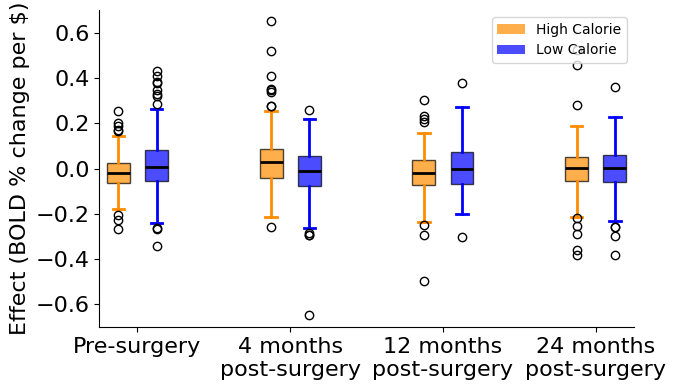

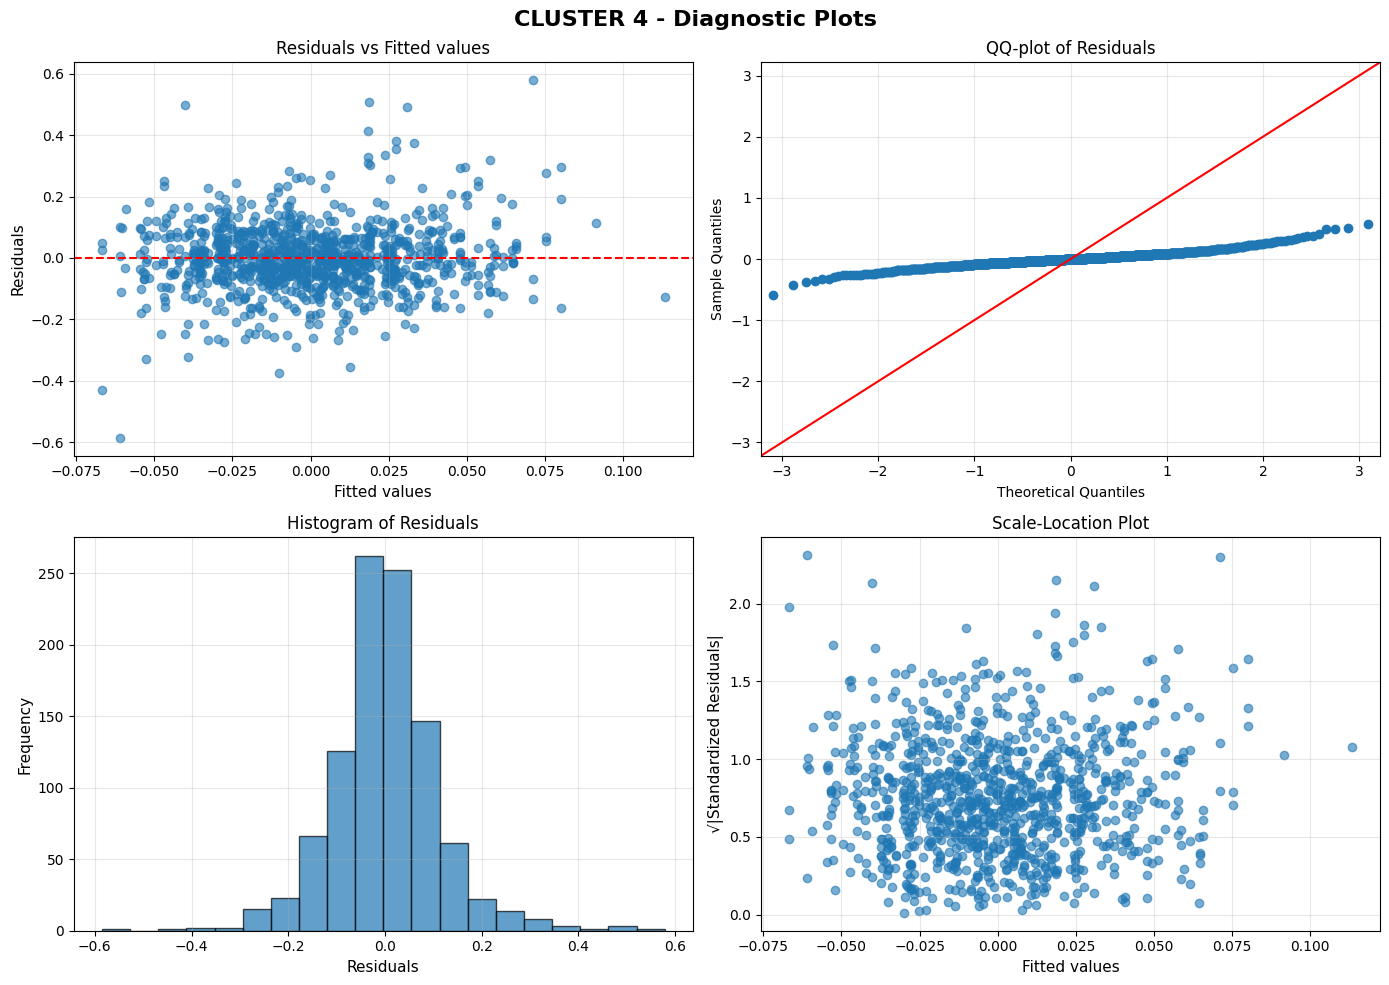


Breusch-Pagan test p-value: 0.002697
Heteroscedasticity detected. The variance of residuals is not constant.

Shapiro-Wilk test p-value: 0.000000
Residuals are not normally distributed.

Variance Inflation Factors:
                     feature           VIF
0                  Intercept 32.0794031770
1                  sess[T.2]  2.8312405225
2                  sess[T.3]  2.7599011089
3                  sess[T.4]  2.7484194846
4             calorie[T.low]  3.4589041096
5                sex[T.male]  1.1186338013
6           C(type_chx)[T.2]  1.4794887327
7           C(type_chx)[T.3]  1.7836835244
8        handedness[T.right]  1.3304906337
9   sess[T.2]:calorie[T.low]  3.3588498576
10  sess[T.3]:calorie[T.low]  3.1423301234
11  sess[T.4]:calorie[T.low]  3.1161670962
12              age_baseline  1.5501709623
13              bmi_baseline  1.3295402886

AIC: -1408.8502
BIC: -1335.0846

Wald test results:
                                 chi2                  P>chi2  df constraint
Intercept

C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Patrick\AppData\Local\Temp\ipykernel_27192\354981984.py:428: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining th

       Parameter    R_squared
0           sess 7.3451335553
1           sess 7.3451335553
2           sess 7.3451335553
3        calorie 7.0071957534
4            sex 6.8552765671
5    C(type_chx) 7.2715992882
6    C(type_chx) 7.2715992882
7     handedness 7.0985331091
8           sess 7.3451335553
9           sess 7.3451335553
10          sess 7.3451335553
11  age_baseline 6.9696817597
12  bmi_baseline 7.1106708892



CLUSTER 5 ANALYSIS

Model formula: mean_beta ~ sess*calorie + sex + age_baseline + bmi_baseline + C(type_chx) + handedness
Data shape: (1010, 21)
Unique subjects: 57



C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not fo

               Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     mean_beta
No. Observations:     1010        Method:                 REML     
No. Groups:           57          Scale:                  0.0221   
Min. group size:      4           Log-Likelihood:         439.0810 
Max. group size:      24          Converged:              Yes      
Mean group size:      17.7                                         
-------------------------------------------------------------------
                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------
Intercept                -0.068    0.030 -2.286 0.022 -0.126 -0.010
sess[T.2]                 0.058    0.018  3.270 0.001  0.023  0.093
sess[T.3]                 0.013    0.019  0.705 0.481 -0.024  0.050
sess[T.4]                 0.016    0.019  0.828 0.407 -0.021  0.053
calorie[T.low]            0.045    0.017  2.608 0.009  0.011  0

findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font f

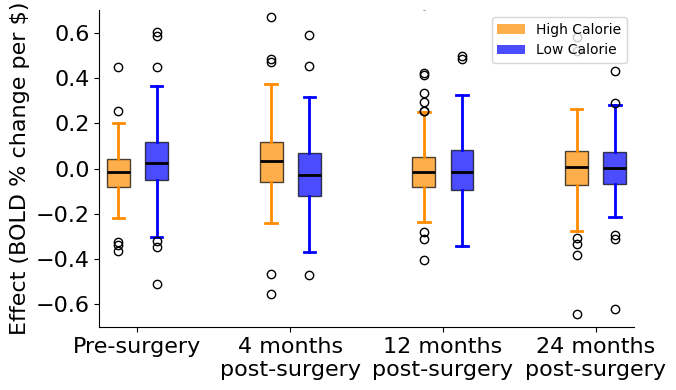

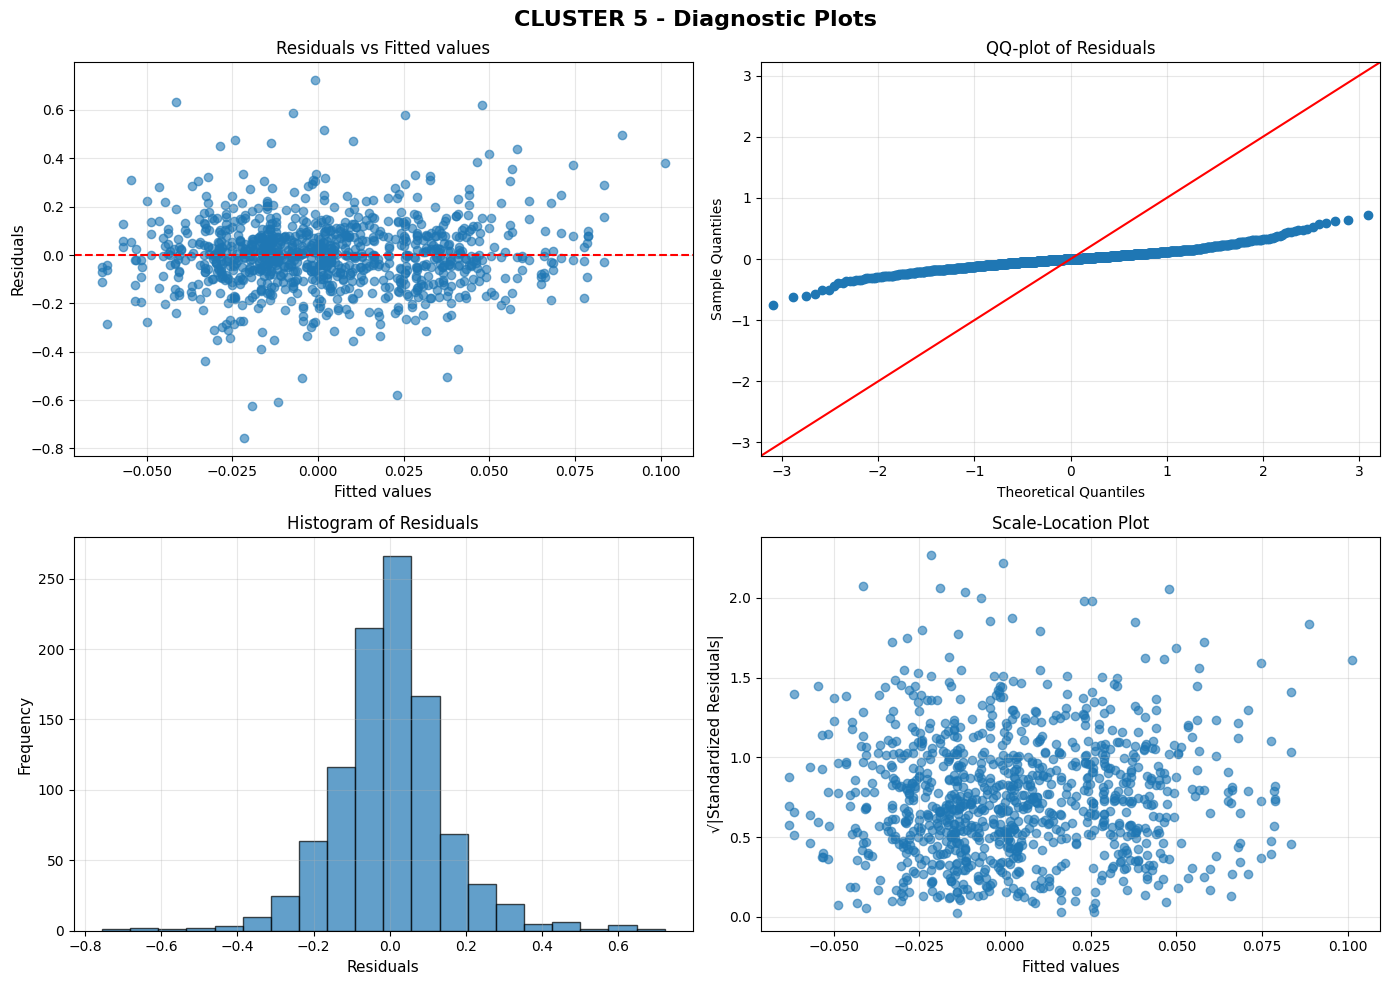


Breusch-Pagan test p-value: 0.003837
Heteroscedasticity detected. The variance of residuals is not constant.

Shapiro-Wilk test p-value: 0.000000
Residuals are not normally distributed.

Variance Inflation Factors:
                     feature           VIF
0                  Intercept 32.0794031770
1                  sess[T.2]  2.8312405225
2                  sess[T.3]  2.7599011089
3                  sess[T.4]  2.7484194846
4             calorie[T.low]  3.4589041096
5                sex[T.male]  1.1186338013
6           C(type_chx)[T.2]  1.4794887327
7           C(type_chx)[T.3]  1.7836835244
8        handedness[T.right]  1.3304906337
9   sess[T.2]:calorie[T.low]  3.3588498576
10  sess[T.3]:calorie[T.low]  3.1423301234
11  sess[T.4]:calorie[T.low]  3.1161670962
12              age_baseline  1.5501709623
13              bmi_baseline  1.3295402886

AIC: -848.1620
BIC: -774.3965

Wald test results:
                                chi2                 P>chi2  df constraint
Intercept    

C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Patrick\AppData\Local\Temp\ipykernel_27192\354981984.py:428: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining th

       Parameter    R_squared
0           sess 3.1124704788
1           sess 3.1124704788
2           sess 3.1124704788
3        calorie 3.0599433746
4            sex 3.0858191487
5    C(type_chx) 3.3548570212
6    C(type_chx) 3.3548570212
7     handedness 3.2400051882
8           sess 3.1124704788
9           sess 3.1124704788
10          sess 3.1124704788
11  age_baseline 3.2098423099
12  bmi_baseline 2.6283612845




C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [13]:
results = run_lmm_analysis(
    df_merged_concat_Hi_Lo, 
    formula='mean_beta ~ sess*calorie + sex + age_baseline + bmi_baseline + C(type_chx) + handedness',
    show_diagnostics=True,
    show_boxplot=True,
    ylim=(-0.7, 0.7),  # Specify y-axis range
    show_xlabel = True
)

Cluster 1:
  Center of Mass (x, y, z): (45.3056, 27.3056, 22.2225)
  Cut coordinate (z): 22.2225
  Mean Effect Size: 0.1160
  Number of voxels: 373


C:\Users\Patrick\AppData\Local\Temp\ipykernel_27192\2801483387.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


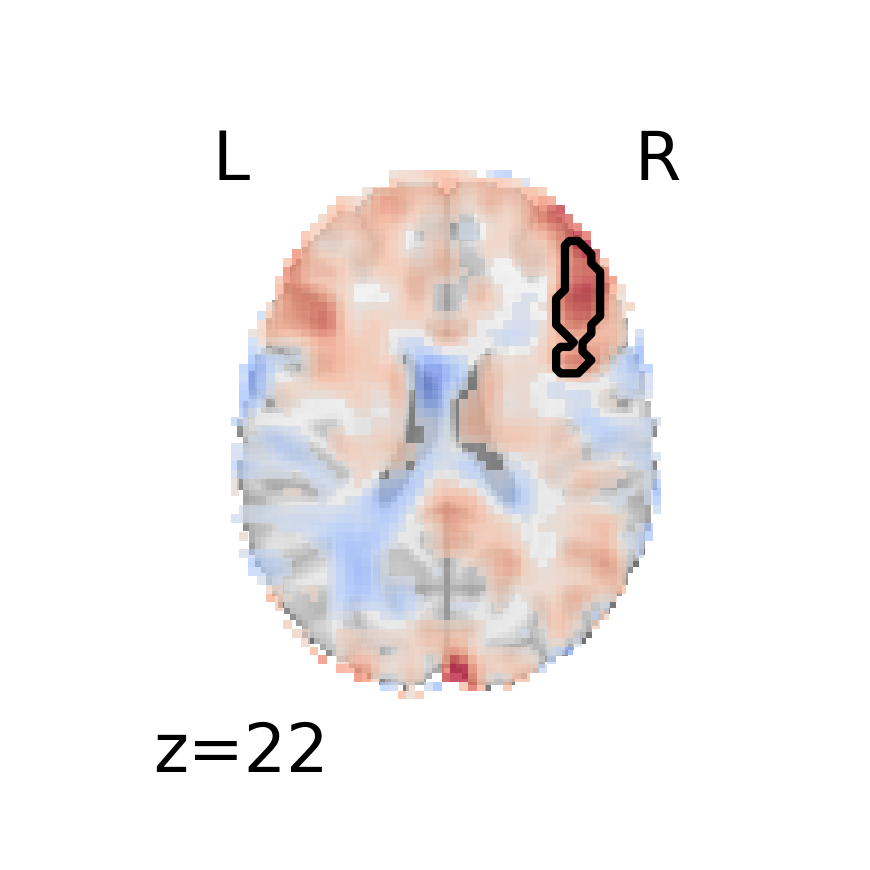

In [14]:
fig = plot_cluster_slice(
    df_merged=df_merged_Lo,
    cluster_id=1,
    effect_map_path='/home/gagpat01/mes_projets/maitrise/fmri/results/3dlmer/effect_maps_mod_hi_vs_mod_lo_v7_literature_complex_psc_qc_final/mod_hi_vs_mod_lo_v7_literature_complex_psc_qc_final_sess2_vs_sess1.nii.gz',
    cluster_map_path='/home/gagpat01/mes_projets/maitrise/fmri/results/3dlmer/results/mod_hi_vs_mod_lo_v7_literature_complex_psc_qc_final/sess2vs1_clustered_p001_ACF_residuals_mod_hi_vs_mod_lo_v7_literature_complex_psc_qc_final.nii.gz',
    vmin=-0.15,
    vmax=0.15,
    display_mode='z',
    figure_width=3,
)

## Cluster 2 parietal cortex


CLUSTER 2 ANALYSIS

Model formula: mean_beta ~ sess*calorie + sex + age_baseline + bmi_baseline + C(type_chx) + handedness
Data shape: (1010, 21)
Unique subjects: 57



C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not fo

               Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     mean_beta
No. Observations:     1010        Method:                 REML     
No. Groups:           57          Scale:                  0.0139   
Min. group size:      4           Log-Likelihood:         659.0631 
Max. group size:      24          Converged:              Yes      
Mean group size:      17.7                                         
-------------------------------------------------------------------
                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------
Intercept                -0.023    0.029 -0.766 0.444 -0.080  0.035
sess[T.2]                 0.075    0.014  5.325 0.000  0.047  0.102
sess[T.3]                 0.025    0.015  1.654 0.098 -0.005  0.054
sess[T.4]                 0.006    0.015  0.397 0.692 -0.024  0.036
calorie[T.low]            0.020    0.014  1.468 0.142 -0.007  0

findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.


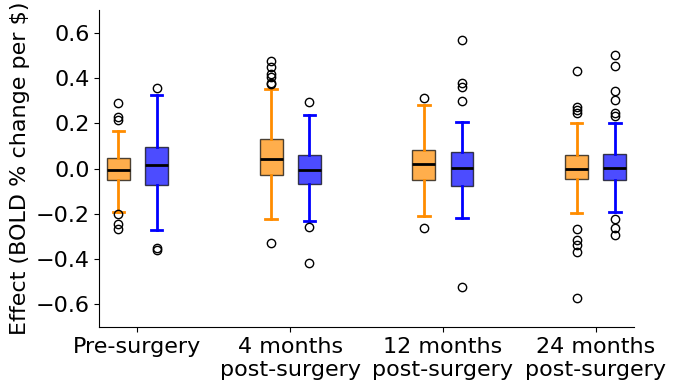

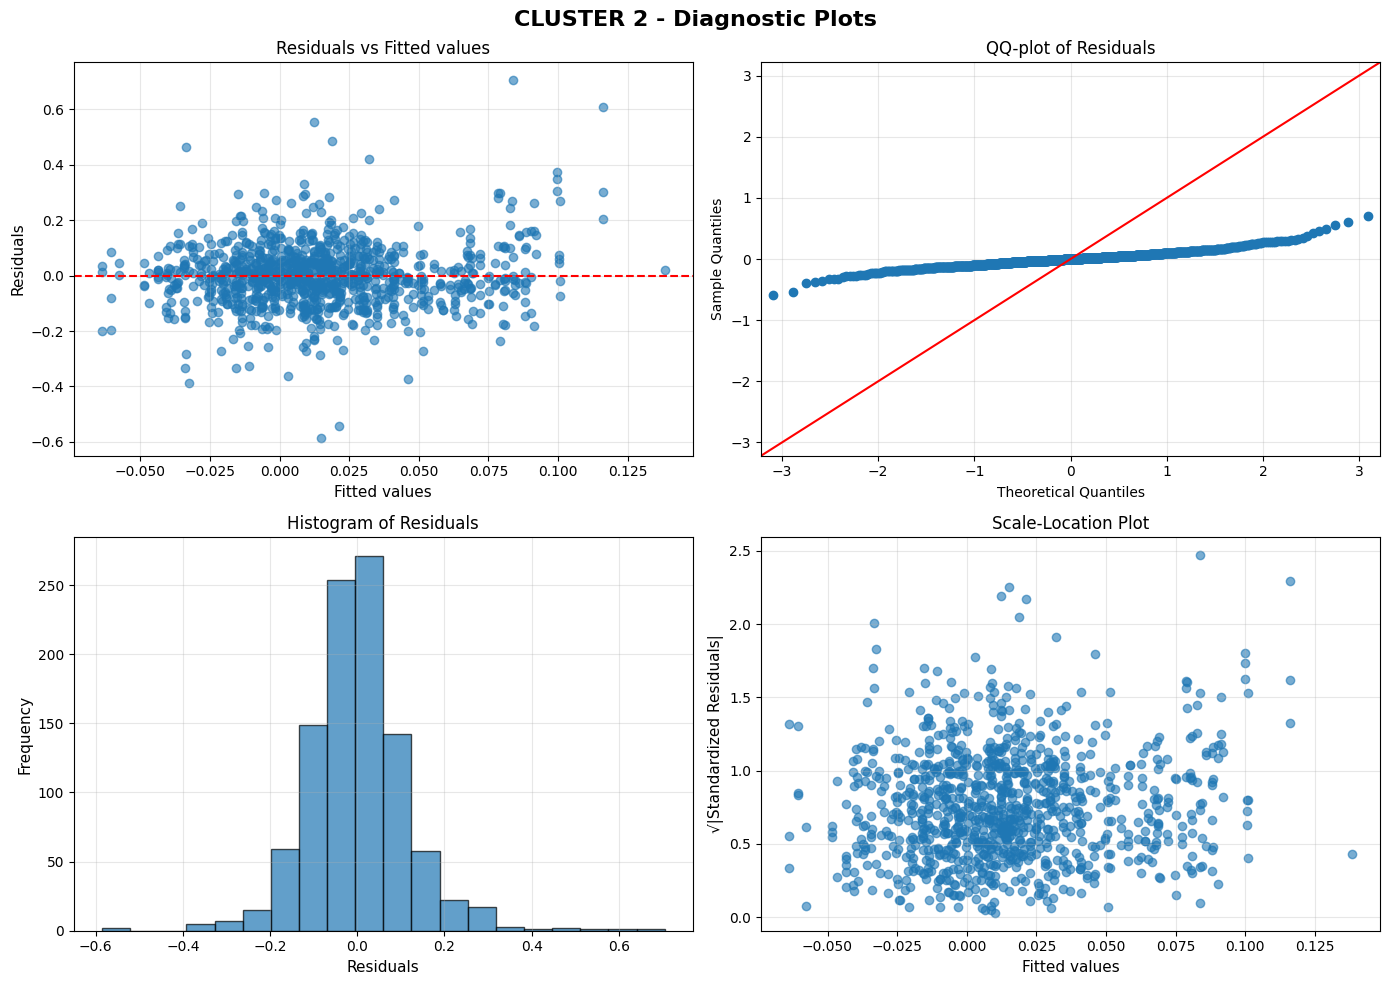


Breusch-Pagan test p-value: 0.002847
Heteroscedasticity detected. The variance of residuals is not constant.

Shapiro-Wilk test p-value: 0.000000
Residuals are not normally distributed.

Variance Inflation Factors:
                     feature           VIF
0                  Intercept 32.0794031770
1                  sess[T.2]  2.8312405225
2                  sess[T.3]  2.7599011089
3                  sess[T.4]  2.7484194846
4             calorie[T.low]  3.4589041096
5                sex[T.male]  1.1186338013
6           C(type_chx)[T.2]  1.4794887327
7           C(type_chx)[T.3]  1.7836835244
8        handedness[T.right]  1.3304906337
9   sess[T.2]:calorie[T.low]  3.3588498576
10  sess[T.3]:calorie[T.low]  3.1423301234
11  sess[T.4]:calorie[T.low]  3.1161670962
12              age_baseline  1.5501709623
13              bmi_baseline  1.3295402886

AIC: -1288.1262
BIC: -1214.3606

Wald test results:
                                  chi2                  P>chi2  df constraint
Intercep

C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Patrick\AppData\Local\Temp\ipykernel_27192\354981984.py:428: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining th

       Parameter    R_squared
0           sess 8.6552737195
1           sess 8.6552737195
2           sess 8.6552737195
3        calorie 7.9729571280
4            sex 7.8550867977
5    C(type_chx) 7.5696140627
6    C(type_chx) 7.5696140627
7     handedness 7.8183991108
8           sess 8.6552737195
9           sess 8.6552737195
10          sess 8.6552737195
11  age_baseline 7.8353596798
12  bmi_baseline 7.7732571163




C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [15]:
results = run_lmm_analysis(
    df_merged_concat_Hi_Lo, 
    formula='mean_beta ~ sess*calorie + sex + age_baseline + bmi_baseline + C(type_chx) + handedness',
    show_diagnostics=True,
    show_boxplot=True,
    ylim=(-0.7, 0.7), # Specify y-axis range
    cluster_id = 2, 
    show_legend = False
)

Cluster 2:
  Center of Mass (x, y, z): (42.7947, -59.245, 41.9603)
  Cut coordinate (z): 41.9603
  Mean Effect Size: 0.0899
  Number of voxels: 151


C:\Users\Patrick\AppData\Local\Temp\ipykernel_27192\2801483387.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


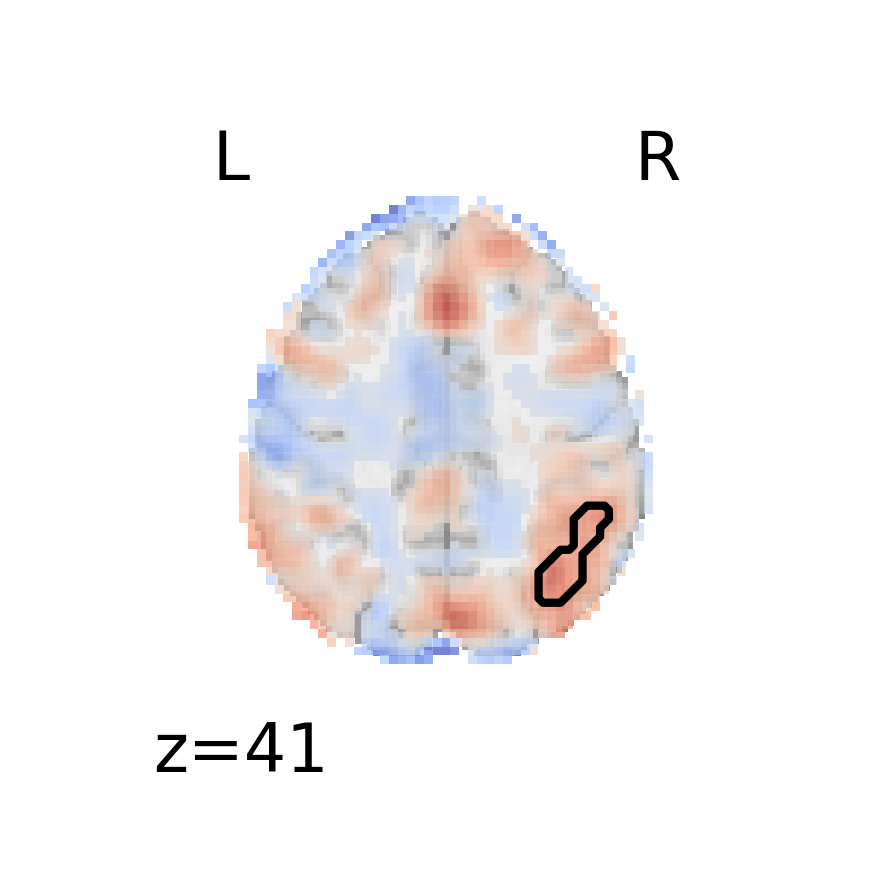

In [16]:
fig = plot_cluster_slice(
    df_merged=df_merged_Lo,
    cluster_id=2,
    effect_map_path='/home/gagpat01/mes_projets/maitrise/fmri/results/3dlmer/effect_maps_mod_hi_vs_mod_lo_v7_literature_complex_psc_qc_final/mod_hi_vs_mod_lo_v7_literature_complex_psc_qc_final_sess2_vs_sess1.nii.gz',
    cluster_map_path='/home/gagpat01/mes_projets/maitrise/fmri/results/3dlmer/results/mod_hi_vs_mod_lo_v7_literature_complex_psc_qc_final/sess2vs1_clustered_p001_ACF_residuals_mod_hi_vs_mod_lo_v7_literature_complex_psc_qc_final.nii.gz',
    vmin=-0.15,
    vmax=0.15,
    display_mode='z',
    figure_width=3,
)

## yeo with first level

In [18]:
#Example usage:
df_merged_Hi_v_Lo_Yeo, df_beta_Hi_v_Lo_Yeo = load_and_merge_beta_lmer_data(
    beta_file_path='/home/gagpat01/mes_projets/maitrise/fmri/results/beta_estimates_yeo7-7networks_20260409_145148.tsv',
    lmer_file_path='/home/gagpat01/mes_projets/maitrise/fmri/results/3dlmerdata_table_with_covariates_mod_hi_vs_mod_lo_v7_literature_complex_psc_qc_final.txt',
    exclude_participants=['RGC']
)


Loading beta data from: /home/gagpat01/mes_projets/maitrise/fmri/results/beta_estimates_yeo7-7networks_20260409_145148.tsv
Loaded 6243 rows

Session dtype: object
Session unique values: ['ses-2' 'ses-3' 'ses-4' 'ses-1']
Removed session 'ses-01': 0 rows removed
Excluded participants containing 'RGC': 777 rows removed

Loading LMER data from: /home/gagpat01/mes_projets/maitrise/fmri/results/3dlmerdata_table_with_covariates_mod_hi_vs_mod_lo_v7_literature_complex_psc_qc_final.txt
Loaded 507 rows

Unique subjects in beta data: 78
Unique subjects in LMER data: 57

Merged dataframe rows: 3535
Unique subjects in merged df: 57

Mean Beta by Network and Session:
                    mean_beta                   
                         mean          std count
network_id sess                                 
1          1    -0.0095840000 0.1509530000   146
           2     0.0209970000 0.1734360000   138
           3    -0.0124010000 0.1612090000   112
           4    -0.0358610000 0.1694800000   


NETWORK 1 ANALYSIS

Model formula: mean_beta ~ sess + sex + age_baseline + bmi_baseline + C(type_chx) + handedness
Data shape: (505, 21)
Unique subjects: 57



C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not fo

            Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   mean_beta
No. Observations:    505       Method:               REML     
No. Groups:          57        Scale:                0.0258   
Min. group size:     2         Log-Likelihood:       166.5972 
Max. group size:     12        Converged:            Yes      
Mean group size:     8.9                                      
--------------------------------------------------------------
                    Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept            0.023    0.046  0.501 0.616 -0.067  0.114
sess[T.2]            0.030    0.019  1.578 0.114 -0.007  0.068
sess[T.3]           -0.004    0.020 -0.196 0.845 -0.044  0.036
sess[T.4]           -0.028    0.021 -1.373 0.170 -0.069  0.012
sex[T.male]          0.001    0.022  0.030 0.976 -0.042  0.043
C(type_chx)[T.2]    -0.021    0.024 -0.872 0.383 -0.069  0.027
C(typ

findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.


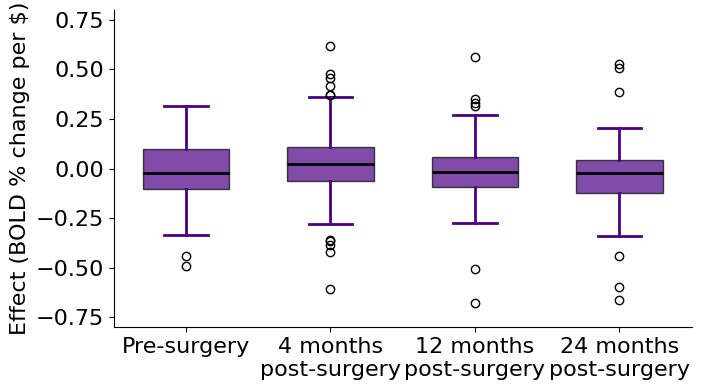

C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(



Breusch-Pagan test p-value: 0.543522
No heteroscedasticity detected. The variance of residuals is constant.

Shapiro-Wilk test p-value: 0.000000
Residuals are not normally distributed.

Variance Inflation Factors:
               feature           VIF
0            Intercept 28.6204990674
1            sess[T.2]  1.4175961444
2            sess[T.3]  1.3846942731
3            sess[T.4]  1.3788277309
4          sex[T.male]  1.1186338013
5     C(type_chx)[T.2]  1.4794887327
6     C(type_chx)[T.3]  1.7836835244
7  handedness[T.right]  1.3304906337
8         age_baseline  1.5501709623
9         bmi_baseline  1.3295402886

AIC: -311.1944
BIC: -264.7243

Wald test results:
                                   chi2                P>chi2  df constraint
Intercept       [[0.25136260349105494]]    0.6161172565374669              1
sess               [[8.12739304971185]]  0.043450953732877516              3
sex           [[0.0008806803508149628]]     0.976325246119584              1
C(type_chx)      [[

C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Patrick\AppData\Local\Temp\ipykernel_27192\354981984.py:428: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  r_squared_data = pd.concat([r_squared_data,
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn

      Parameter    R_squared
0          sess 7.6103137153
1          sess 7.6103137153
2          sess 7.6103137153
3           sex 6.3468030591
4   C(type_chx) 6.5188415851
5   C(type_chx) 6.5188415851
6    handedness 6.4048629928
7  age_baseline 6.3608073900
8  bmi_baseline 6.3315474900



NETWORK 2 ANALYSIS

Model formula: mean_beta ~ sess + sex + age_baseline + bmi_baseline + C(type_chx) + handedness
Data shape: (505, 21)
Unique subjects: 57



C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not fo

            Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   mean_beta
No. Observations:    505       Method:               REML     
No. Groups:          57        Scale:                0.0207   
Min. group size:     2         Log-Likelihood:       230.3499 
Max. group size:     12        Converged:            Yes      
Mean group size:     8.9                                      
--------------------------------------------------------------
                    Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept            0.072    0.034  2.105 0.035  0.005  0.139
sess[T.2]           -0.011    0.017 -0.648 0.517 -0.045  0.022
sess[T.3]           -0.027    0.018 -1.465 0.143 -0.062  0.009
sess[T.4]           -0.038    0.018 -2.070 0.038 -0.074 -0.002
sex[T.male]         -0.011    0.016 -0.715 0.475 -0.042  0.020
C(type_chx)[T.2]    -0.013    0.018 -0.722 0.471 -0.049  0.023
C(typ

findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font f

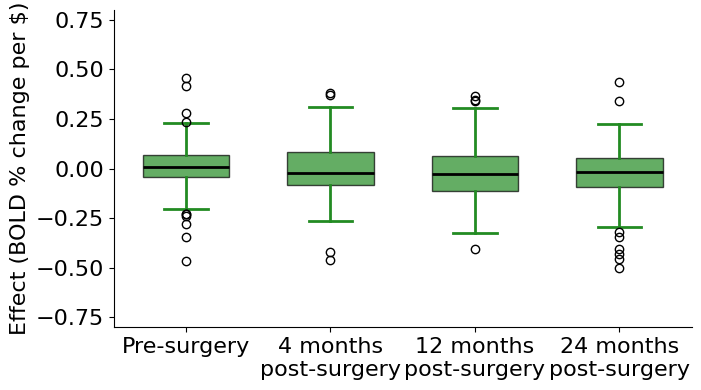

C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(



Breusch-Pagan test p-value: 0.001327
Heteroscedasticity detected. The variance of residuals is not constant.

Shapiro-Wilk test p-value: 0.000000
Residuals are not normally distributed.

Variance Inflation Factors:
               feature           VIF
0            Intercept 28.6204990674
1            sess[T.2]  1.4175961444
2            sess[T.3]  1.3846942731
3            sess[T.4]  1.3788277309
4          sex[T.male]  1.1186338013
5     C(type_chx)[T.2]  1.4794887327
6     C(type_chx)[T.3]  1.7836835244
7  handedness[T.right]  1.3304906337
8         age_baseline  1.5501709623
9         bmi_baseline  1.3295402886

AIC: -438.6998
BIC: -392.2296

Wald test results:
                                  chi2               P>chi2  df constraint
Intercept        [[4.429965696229534]]  0.03531321767014279              1
sess             [[5.007077161184718]]  0.17127965269232806              3
sex             [[0.5107768246354951]]  0.47480276788516773              1
C(type_chx)     [[2.654245

C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Patrick\AppData\Local\Temp\ipykernel_27192\354981984.py:428: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  r_squared_data = pd.concat([r_squared_data,
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn

      Parameter    R_squared
0          sess 3.1270302299
1          sess 3.1270302299
2          sess 3.1270302299
3           sex 2.3956646483
4   C(type_chx) 1.1241409962
5   C(type_chx) 1.1241409962
6    handedness 1.6194827971
7  age_baseline 2.3338339222
8  bmi_baseline 1.8756980786



NETWORK 3 ANALYSIS

Model formula: mean_beta ~ sess + sex + age_baseline + bmi_baseline + C(type_chx) + handedness
Data shape: (505, 21)
Unique subjects: 57



C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not fo

            Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   mean_beta
No. Observations:    505       Method:               REML     
No. Groups:          57        Scale:                0.0147   
Min. group size:     2         Log-Likelihood:       307.0890 
Max. group size:     12        Converged:            Yes      
Mean group size:     8.9                                      
--------------------------------------------------------------
                    Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept            0.052    0.034  1.534 0.125 -0.014  0.118
sess[T.2]            0.021    0.014  1.437 0.151 -0.008  0.049
sess[T.3]           -0.012    0.015 -0.780 0.436 -0.042  0.018
sess[T.4]           -0.034    0.016 -2.187 0.029 -0.064 -0.004
sex[T.male]         -0.009    0.016 -0.588 0.557 -0.040  0.022
C(type_chx)[T.2]    -0.023    0.018 -1.273 0.203 -0.058  0.012
C(typ

findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.


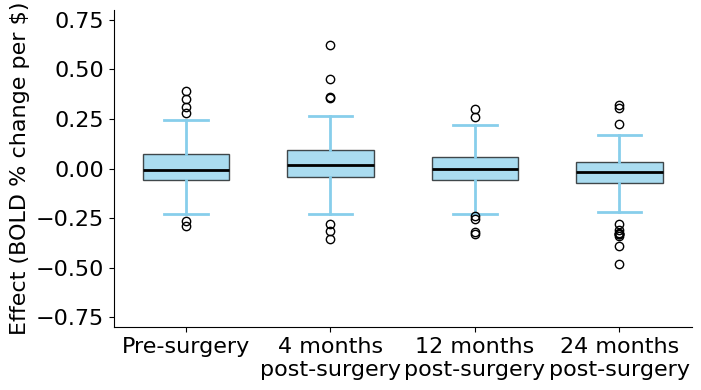

C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(



Breusch-Pagan test p-value: 0.082176
No heteroscedasticity detected. The variance of residuals is constant.

Shapiro-Wilk test p-value: 0.000000
Residuals are not normally distributed.

Variance Inflation Factors:
               feature           VIF
0            Intercept 28.6204990674
1            sess[T.2]  1.4175961444
2            sess[T.3]  1.3846942731
3            sess[T.4]  1.3788277309
4          sex[T.male]  1.1186338013
5     C(type_chx)[T.2]  1.4794887327
6     C(type_chx)[T.3]  1.7836835244
7  handedness[T.right]  1.3304906337
8         age_baseline  1.5501709623
9         bmi_baseline  1.3295402886

AIC: -592.1780
BIC: -545.7079

Wald test results:
                                   chi2                P>chi2  df constraint
Intercept        [[2.3521036830298447]]   0.12511406644991283              1
sess             [[12.775058314020125]]  0.005149189887137316              3
sex              [[0.3457569501290685]]    0.5565249014705025              1
C(type_chx)      [[

C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Patrick\AppData\Local\Temp\ipykernel_27192\354981984.py:428: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  r_squared_data = pd.concat([r_squared_data,
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn

      Parameter    R_squared
0          sess 7.3729885801
1          sess 7.3729885801
2          sess 7.3729885801
3           sex 5.2300788355
4   C(type_chx) 5.4870502169
5   C(type_chx) 5.4870502169
6    handedness 5.1769175432
7  age_baseline 5.2364723542
8  bmi_baseline 5.3047859804



NETWORK 4 ANALYSIS

Model formula: mean_beta ~ sess + sex + age_baseline + bmi_baseline + C(type_chx) + handedness
Data shape: (505, 21)
Unique subjects: 57



C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not fo

            Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   mean_beta
No. Observations:    505       Method:               REML     
No. Groups:          57        Scale:                0.0161   
Min. group size:     2         Log-Likelihood:       290.6066 
Max. group size:     12        Converged:            Yes      
Mean group size:     8.9                                      
--------------------------------------------------------------
                    Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept            0.060    0.031  1.920 0.055 -0.001  0.121
sess[T.2]            0.000    0.015  0.027 0.978 -0.029  0.030
sess[T.3]           -0.019    0.016 -1.203 0.229 -0.051  0.012
sess[T.4]           -0.021    0.016 -1.281 0.200 -0.052  0.011
sex[T.male]         -0.011    0.015 -0.772 0.440 -0.040  0.017
C(type_chx)[T.2]    -0.003    0.017 -0.193 0.847 -0.036  0.029
C(typ

findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font f

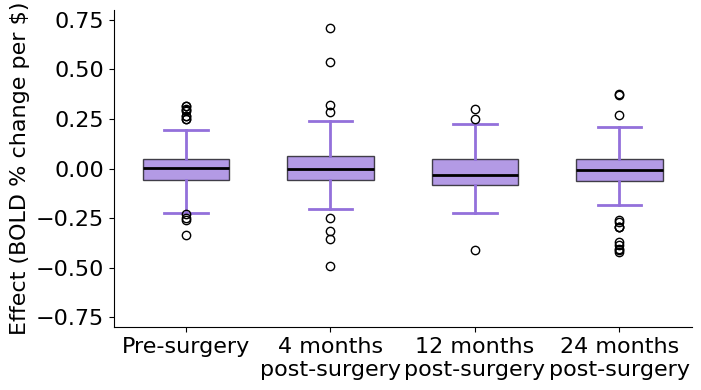

C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(



Breusch-Pagan test p-value: 0.031163
Heteroscedasticity detected. The variance of residuals is not constant.

Shapiro-Wilk test p-value: 0.000000
Residuals are not normally distributed.

Variance Inflation Factors:
               feature           VIF
0            Intercept 28.6204990674
1            sess[T.2]  1.4175961444
2            sess[T.3]  1.3846942731
3            sess[T.4]  1.3788277309
4          sex[T.male]  1.1186338013
5     C(type_chx)[T.2]  1.4794887327
6     C(type_chx)[T.3]  1.7836835244
7  handedness[T.right]  1.3304906337
8         age_baseline  1.5501709623
9         bmi_baseline  1.3295402886

AIC: -559.2131
BIC: -512.7430

Wald test results:
                                 chi2               P>chi2  df constraint
Intercept      [[3.6870307108100304]]  0.05483715693760355              1
sess           [[3.1147024263960015]]  0.37427618739902013              3
sex            [[0.5953455766768532]]   0.4403594302175936              1
C(type_chx)    [[1.07508262927

C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Patrick\AppData\Local\Temp\ipykernel_27192\354981984.py:428: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  r_squared_data = pd.concat([r_squared_data,
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn

      Parameter    R_squared
0          sess 3.8374511472
1          sess 3.8374511472
2          sess 3.8374511472
3           sex 3.6118119491
4   C(type_chx) 2.5966059697
5   C(type_chx) 2.5966059697
6    handedness 2.7845275093
7  age_baseline 3.5669184497
8  bmi_baseline 3.5286775843



NETWORK 5 ANALYSIS

Model formula: mean_beta ~ sess + sex + age_baseline + bmi_baseline + C(type_chx) + handedness
Data shape: (505, 21)
Unique subjects: 57



C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.


            Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   mean_beta
No. Observations:    505       Method:               REML     
No. Groups:          57        Scale:                0.0894   
Min. group size:     2         Log-Likelihood:       -132.2406
Max. group size:     12        Converged:            Yes      
Mean group size:     8.9                                      
--------------------------------------------------------------
                    Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept           -0.011    0.071 -0.160 0.873 -0.151  0.128
sess[T.2]           -0.019    0.036 -0.529 0.597 -0.089  0.051
sess[T.3]           -0.034    0.038 -0.907 0.364 -0.108  0.040
sess[T.4]           -0.029    0.038 -0.751 0.453 -0.103  0.046
sex[T.male]         -0.055    0.033 -1.654 0.098 -0.119  0.010
C(type_chx)[T.2]    -0.068    0.038 -1.784 0.074 -0.143  0.007
C(typ

findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font f

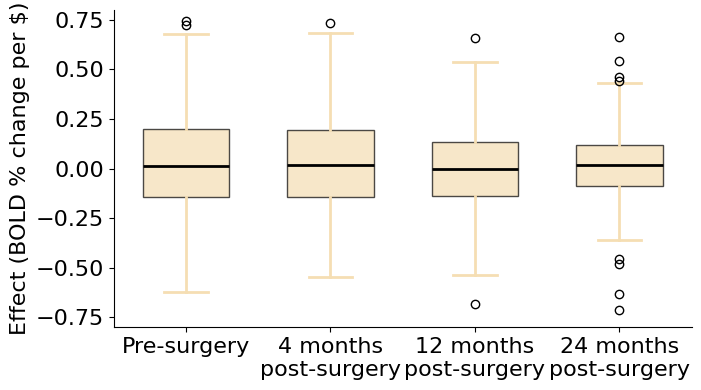


Breusch-Pagan test p-value: 0.000454
Heteroscedasticity detected. The variance of residuals is not constant.

Shapiro-Wilk test p-value: 0.000000
Residuals are not normally distributed.

Variance Inflation Factors:
               feature           VIF
0            Intercept 28.6204990674
1            sess[T.2]  1.4175961444
2            sess[T.3]  1.3846942731
3            sess[T.4]  1.3788277309
4          sex[T.male]  1.1186338013
5     C(type_chx)[T.2]  1.4794887327
6     C(type_chx)[T.3]  1.7836835244
7  handedness[T.right]  1.3304906337
8         age_baseline  1.5501709623
9         bmi_baseline  1.3295402886

AIC: 286.4812
BIC: 332.9513

Wald test results:
                                  chi2               P>chi2  df constraint
Intercept     [[0.025750637348466214]]   0.8725108115222495              1
sess            [[0.9800823545265069]]   0.8060712830767627              3
sex             [[2.7361334898116185]]  0.09810187345304998              1
C(type_chx)      [[6.6654089

C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Patrick\AppData\Local\Temp\ipykernel_27192\354981984.py:428: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining th

      Parameter    R_squared
0          sess 4.1104487047
1          sess 4.1104487047
2          sess 4.1104487047
3           sex 4.0316873969
4   C(type_chx) 3.5424027512
5   C(type_chx) 3.5424027512
6    handedness 2.9190293399
7  age_baseline 4.2236952089
8  bmi_baseline 4.3058986011



NETWORK 6 ANALYSIS

Model formula: mean_beta ~ sess + sex + age_baseline + bmi_baseline + C(type_chx) + handedness
Data shape: (505, 21)
Unique subjects: 57



C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not fo

            Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   mean_beta
No. Observations:    505       Method:               REML     
No. Groups:          57        Scale:                0.0156   
Min. group size:     2         Log-Likelihood:       290.9866 
Max. group size:     12        Converged:            Yes      
Mean group size:     8.9                                      
--------------------------------------------------------------
                    Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept            0.047    0.035  1.345 0.179 -0.022  0.117
sess[T.2]            0.055    0.015  3.675 0.000  0.026  0.084
sess[T.3]           -0.004    0.016 -0.246 0.806 -0.035  0.027
sess[T.4]            0.002    0.016  0.105 0.917 -0.030  0.033
sex[T.male]         -0.018    0.016 -1.081 0.280 -0.050  0.014
C(type_chx)[T.2]    -0.029    0.019 -1.533 0.125 -0.065  0.008
C(typ

findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font f

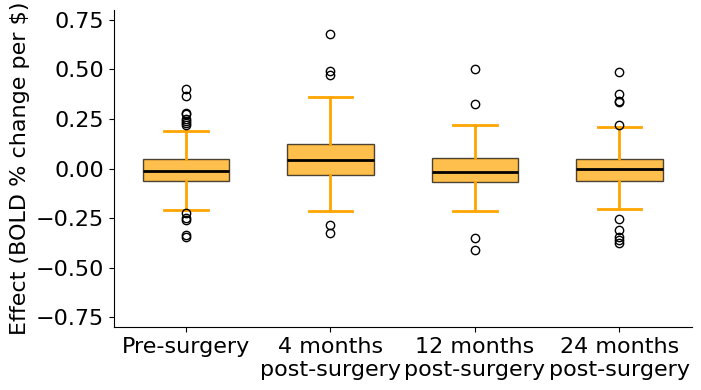

C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(



Breusch-Pagan test p-value: 0.123516
No heteroscedasticity detected. The variance of residuals is constant.

Shapiro-Wilk test p-value: 0.000000
Residuals are not normally distributed.

Variance Inflation Factors:
               feature           VIF
0            Intercept 28.6204990674
1            sess[T.2]  1.4175961444
2            sess[T.3]  1.3846942731
3            sess[T.4]  1.3788277309
4          sex[T.male]  1.1186338013
5     C(type_chx)[T.2]  1.4794887327
6     C(type_chx)[T.3]  1.7836835244
7  handedness[T.right]  1.3304906337
8         age_baseline  1.5501709623
9         bmi_baseline  1.3295402886

AIC: -559.9732
BIC: -513.5030

Wald test results:
                                 chi2                  P>chi2  df constraint
Intercept      [[1.8089002584783913]]     0.17864021054213614              1
sess           [[19.617195612486004]]  0.00020374609166627137              3
sex            [[1.1680074104190665]]     0.27981104256796885              1
C(type_chx)     [[5

C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Patrick\AppData\Local\Temp\ipykernel_27192\354981984.py:428: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  r_squared_data = pd.concat([r_squared_data,
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn

      Parameter     R_squared
0          sess 11.2986074172
1          sess 11.2986074172
2          sess 11.2986074172
3           sex  7.7888394885
4   C(type_chx)  7.1911973824
5   C(type_chx)  7.1911973824
6    handedness  7.8580160751
7  age_baseline  7.7812839809
8  bmi_baseline  7.8638419236



NETWORK 7 ANALYSIS

Model formula: mean_beta ~ sess + sex + age_baseline + bmi_baseline + C(type_chx) + handedness
Data shape: (505, 21)
Unique subjects: 57



C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not fo

            Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   mean_beta
No. Observations:    505       Method:               REML     
No. Groups:          57        Scale:                0.0139   
Min. group size:     2         Log-Likelihood:       322.0678 
Max. group size:     12        Converged:            Yes      
Mean group size:     8.9                                      
--------------------------------------------------------------
                    Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept           -0.025    0.032 -0.772 0.440 -0.087  0.038
sess[T.2]            0.017    0.014  1.233 0.218 -0.010  0.045
sess[T.3]           -0.007    0.015 -0.451 0.652 -0.036  0.023
sess[T.4]           -0.010    0.015 -0.661 0.508 -0.040  0.020
sex[T.male]         -0.015    0.015 -1.037 0.300 -0.045  0.014
C(type_chx)[T.2]    -0.022    0.017 -1.271 0.204 -0.055  0.012
C(typ

findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.
findfont: Font family 'Aptos' not found.


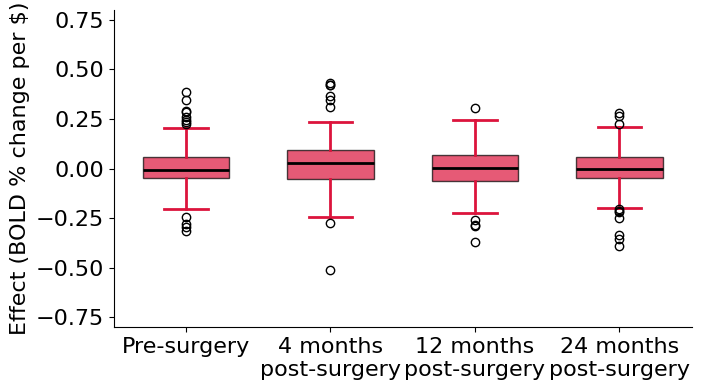

C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(



Breusch-Pagan test p-value: 0.011589
Heteroscedasticity detected. The variance of residuals is not constant.

Shapiro-Wilk test p-value: 0.000002
Residuals are not normally distributed.

Variance Inflation Factors:
               feature           VIF
0            Intercept 28.6204990674
1            sess[T.2]  1.4175961444
2            sess[T.3]  1.3846942731
3            sess[T.4]  1.3788277309
4          sex[T.male]  1.1186338013
5     C(type_chx)[T.2]  1.4794887327
6     C(type_chx)[T.3]  1.7836835244
7  handedness[T.right]  1.3304906337
8         age_baseline  1.5501709623
9         bmi_baseline  1.3295402886

AIC: -622.1355
BIC: -575.6654

Wald test results:
                                chi2               P>chi2  df constraint
Intercept     [[0.5961830531823692]]   0.4400380812431084              1
sess          [[4.0218750272736035]]   0.2591116899612758              3
sex           [[1.0752594484202653]]  0.29976047553940055              1
C(type_chx)    [[6.422081799705245

C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Patrick\AppData\Local\Temp\ipykernel_27192\354981984.py:428: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  r_squared_data = pd.concat([r_squared_data,
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn

      Parameter     R_squared
0          sess  9.2366661076
1          sess  9.2366661076
2          sess  9.2366661076
3           sex  8.6179633079
4   C(type_chx)  8.2155286612
5   C(type_chx)  8.2155286612
6    handedness  8.0586809311
7  age_baseline 11.0436406726
8  bmi_baseline 10.9695241434




C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Patrick\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 12.780679
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Patrick\AppData\Local\Packages\PythonSoftware

In [19]:
results = run_lmm_analysis(
    df_merged_Hi_v_Lo_Yeo, 
    formula='mean_beta ~ sess + sex + age_baseline + bmi_baseline + C(type_chx) + handedness',
    show_diagnostics=False,
    show_boxplot=True,
    ylim=(-0.8, 0.8),
    show_xlabel=True,
    show_ylabel=True

)